In [ ]:
# Перезапустить runtime
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Подготовка данных

In [ ]:
import os
from abc import ABC, abstractmethod
from collections import Counter
from enum import Enum

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

class Model(Enum):
    HOMOGENEOUS = 'homogeneous',
    HOMOGENEOUS_INF = 'homogeneous_inf',
    HOMOGENEOUS_FIN = 'homogeneous_fin'

    DUAL_POROSITY_INF = 'dual_porosity_inf'
    DUAL_POROSITY_FIN = 'dual_porosity_fin'

    DUAL_PERMEABILITY_INF = 'dual_permeability_inf'
    DUAL_PERMEABILITY_FIN = 'dual_permeability_fin'

    RADIAL_COMPOSITE_INF = 'radial_composite_inf'


class AbstractPressureDataPreprocessor(ABC):
    """
    Подготовка данных кривых давления из файлов
    """
    def __init__(self, data_dir, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        self.data_dir = data_dir
        self.test_size = test_size
        self.val_size = val_size
        self.random_state = random_state
        self.debug = debug

    @abstractmethod
    def load_data(self):
        """Загрузка датасета"""
        pass

    def normalize(self, X):
        """
        Принимает:
        -----------
        X : numpy array, shape (samples, timesteps, channels)
            Входные данные, где:
            X[:, :, 0] = p_D (безразмерная производная давления)
            X[:, :, 1] = t_D (безразмерное время)

        Возвращает:
        --------
        X_norm : numpy array, shape (samples, timesteps, channels)
            Нормализованные данные
        """
        X_norm = X.copy()

        for i in range(X.shape[2]):
            channel = X[:, :, i]

            channel_min = np.min(channel, axis=1, keepdims=True)
            channel_max = np.max(channel, axis=1, keepdims=True)
            channel_range = channel_max - channel_min

            channel_norm = (channel - channel_min) / channel_range

            X_norm[:, :, i] = channel_norm

        return X_norm

    def fit_standardize(self, X_train, X_val=None, X_test=None):
        """
        Z-score нормализация: (x - mean) / std
        Лучше сохраняет распределение данных
        """
        # Среднее и std по всем сэмплам и временным шагам для каждого канала
        self.mean_vals = np.mean(X_train, axis=(0, 1))  # shape (channels,)
        self.std_vals = np.std(X_train, axis=(0, 1))

        # Защита от малых std
        self.std_vals[self.std_vals < 1e-8] = 1.0

        X_train_norm = self._standardize(X_train)

        results = [X_train_norm]
        if X_val is not None:
            results.append(self._standardize(X_val))
        if X_test is not None:
            results.append(self._standardize(X_test))

        return results if len(results) > 1 else results[0]

    def _standardize(self, X):
        X_norm = X.copy()
        for i in range(X.shape[2]):
            X_norm[:, :, i] = (X[:, :, i] - self.mean_vals[i]) / self.std_vals[i]
        return X_norm

    def get_dataset(self, task='classification'):
        X, y = self.load_data()

        if self.debug:
            print('shape X =', X.shape)

        if task == 'classification':
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y,
                test_size=self.test_size,
                random_state=42,
                shuffle=True,
                stratify=y
            )
        elif task == 'regression':
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y,
                test_size=self.test_size,
                random_state=42,
                shuffle=True,
                stratify=None
            )
        else:
            print('Task may be: classification or regression')
            return None

        val_size_relative = self.val_size / (1 - self.test_size)

        if task == 'classification':
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val,
                test_size=val_size_relative,
                random_state=42,
                shuffle=True,
                stratify=y_train_val
            )
        elif task == 'regression':
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val,
                test_size=val_size_relative,
                random_state=42,
                shuffle=True,
                stratify=None
            )
        else:
            print('Task may be: classification or regression')
            return None

        if self.debug:
            print(f"Train: {X_train.shape} ({(X_train.shape[0] / X.shape[0]) * 100:.1f}%)")
            print(f"Val: {X_val.shape} ({(X_val.shape[0] / X.shape[0]) * 100:.1f}%)")
            print(f"Test: {X_test.shape} ({(X_test.shape[0] / X.shape[0]) * 100:.1f}%)")

        self.X_train, self.X_val, self.X_test = X_train, X_val, X_test
        self.y_train, self.y_val, self.y_test = y_train, y_val, y_test
        self.X_original, self.y_original = X, y

        return X_train, X_val, X_test, y_train, y_val, y_test



class AbstractPressureDataClassificationPreprocessor(AbstractPressureDataPreprocessor, ABC):
    """
    Подготовка данных кривых давления для классификации из файлов
    """

    def __init__(self, data_dir, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        super().__init__(data_dir, test_size, val_size, random_state, debug)
        self.class_names = []
        self.label_encoder = LabelEncoder()
        self.one_hot_encoder = OneHotEncoder(sparse_output=False)
        self.scaler = StandardScaler()

    def _encode_new_sample(self, new_label):
        """
        Кодирование нового значения (строки)
        :param new_label: строка с меткой
        :return: one-hot закодированный вектор
        """
        integer_encoded = self.label_encoder.transform([new_label])
        integer_encoded_reshaped = integer_encoded.reshape(-1, 1)
        one_hot_encoded = self.one_hot_encoder.transform(integer_encoded_reshaped)
        return one_hot_encoded

    def _init_target_encoders(self):
        """
        Подготовка данных для целевой переменной
        """
        targets = []
        for item in os.listdir(f'{self.data_dir}/curve'):
            if item.endswith('.csv'):
                label = self._get_label_from_filename(item)
                targets.append(label)

        for label in set(targets):
            self.class_names.append(label)

        if not self.class_names:
            raise ValueError("В директории не найдено CSV файлов")

        print(f"Найденные метки: {self.class_names}")

        self.label_encoder = LabelEncoder()
        self.one_hot_encoder = OneHotEncoder(sparse_output=False)

        integer_encoded = self.label_encoder.fit_transform(targets)
        integer_encoded = integer_encoded.reshape(-1, 1)

        one_hot_encoded = self.one_hot_encoder.fit_transform(integer_encoded)

        if self.debug:
            print(f"One-hot кодирование (размерность): {one_hot_encoded.shape}")

    def _get_label_from_filename(self, filename):
        parts = filename.rsplit('_', 1)
        label = parts[0]
        return label

    def stats(self, return_dict=False):
        """
        Выводит статистику распределения меток по подвыборкам.
        Работает с one-hot encoded метками.
        """
        if not hasattr(self, 'y_original'):
            raise ValueError("Сначала вызовите get_dataset()")

        print(f"Формат y_original: {self.y_original.shape}")
        print(f"Пример y_original[0]: {self.y_original[0]}")

        if len(self.y_original.shape) > 1 and self.y_original.shape[1] > 1:
            print("Обнаружены one-hot encoded метки. Преобразую в целые числа...")
            y_original_int = np.argmax(self.y_original, axis=1)
            y_train_int = np.argmax(self.y_train, axis=1)
            y_val_int = np.argmax(self.y_val, axis=1)
            y_test_int = np.argmax(self.y_test, axis=1)
        else:
            y_original_int = self.y_original.flatten()
            y_train_int = self.y_train.flatten()
            y_val_int = self.y_val.flatten()
            y_test_int = self.y_test.flatten()

        datasets = {
            'Original': y_original_int,
            'Train': y_train_int,
            'Validation': y_val_int,
            'Test': y_test_int
        }

        stats_dict = {}

        print("=" * 70)
        print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ МЕТОК")
        print("=" * 70)

        for name, y_data in datasets.items():
            total = len(y_data)
            counter = Counter(y_data)

            sorted_classes = sorted(counter.items())

            stats = {
                'total': total,
                'counts': dict(sorted_classes),
                'percentages': {k: v / total * 100 for k, v in sorted_classes}
            }

            stats_dict[name] = stats

            print(f"\n{name} (n={total}):")
            print("-" * 40)

            for cls, count in sorted_classes:
                percentage = count / total * 100
                print(f"  Класс {cls}: {count:4d} ({percentage:6.2f}%)")

        print("\n" + "=" * 70)
        print("СВОДНАЯ ТАБЛИЦА")
        print("=" * 70)

        all_classes = sorted(set(y_original_int))

        header = f"{'Класс':<8} {'Original':<12} {'Train':<12} {'Val':<12} {'Test':<12}"
        print(header)
        print("-" * 60)

        for cls in all_classes:
            row = f"{cls:<8}"
            for name in ['Original', 'Train', 'Validation', 'Test']:
                count = stats_dict[name]['counts'].get(cls, 0)
                total = stats_dict[name]['total']
                percentage = count / total * 100 if total > 0 else 0
                row += f"{count} ({percentage:5.1f}%)  "
            print(row)

        if return_dict:
            return stats_dict

    def get_class_names(self):
        return self.class_names

In [ ]:
import os
from typing import override

import numpy as np
import pandas as pd


class PressureDataClassificationPreprocessor2D(AbstractPressureDataClassificationPreprocessor):
    """
    Загрузка датасета для классификации через для обучения модели 2D CNN.
    Данные формируются в виде time_series_size x time_series_size.
    [кривая давления^T * (time_series_size / 2) | кривая производной давления^T * (time_series_size / 2)].
    """
    def __init__(self, data_dir, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        super().__init__(data_dir, test_size, val_size, random_state, debug)

    @override
    def load_data(self):
        """
        Загрузка датасета и преобразование в матрицы 128×128 согласно статье
        :return: np.array(X), np.array(y)
        """
        X_list = []
        y_list = []

        self._init_target_encoders()

        for item in os.listdir(self.data_dir):
            file_path = os.path.join(self.data_dir, item)

            df = pd.read_csv(file_path)[['t_D', 'dP_wD', 'P_wD']]

            # Извлекаем данные
            t_D = np.array(df['t_D'])            # время (128 точек)
            dP_wD = np.array(df['dP_wD'])        # производная давления (128 точек)
            P_wD = np.array(df['P_wD'])          # изменение давления (128 точек)

            # Проверяем, что у нас 128 точек
            assert len(dP_wD) == 128, f"Ожидается 128 точек давления, получено {len(dP_wD)}"
            assert len(P_wD) == 128, f"Ожидается 128 точек производной, получено {len(P_wD)}"

            # Дублируем каждый вектор 64 раз для создания матрицы 128×64
            # pressure_matrix = P_wD.reshape(128, 1).repeat(64, axis=1)
            # derivative_matrix = dP_wD.reshape(128, 1).repeat(64, axis=1)
            pressure_matrix = np.tile(P_wD.reshape(-1, 1), (1, 64))
            derivative_matrix = np.tile(dP_wD.reshape(-1, 1), (1, 64))

            # Склеиваем матрицы горизонтально: слева давление, справа производная
            # Получаем матрицу 128×128
            sample_matrix = np.hstack([pressure_matrix, derivative_matrix])

            # Добавляем размерность канала для CNN (batch_size, height, width, channels)
            sample_matrix = sample_matrix.reshape(128, 128, 1)

            X_list.append(sample_matrix)

            # Получаем метку как в исходном коде
            label = self._get_label_from_filename(item)
            target = self._encode_new_sample(label)[0]
            y_list.append(target)

        X = np.array(X_list)
        y = np.array(y_list)

        print(f"Загружено {len(X)} образцов")
        print(f"Форма X: {X.shape}")  # (n_samples, 128, 128, 1)
        print(f"Форма y: {y.shape}")

        return X, y

In [ ]:
import os
import re

import numpy as np
import pandas as pd
from typing_extensions import override


class PressureDataClassificationPreprocessor1D(AbstractPressureDataClassificationPreprocessor):
    """Подготовка данных для классификации типа пласта из файлов кривых"""

    def __init__(self, data_dir, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        super().__init__(data_dir, test_size, val_size, random_state, debug)

    @override
    def load_data(self):
        """
        Загрузка датасета
        :return: np.array(X), np.array(y)
        """
        X_list = []
        y_list = []

        curve_dir = self.data_dir + '/curve'
        self._init_target_encoders()

        for item in os.listdir(curve_dir):
            file_path = os.path.join(curve_dir, item)

            df = pd.read_csv(file_path)[['t_D', 'dP_wD']]

            t_D = np.array(df['t_D'])
            dP_wD = np.array(df['dP_wD'])

            model, boundary, num = self._get_labels_from_filename(item)
            num = int(num)

            k = self.get_k(model, num)[0]

            dP_wD = dP_wD / k
            t_D = t_D / k

            sample = np.column_stack([dP_wD, t_D])
            X_list.append(sample)

            label = self._get_label_from_filename(item)
            target = self._encode_new_sample(label)[0]
            y_list.append(target)

        X = np.array(X_list)
        y = np.array(y_list)

        return X, y

    def _get_labels_from_filename(self, item):
        """
        Получение target из названия файла.
        Пример входного файла: homogeneous_inf_12_inc1
        """
        basename = os.path.basename(item)
        name_without_ext = os.path.splitext(basename)[0]
        parts = name_without_ext.split('_')

        if len(parts) > 3:
            return parts[0] + '_' + parts[1], parts[2], parts[3]
        else:
            return parts[0], parts[1], parts[2]

    def get_k(self, model_type, num):
        """
        Получение параметра k.
        """
        file_name = f'{self.data_dir}/params/{num}.csv'
        param_df = pd.read_csv(file_name)

        if model_type == 'homogeneous':
            return param_df['k']

        if model_type == 'dual_porosity':
            return param_df['k_f']

        if model_type == 'dual_permeability':
            return param_df['k2']

        if model_type == 'radial_composite':
            return param_df['k1']

        return None


class PressureDataRegressionPreprocessor1D(AbstractPressureDataPreprocessor):

    def __init__(self, data_dir, model_type, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        super().__init__(data_dir, test_size, val_size, random_state, debug)

        self.model_type = model_type

        self.model_params = {
            Model.HOMOGENEOUS.value: ['k', 'C_D', 'S', 'r_D_e'],
            Model.DUAL_POROSITY_INF.value: ['k', 'C_D', 'S', 'omega', 'lambda'],
            Model.DUAL_PERMEABILITY_INF.value : ['k', 'C_D', 'S', 'omega', 'lambda', 'kappa'],
            Model.RADIAL_COMPOSITE_INF.value : ['k', 'C_D', 'S', 'M', 'R_f'],
        }

    @override
    def load_data(self):
        """
        Загрузка датасета
        :return: np.array(X), np.array(y)
        """
        X_list = []
        y_list = []

        curve_data_dir = self.data_dir + "/curve"

        pattern = r'(.+)_(\d+)\.csv$'

        for item in os.listdir(curve_data_dir):
            match = re.match(pattern, item)
            model_type = match.group(1)
            num = int(match.group(2))

            if not model_type.startswith(self.model_type.value):
                continue

            file_path = os.path.join(curve_data_dir, item)

            df = pd.read_csv(file_path)[['t_D', 'dP_wD']]

            t_D = np.array(df['t_D'])
            dP_wD = np.array(df['dP_wD'])

            sample = np.column_stack([dP_wD, t_D])
            X_list.append(sample)

            y_list.append(self.get_params_from_file(num))

        X = np.array(X_list)
        y = np.array(y_list)

        return X, y

    def get_params_from_file(self, num):
        file_name = f'{self.data_dir}/params/{num}.csv'
        param_df = pd.read_csv(file_name)

        if self.model_type == Model.HOMOGENEOUS:
            return [param_df['k'], param_df['C_D'], param_df['S'], param_df['r_D_e']]

        if self.model_type == Model.HOMOGENEOUS_FIN:
            return [param_df['k'], param_df['C_D'], param_df['S'], param_df['r_D_e']]

        if self.model_type == Model.HOMOGENEOUS_INF:
            return [param_df['k'], param_df['C_D'], param_df['S']]

        if self.model_type == Model.DUAL_POROSITY_INF:
            return [param_df['k_f'], param_df['C_D'], param_df['S'], param_df['omega'], param_df['lambda']]

        if self.model_type == Model.DUAL_POROSITY_FIN:
            return [param_df['k_f'], param_df['C_D'], param_df['S'], param_df['omega'], param_df['lambda'], param_df['R_eD']]

        if self.model_type == Model.DUAL_PERMEABILITY_INF:
            return [param_df['k1'], param_df['C_D'], param_df['S1'], param_df['omega'], param_df['lambda'], param_df['kappa']]

        if self.model_type == Model.DUAL_PERMEABILITY_FIN:
            return [param_df['k1'], param_df['C_D'], param_df['S1'], param_df['omega'], param_df['lambda'], param_df['kappa'], param_df['R_eD']]

        if self.model_type == Model.RADIAL_COMPOSITE_INF:
            return [param_df['k1'],
                    param_df['S'],
                    param_df['C_D'],
                    param_df['M12'],
                    param_df['omega12'],
                    param_df['r_fD']]

        return None

## Предобработка для regression (custom split)

In [5]:
class AbstractCustomPressureDataPreprocessor(ABC):
    """
    Подготовка данных кривых давления из файлов
    Деление на train, test, val уже выполнено кастомно
    """
    def __init__(self, data_dir, debug=False):
        self.data_dir = data_dir
        self.debug = debug

    @abstractmethod
    def load_data(self):
        """Загрузка датасета"""
        pass

    def normalize(self, X):
        """
        Принимает:
        -----------
        X : numpy array, shape (samples, timesteps, channels)
            Входные данные, где:
            X[:, :, 0] = p_D (безразмерная производная давления)
            X[:, :, 1] = t_D (безразмерное время)

        Возвращает:
        --------
        X_norm : numpy array, shape (samples, timesteps, channels)
            Нормализованные данные
        """
        X_norm = X.copy()

        for i in range(X.shape[2]):
            channel = X[:, :, i]

            channel_min = np.min(channel, axis=1, keepdims=True)
            channel_max = np.max(channel, axis=1, keepdims=True)
            channel_range = channel_max - channel_min

            channel_norm = (channel - channel_min) / channel_range

            X_norm[:, :, i] = channel_norm

        return X_norm

    def get_dataset(self):
        X_list, y_list = self.load_data()

        print(y_list[0])  # Для отладки

        # Разделяем по data_type
        train_idx = [i for i, y in enumerate(y_list) if y['data_type'] == 'train']
        val_idx = [i for i, y in enumerate(y_list) if y['data_type'] == 'val']
        test_idx = [i for i, y in enumerate(y_list) if y['data_type'] == 'test']

        X_train = [X_list[i] for i in train_idx]
        X_val = [X_list[i] for i in val_idx]
        X_test = [X_list[i] for i in test_idx]

        # Убираем data_type из словарей
        y_train = [{k: v for k, v in y_list[i].items() if k != 'data_type'} for i in train_idx]
        y_val = [{k: v for k, v in y_list[i].items() if k != 'data_type'} for i in val_idx]
        y_test = [{k: v for k, v in y_list[i].items() if k != 'data_type'} for i in test_idx]

        # Определяем порядок параметров для преобразования в массив
        # Используем model_params или ключи первого элемента
        if y_train:
            # Пробуем получить порядок из model_params
            param_order = self.model_params.get(self.model_type.value, [])

            # Если model_params не содержит нужные ключи, используем ключи из словаря
            if not param_order or not all(p in y_train[0] for p in param_order):
                # Исключаем data_type, если он вдруг остался
                param_order = [k for k in y_train[0].keys() if k != 'data_type']

            # Преобразуем в numpy массивы
            y_train_array = np.array([[y[p] for p in param_order] for y in y_train])
            y_val_array = np.array([[y[p] for p in param_order] for y in y_val]) if y_val else np.array([])
            y_test_array = np.array([[y[p] for p in param_order] for y in y_test]) if y_test else np.array([])
        else:
            y_train_array = np.array([])
            y_val_array = np.array([])
            y_test_array = np.array([])

        # Конвертируем X в numpy массивы
        X_train = np.array(X_train)
        X_val = np.array(X_val)
        X_test = np.array(X_test)

        if self.debug:
            print(f"X_train shape: {X_train.shape}")
            print(f"y_train shape: {y_train_array.shape}")

        return X_train, X_val, X_test, y_train_array, y_val_array, y_test_array

In [6]:
class PressureDataRegressionCustomPreprocessor1D(AbstractCustomPressureDataPreprocessor):

    def __init__(self, data_dir, model_type, debug=False):
        super().__init__(data_dir, debug)

        self.model_type = model_type

        self.model_params = {
            Model.HOMOGENEOUS.value: ['k', 'C_D', 'S', 'r_D_e'],
            Model.HOMOGENEOUS_INF.value: ['k', 'C_D', 'S'],
            Model.HOMOGENEOUS_FIN.value: ['k', 'C_D', 'S', 'r_D_e'],
            Model.DUAL_POROSITY_INF.value: ['k_f', 'C_D', 'S', 'omega', 'lambda'],
            Model.DUAL_POROSITY_FIN.value: ['k_f', 'C_D', 'S', 'omega', 'lambda', 'R_eD'],
            Model.DUAL_PERMEABILITY_INF.value: ['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa'],
            Model.DUAL_PERMEABILITY_FIN.value: ['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa', 'R_eD'],
            Model.RADIAL_COMPOSITE_INF.value: ['k1', 'C_D', 'S', 'M12', 'omega12', 'r_fD'],
        }

    @override
    def load_data(self):
        """
        Загрузка датасета
        :return: X, y (оба как списки)
        """
        X_list = []
        y_list = []  # Каждый элемент будет словарем или объектом с атрибутами

        curve_data_dir = self.data_dir + "/curve"
        pattern = r'(.+)_(\d+)\.csv$'

        for item in os.listdir(curve_data_dir):
            match = re.match(pattern, item)
            if not match:
                continue

            model_type = match.group(1)
            num = int(match.group(2))

            if not model_type.startswith(self.model_type.value):
                continue

            file_path = os.path.join(curve_data_dir, item)
            df = pd.read_csv(file_path)[['t_D', 'dP_wD']]

            t_D = np.array(df['t_D'])
            dP_wD = np.array(df['dP_wD'])
            sample = np.column_stack([dP_wD, t_D])

            X_list.append(sample)

            # Получаем параметры и data_type
            params = self.get_params_from_file(num)
            if params:
                y_list.append(params)

        return X_list, y_list

    def get_params_from_file(self, num):
        file_name = f'{self.data_dir}/params/{num}.csv'
        param_df = pd.read_csv(file_name)

        if self.model_type == Model.HOMOGENEOUS:
            return {
                'k': param_df['k'].values[0],  # Добавьте .values[0] или .iloc[0]
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'r_D_e': param_df['r_D_e'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.HOMOGENEOUS_FIN:
            return {
                'k': param_df['k'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'r_D_e': param_df['r_D_e'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.HOMOGENEOUS_INF:
            return {
                'k': param_df['k'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.DUAL_POROSITY_INF:
            return {
                'k_f': param_df['k_f'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.DUAL_POROSITY_FIN:
            return {
                'k_f': param_df['k_f'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'R_eD': param_df['R_eD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.DUAL_PERMEABILITY_INF:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S1': param_df['S1'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'kappa': param_df['kappa'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.DUAL_PERMEABILITY_FIN:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S1': param_df['S1'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'kappa': param_df['kappa'].values[0],
                'R_eD': param_df['R_eD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if self.model_type == Model.RADIAL_COMPOSITE_INF:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega12': param_df['omega12'].values[0],
                'M12': param_df['M12'].values[0],
                'r_fD': param_df['r_fD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        return None

## Предобработка для classification (custom split)

In [8]:
class PressureDataClassificationCustomPreprocessor1D(AbstractPressureDataClassificationPreprocessor):

    def __init__(self, data_dir, debug=False):
        super().__init__(data_dir, debug)

        self.class_names = []
        self.label_encoder = LabelEncoder()
        self.one_hot_encoder = OneHotEncoder(sparse_output=False)
        self.scaler = StandardScaler()

    @override
    def load_data(self):
        """
        Загрузка датасета
        :return: X, y (оба как списки)
        """
        X_list = []
        y_list = []

        curve_data_dir = self.data_dir + "/curve"
        pattern = r'(.+)_(\d+)\.csv$'

        self._init_target_encoders()

        for item in os.listdir(curve_data_dir):
            match = re.match(pattern, item)

            model_type = match.group(1)
            num = int(match.group(2))

            model_type = Model(model_type)

            file_path = os.path.join(curve_data_dir, item)
            df = pd.read_csv(file_path)[['t_D', 'dP_wD']]

            # Получаем параметры и data_type
            params = self.get_params_from_file(model_type, num)

            t_D = np.array(df['t_D'])
            dP_wD = np.array(df['dP_wD'])
            k = self.get_k(model_type, params)

            t_D = t_D / k
            dP_wD = dP_wD / k

            sample = np.column_stack([dP_wD, t_D])

            label = self._get_label_from_filename(item)
            target = self._encode_new_sample(label)[0]

            X_list.append(sample)
            y_list.append((target, params['data_type']))

        return X_list, y_list

    def _encode_new_sample(self, new_label):
        """
        Кодирование нового значения (строки)
        :param new_label: строка с меткой
        :return: one-hot закодированный вектор
        """
        integer_encoded = self.label_encoder.transform([new_label])
        integer_encoded_reshaped = integer_encoded.reshape(-1, 1)
        one_hot_encoded = self.one_hot_encoder.transform(integer_encoded_reshaped)
        return one_hot_encoded

    def _init_target_encoders(self):
        targets = []
        for item in os.listdir(f'{self.data_dir}/curve'):
            if item.endswith('.csv'):
                label = self._get_label_from_filename(item)
                targets.append(label)

        if not targets:
            raise ValueError("В директории не найдено CSV файлов")

        # LabelEncoder сортирует алфавитно — берём тот же порядок
        self.label_encoder = LabelEncoder()
        integer_encoded = self.label_encoder.fit_transform(targets)

        # class_names в том же порядке что и энкодер
        self.class_names = list(self.label_encoder.classes_)  # <- вот так

        self.one_hot_encoder = OneHotEncoder(sparse_output=False)
        self.one_hot_encoder.fit_transform(integer_encoded.reshape(-1, 1))

    def _get_label_from_filename(self, filename):
        parts = filename.rsplit('_', 1)
        label = parts[0]
        return label

    def _get_labels_from_filename(self, item):
        """
        Получение target из названия файла.
        Пример входного файла: homogeneous_inf_12_inc1
        """
        basename = os.path.basename(item)
        name_without_ext = os.path.splitext(basename)[0]
        parts = name_without_ext.split('_')

        if len(parts) > 3:
            return parts[0] + '_' + parts[1], parts[2], parts[3]
        else:
            return parts[0], parts[1], parts[2]

    def get_k(self, model_type, param_df):
        """
        Получение параметра k.
        """
        if model_type == Model.HOMOGENEOUS_INF or model_type == Model.HOMOGENEOUS_FIN:
            return param_df['k']

        if model_type == Model.DUAL_POROSITY_INF or model_type == Model.DUAL_POROSITY_FIN:
            return param_df['k_f']

        if model_type == Model.DUAL_PERMEABILITY_INF or model_type == Model.DUAL_PERMEABILITY_FIN:
            return param_df['k1']

        if model_type == Model.RADIAL_COMPOSITE_INF:
            return param_df['k1']

        return None

    def get_params_from_file(self, model_type, num):
        file_name = f'{self.data_dir}/params/{num}.csv'
        param_df = pd.read_csv(file_name)

        if model_type == Model.HOMOGENEOUS:
            return {
                'k': param_df['k'].values[0],  # Добавьте .values[0] или .iloc[0]
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'r_D_e': param_df['r_D_e'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.HOMOGENEOUS_FIN:
            return {
                'k': param_df['k'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'r_D_e': param_df['r_D_e'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.HOMOGENEOUS_INF:
            return {
                'k': param_df['k'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.DUAL_POROSITY_INF:
            return {
                'k_f': param_df['k_f'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.DUAL_POROSITY_FIN:
            return {
                'k_f': param_df['k_f'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'R_eD': param_df['R_eD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.DUAL_PERMEABILITY_INF:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S1': param_df['S1'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'kappa': param_df['kappa'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.DUAL_PERMEABILITY_FIN:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S1': param_df['S1'].values[0],
                'omega': param_df['omega'].values[0],
                'lambda': param_df['lambda'].values[0],
                'kappa': param_df['kappa'].values[0],
                'R_eD': param_df['R_eD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        if model_type == Model.RADIAL_COMPOSITE_INF:
            return {
                'k1': param_df['k1'].values[0],
                'C_D': param_df['C_D'].values[0],
                'S': param_df['S'].values[0],
                'omega12': param_df['omega12'].values[0],
                'M12': param_df['M12'].values[0],
                'r_fD': param_df['r_fD'].values[0],
                'data_type': param_df['data_type'].values[0]
            }

        return None



## Предобработка для multilabel (custom split)

In [ ]:
class PressureDataMultilabelClassificationCustomPreprocessor1D:
    """
    Multilabel classification preprocessor with custom train/val/test split.
    Splits by data_type column in params CSV — no random split.
    """

    def __init__(self, data_dir, debug=False):
        self.data_dir = data_dir
        self.debug = debug
        self.encoder = MultilabelEncoder()

    def normalize(self, X):
        """Per-sample min-max normalization, same as parent class."""
        X_norm = X.copy()
        for i in range(X.shape[2]):
            channel = X[:, :, i]
            channel_min = np.min(channel, axis=1, keepdims=True)
            channel_max = np.max(channel, axis=1, keepdims=True)
            channel_range = channel_max - channel_min
            X_norm[:, :, i] = np.where(
                channel_range > 0,
                (channel - channel_min) / channel_range,
                0,
            )
        return X_norm

    def _get_labels_from_filename(self, item):
        """homogeneous_inf_12_inc1.csv  ->  ('homogeneous', 'inf', 12, 'inc1')"""
        name = os.path.splitext(os.path.basename(item))[0]
        parts = name.split('_')
        # Parse from the right: suffix | num | boundary | model...
        # Handles any model name length (homogeneous, dual_porosity, radial_composite, etc.)
        if len(parts) < 4:
            return None
        suffix   = parts[-1]
        try:
            num = int(parts[-2])
        except ValueError:
            return None
        boundary = parts[-3]
        model    = '_'.join(parts[:-3])
        return model, boundary, num, suffix

    def _get_k(self, model_type, num):
        param_df = pd.read_csv(f'{self.data_dir}/params/{num}.csv')
        k_col = {'homogeneous': 'k', 'dual_porosity': 'k_f',
                 'dual_permeability': 'k2', 'radial_composite': 'k1'}.get(model_type)
        return param_df[k_col].values[0] if k_col else 1.0

    def _get_data_type(self, num):
        param_df = pd.read_csv(f'{self.data_dir}/params/{num}.csv')
        return param_df['data_type'].values[0]

    def load_data(self):
        X_list, y_list, splits = [], [], []
        curve_dir = self.data_dir + "/curve"

        for item in sorted(os.listdir(curve_dir)):
            if not item.endswith('.csv'):
                continue
            parsed = self._get_labels_from_filename(item)
            if parsed is None:
                continue
            model, boundary, num, suffix = parsed

            df = pd.read_csv(os.path.join(curve_dir, item))[['t_D', 'dP_wD']]
            k = self._get_k(model, num)
            data_type = self._get_data_type(num)

            t_D   = np.array(df['t_D'])   / k
            dP_wD = np.array(df['dP_wD']) / k

            X_list.append(np.column_stack([dP_wD, t_D]))
            y_list.append(self.encoder.encode(model, boundary, suffix))
            splits.append(data_type)

        return X_list, y_list, splits

    def get_dataset(self):
        X_list, y_list, splits = self.load_data()

        def _collect(tag):
            idx = [i for i, s in enumerate(splits) if s == tag]
            return (np.array([X_list[i] for i in idx]),
                    np.array([y_list[i] for i in idx]))

        X_train, y_train = _collect('train')
        X_val,   y_val   = _collect('val')
        X_test,  y_test  = _collect('test')

        if self.debug:
            print(f"train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

        return X_train, X_val, X_test, y_train, y_val, y_test

## Подготовка данных для multilabel классификации

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

class MultilabelEncoder:
    def __init__(self):
        # Определяем все возможные метки
        self.all_labels = [
            'homogeneous',
            'dual_porosity',
            'dual_permeability',
            'radial_composite',
            'inf',
            'fin',
            'inc1',
            'inc2',
            'full'
        ]

        # Создаем маппинг label -> индекс
        self.label_to_idx = {label: i for i, label in enumerate(self.all_labels)}

        self.n_classes = len(self.all_labels)

    def encode(self, reservoir, boundary, suffix):
        """
        Преобразование трех меток в multilabel вектор

        Parameters:
        -----------
        reservoir : str (например, 'homogeneous')
        boundary : str (например, 'infinite')
        suffix : str (например, 'inc1')

        Returns:
        --------
        np.array : бинарный вектор длины 8
        """
        # Инициализируем нулевой вектор
        y = np.zeros(self.n_classes, dtype=np.int8)

        # Устанавливаем 1 для соответствующих меток
        y[self.label_to_idx[reservoir]] = 1
        y[self.label_to_idx[boundary]] = 1
        y[self.label_to_idx[suffix]] = 1

        return y

    def encode_batch(self, reservoirs, boundaries, suffixes):
        """
        Преобразование батча меток
        """
        y_batch = []
        for r, b, s in zip(reservoirs, boundaries, suffixes):
            y_batch.append(self.encode(r, b, s))
        return np.array(y_batch)

    def decode(self, y_vector, threshold=0.5):
        """
        Обратное преобразование: из бинарного вектора в метки
        """
        if isinstance(y_vector, np.ndarray):
            y_binary = (y_vector > threshold).astype(int)
        else:
            y_binary = y_vector

        # Получаем индексы, где значение = 1
        indices = np.where(y_binary == 1)[0]

        # Преобразуем индексы в названия меток
        labels = [self.all_labels[i] for i in indices]

        # Разделяем на три категории
        reservoir_labels = [l for l in labels if l in ['homogeneous', 'dual_porosity', 'dual_permeability', 'radial_composite']]
        boundary_labels = [l for l in labels if l in ['inf', 'fin']]
        suffix_labels = [l for l in labels if l in ['inc1', 'inc2', 'full']]

        return {
            'reservoir': reservoir_labels[0] if reservoir_labels else None,
            'boundary': boundary_labels[0] if boundary_labels else None,
            'suffix': suffix_labels[0] if suffix_labels else None
        }

In [ ]:
class PressureDataMultilabelClassificationPreprocessor1D(AbstractPressureDataClassificationPreprocessor):
    """Подготовка данных для multilabel классификации типа пласта из файлов кривых"""

    def __init__(self, data_dir, test_size=0.2, val_size=0.1, random_state=42, debug=False):
        super().__init__(data_dir, test_size, val_size, random_state, debug)
        self.encoder = MultilabelEncoder()

    @override
    def load_data(self):
        """
        Загрузка датасета
        :return: np.array(X), np.array(y)
        """
        X_list = []
        y_list = []

        curve_data_dir = self.data_dir + "/curve"

        for item in os.listdir(curve_data_dir):
            file_path = os.path.join(curve_data_dir, item)

            df = pd.read_csv(file_path)[['t_D', 'dP_wD']]

            t_D = np.array(df['t_D'])
            dP_wD = np.array(df['dP_wD'])

            model, boundary, num, type = self._get_labels_from_filename(item)
            num = int(num)

            k = self.get_k(model, num)[0]

            dP_wD = dP_wD / k
            t_D = t_D / k

            sample = np.column_stack([dP_wD, t_D])
            X_list.append(sample)

            target = self.encoder.encode(model, boundary, type)
            y_list.append(target)

        X = np.array(X_list)
        y = np.array(y_list)

        return X, y

    def _get_labels_from_filename(self, item):
        """
        Получение target из названия файла.
        Пример входного файла: homogeneous_inf_12_inc1
        """
        basename = os.path.basename(item)
        name_without_ext = os.path.splitext(basename)[0]
        parts = name_without_ext.split('_')

        if len(parts) > 4:
            return parts[0] + '_' + parts[1], parts[2], parts[3], parts[4]
        else:
            return parts[0], parts[1], parts[2], parts[3]

    def get_k(self, model_type, num):
        """
        Получение параметра k.
        """
        file_name = f'{self.data_dir}/params/{num}.csv'
        param_df = pd.read_csv(file_name)

        if model_type == 'homogeneous':
            return param_df['k']

        if model_type == 'dual_porosity':
            return param_df['k_f']

        if model_type == 'dual_permeability':
            return param_df['k2']

        if model_type == 'radial_composite':
            return param_df['k1']

        return None

# Код обучения

In [ ]:
import json
import os
import time

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score)


class WellTestTrainer:
    TASK_TYPES = ['classification', 'regression']

    def __init__(self, model, task_type='classification', class_names=None,
                 output_names=None, use_mixed_precision=True):
        """
        Класс для обучения моделей (поддерживает классификацию и регрессию)

        Parameters:
        -----------
        model : keras.Model
            Модель для обучения
        task_type : str
            Тип задачи ('classification' или 'regression')
        class_names : list, optional
            Названия классов (для классификации)
        output_names : list, optional
            Названия выходных параметров (для регрессии)
        use_mixed_precision : bool
            Использовать mixed precision для ускорения на GPU
        """
        if task_type not in self.TASK_TYPES:
            raise ValueError(f"task_type должен быть одним из {self.TASK_TYPES}")

        self.model = model
        self.task_type = task_type
        self.class_names = class_names or []
        self.output_names = output_names or [f'output_{i}' for i in range(model.output_shape[-1])]

        self.num_outputs = model.output_shape[-1]

        self.device_type = self._setup_device(use_mixed_precision)

        self.best_model_path = f'best_model_{task_type}.h5'
        self.checkpoint_dir = f'training_checkpoints_{task_type}'
        self.metrics_file = f'training_metrics_{task_type}.json'

        self.history = None
        self.metrics = None
        self.training_time = None
        self.scaler_y = None

        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def _setup_device(self, use_mixed_precision=True):
        """Настройка устройства (GPU/CPU)"""
        print("=" * 60)
        print(f"НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ ({self.task_type.upper()})")
        print("=" * 60)

        gpus = tf.config.list_physical_devices('GPU')

        if gpus:
            print(f"Обнаружено GPU: {len(gpus)}")
            if use_mixed_precision:
                tf.keras.mixed_precision.set_global_policy('mixed_float16')
                print("✅ Mixed precision включен")
            return 'GPU'
        else:
            print("GPU не обнаружен, используется CPU")
            return 'CPU'

    def _get_loss_and_metrics(self):
        """Возвращает функцию потерь и метрики в зависимости от типа задачи"""
        if self.task_type == 'classification':
            loss = 'categorical_crossentropy'
            metrics = ['accuracy']
        else:  # regression
            loss = 'mse'  # Mean Squared Error
            metrics = ['mae', 'mse']  # Mean Absolute Error, Mean Squared Error

        return loss, metrics

    def _get_monitor_metric(self):
        """Возвращает метрику для мониторинга в callbacks"""
        if self.task_type == 'classification':
            return 'val_accuracy', 'max'
        else:  # regression
            return 'val_loss', 'min'

    def _create_callbacks(self, patience=50, reduce_lr_patience=5):
        """Создание callback'ов для обучения"""
        monitor_metric, monitor_mode = self._get_monitor_metric()

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=self.best_model_path,
                monitor=monitor_metric,
                mode=monitor_mode,
                save_best_only=True,
                save_weights_only=False,
                verbose=1,
                save_freq='epoch'
            ),

            # keras.callbacks.EarlyStopping(
            #     monitor=monitor_metric,
            #     patience=patience,
            #     restore_best_weights=True,
            #     verbose=1,
            #     mode=monitor_mode
            # ),

            keras.callbacks.ReduceLROnPlateau(
                monitor=monitor_metric,
                factor=0.5,
                patience=reduce_lr_patience,
                min_lr=1e-6,
                verbose=1,
                mode=monitor_mode
            ),

            keras.callbacks.CSVLogger(
                os.path.join(self.checkpoint_dir, 'training_log.csv'),
                separator=',',
                append=True
            ),

            keras.callbacks.TerminateOnNaN()
        ]

        if self.device_type == 'GPU':
            callbacks.append(
                keras.callbacks.TensorBoard(
                    log_dir=os.path.join(self.checkpoint_dir, 'tensorboard_logs'),
                    histogram_freq=1,
                    write_graph=True,
                    write_images=True,
                    update_freq='epoch'
                )
            )

        return callbacks

    def _get_optimizer(self, initial_lr=0.01, optimizer_type='adam'):
        """Создание оптимизатора"""
        clipnorm = 1.0
        epsilon = 1e-7

        if optimizer_type == 'adam':
            optimizer = keras.optimizers.Adam(
                learning_rate=initial_lr,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=epsilon,
                clipnorm=clipnorm
            )
        elif optimizer_type == 'sgd':
            optimizer = keras.optimizers.SGD(
                learning_rate=initial_lr,
                momentum=0.9,
                nesterov=True,
                clipnorm=clipnorm
            )
        elif optimizer_type == 'rmsprop':
            optimizer = keras.optimizers.RMSprop(
                learning_rate=initial_lr,
                rho=0.9,
                epsilon=epsilon,
                clipnorm=clipnorm
            )
        else:
            raise ValueError(f"Неизвестный оптимизатор: {optimizer_type}")

        return optimizer

    def _compile_model(self, optimizer):
        """Компиляция модели"""
        loss, metrics = self._get_loss_and_metrics()

        self.model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=metrics
        )

    def set_y_scaler(self, scaler):
        """Установка scaler для нормализации целевых значений (для регрессии)"""
        self.scaler_y = scaler

    def train(self, X_train, y_train, X_val, y_val,
              batch_size=32, epochs=300, initial_lr=0.01,
              optimizer_type='adam', custom_lr_schedule=None,
              class_weight=None, validation_freq=1):
        """
        Обучение модели
        """
        print("\n" + "=" * 60)
        print(f"НАЧАЛО ОБУЧЕНИЯ НА {self.device_type} ({self.task_type.upper()})")
        print("=" * 60)

        print(f"Устройство: {self.device_type}")
        print(f"Размер батча: {batch_size}")
        print(f"Тренировочные данные: X {X_train.shape}, y {y_train.shape}")
        print(f"Валидационные данные: X {X_val.shape}, y {y_val.shape}")
        print(f"Эпохи: {epochs}")

        optimizer = self._get_optimizer(initial_lr, optimizer_type)
        self._compile_model(optimizer)

        if custom_lr_schedule is None:
            if self.task_type == 'classification':
                def lr_schedule(epoch, lr):
                    if epoch in [50, 150, 250]:
                        return lr * 0.1
                    return lr
            else:  # regression
                def lr_schedule(epoch, lr):
                    if epoch in [30, 50, 70]:
                        return lr * 0.1
                    return lr
        else:
            lr_schedule = custom_lr_schedule

        lr_scheduler = keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)

        callbacks = self._create_callbacks()
        callbacks.append(lr_scheduler)

        start_time = time.time()

        try:
            self.history = self.model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                batch_size=batch_size,
                epochs=epochs,
                callbacks=callbacks,
                verbose=1,
                shuffle=True,
                class_weight=class_weight if self.task_type == 'classification' else None,
                validation_freq=validation_freq
            )

            self.training_time = time.time() - start_time

            print(f"\n✅ Обучение завершено за {self.training_time:.2f} секунд")
            print(f"✅ Лучшая модель сохранена в: {self.best_model_path}")

            self._save_training_info(X_train, X_val)

            return self.history

        except Exception as e:
            print(f"\n❌ Ошибка при обучении: {e}")
            print("Попытка восстановления...")

            if os.path.exists(self.best_model_path):
                self.model = keras.models.load_model(self.best_model_path)
                print("✅ Загружена лучшая сохраненная модель")

            raise

    def plot_confusion_matrix(self, X_test, y_test, batch_size=None,
                             normalize=True, save_path=None, show_plot=True):
        """
        Построение и визуализация confusion matrix

        Parameters:
        -----------
        X_test, y_test : numpy arrays
            Тестовые данные
        batch_size : int, optional
            Размер батча для предсказания
        normalize : bool
            Нормализовать ли значения (проценты) или оставить абсолютные значения
        save_path : str, optional
            Путь для сохранения графика
        show_plot : bool
            Показывать ли график

        Returns:
        --------
        numpy.ndarray : confusion matrix
        """
        print("\n" + "=" * 60)
        print("CONFUSION MATRIX")
        print("=" * 60)

        if batch_size is None:
            batch_size = 32

        y_pred = self.model.predict(X_test, batch_size=batch_size, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_test, axis=1)

        cm = confusion_matrix(y_true, y_pred_classes)

        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
            fmt = '.2f'
            title_suffix = ' (%)'
        else:
            fmt = 'd'
            title_suffix = ''

        fig, ax = plt.subplots(figsize=(10, 8))

        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)

        ax.set(xticks=np.arange(cm.shape[1]),
               yticks=np.arange(cm.shape[0]),
               xticklabels=self.class_names,
               yticklabels=self.class_names,
               title=f'Confusion Matrix{title_suffix}',
               ylabel='True Label',
               xlabel='Predicted Label')

        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black",
                        fontsize=10)

        fig.tight_layout()

        if self.metrics is not None:
            self.metrics['confusion_matrix'] = cm.tolist()
            self.metrics['confusion_matrix_normalized'] = normalize
            with open('evaluation_metrics.json', 'w') as f:
                json.dump(self.metrics, f, indent=2, default=str)

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 Confusion matrix сохранена в {save_path}")

        if show_plot:
            plt.show()

        return cm

    def _save_training_info(self, X_train, X_val):
        """Сохранение информации об обучении"""
        info = {
            'task_type': self.task_type,
            'device_type': self.device_type,
            'training_time': self.training_time,
            'training_samples': len(X_train),
            'validation_samples': len(X_val),
            'input_shape': X_train.shape[1:],
            'model_summary': []
        }

        if self.task_type == 'classification':
            info.update({
                'num_classes': len(self.class_names),
                'class_names': self.class_names
            })
        else:  # regression
            info.update({
                'num_outputs': self.num_outputs,
                'output_names': self.output_names
            })

        self.model.summary(print_fn=lambda x: info['model_summary'].append(x))

        with open(self.metrics_file, 'w') as f:
            json.dump(info, f, indent=2, default=str)

        print(f"✅ Информация об обучении сохранена в {self.metrics_file}")

    def evaluate(self, X_test, y_test, batch_size=None):
        """
        Оценка модели на тестовых данных
        """
        print("\n" + "=" * 60)
        print(f"ОЦЕНКА МОДЕЛИ ({self.task_type.upper()})")
        print("=" * 60)

        if batch_size is None:
            batch_size = 32

        # Базовая оценка
        results = self.model.evaluate(
            X_test, y_test,
            batch_size=batch_size,
            verbose=0,
            return_dict=True
        )

        print(f"\n📊 Базовые метрики:")
        for metric_name, metric_value in results.items():
            print(f"  {metric_name}: {metric_value:.4f}")

        # Предсказания
        y_pred = self.model.predict(X_test, batch_size=batch_size, verbose=0)

        # Специфичная оценка в зависимости от типа задачи
        if self.task_type == 'classification':
            self._evaluate_classification(y_test, y_pred)
        else:  # regression
            self._evaluate_regression(y_test, y_pred, self.scaler_y)

        # Сохранение метрик
        self.metrics = {
            'task_type': self.task_type,
            'test_metrics': results,
            'device_used': self.device_type,
            'evaluation_time': time.time()
        }

        if self.task_type == 'classification':
            self.metrics.update(self._get_classification_metrics_dict())
        else:
            self.metrics.update(self._get_regression_metrics_dict(y_test, y_pred))

        with open(f'evaluation_metrics_{self.task_type}.json', 'w') as f:
            json.dump(self.metrics, f, indent=2, default=str)

        return self.metrics

    def _evaluate_classification(self, y_test, y_pred):
        """Оценка для классификации"""
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_test, axis=1)

        try:
            if len(self.class_names) == 2:
                roc_auc = roc_auc_score(y_true, y_pred[:, 1])
                print(f"\n📈 ROC AUC Score: {roc_auc:.4f}")
            else:
                roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')
                print(f"\n📈 ROC AUC Score (macro): {roc_auc:.4f}")
        except:
            roc_auc = None
            print("\n⚠️ ROC AUC не может быть вычислен")

        print("\n📊 Classification Report:")
        print(classification_report(
            y_true, y_pred_classes,
            target_names=self.class_names,
            digits=4
        ))

    def _evaluate_regression(self, y_test, y_pred, scaler=None):
        # Всегда приводим к оригинальному масштабу для метрик
        if scaler is not None:
            y_test_real = scaler.inverse_transform(y_test)
            y_pred_real = scaler.inverse_transform(y_pred)
        else:
            y_test_real = y_test
            y_pred_real = y_pred

        print("\n📊 Регрессионные метрики (в исходном масштабе):")

        for i in range(self.num_outputs):
            output_name = self.output_names[i] if i < len(self.output_names) else f'Output {i}'

            # Считаем ВСЁ на реальных данных
            mse = mean_squared_error(y_test_real[:, i], y_pred_real[:, i])
            mae = mean_absolute_error(y_test_real[:, i], y_pred_real[:, i])
            r2 = r2_score(y_test_real[:, i], y_pred_real[:, i])

            print(f"\n  {output_name}:")
            print(f"    MSE:  {mse:.4e}") # Используем экспоненту для больших чисел
            print(f"    MAE:  {mae:.4e}")
            print(f"    R²:   {r2:.4f}")

            # Диагностика: если R2 < 0, модель хуже, чем простое среднее
            if r2 < 0:
                print(f"    ⚠️  КРИТИЧЕСКАЯ ОШИБКА: Модель работает хуже константы (среднего)!")

    def _get_regression_metrics_dict(self, y_test, y_pred):
        """Возвращает словарь с метриками регрессии"""
        if self.scaler_y is not None:
            y_test_orig = self.scaler_y.inverse_transform(y_test)
            y_pred_orig = self.scaler_y.inverse_transform(y_pred)
        else:
            y_test_orig = y_test
            y_pred_orig = y_pred

        metrics_dict = {
            'output_names': self.output_names,
            'per_output_metrics': {}
        }

        for i in range(self.num_outputs):
            mse = float(mean_squared_error(y_test_orig[:, i], y_pred_orig[:, i]))
            mae = float(mean_absolute_error(y_test_orig[:, i], y_pred_orig[:, i]))
            r2 = float(r2_score(y_test_orig[:, i], y_pred_orig[:, i]))

            metrics_dict['per_output_metrics'][self.output_names[i]] = {
                'mse': mse,
                'mae': mae,
                'r2': r2
            }

        metrics_dict['overall'] = {
            'mse': float(mean_squared_error(y_test_orig, y_pred_orig)),
            'mae': float(mean_absolute_error(y_test_orig, y_pred_orig))
        }

        return metrics_dict

    def _get_classification_metrics_dict(self):
        """Возвращает словарь с метриками классификации"""
        return {}  # Здесь можно добавить сохранение classification report в словарь

    def predict_single(self, X_single, return_original_scale=False):
        """
        Предсказание для одного примера

        Parameters:
        -----------
        X_single : numpy array
            Один пример данных
        return_original_scale : bool
            Для регрессии - возвращать ли значения в исходном масштабе

        Returns:
        --------
        Для классификации: (predicted_class, probabilities, confidence)
        Для регрессии: predictions (и опционально в исходном масштабе)
        """
        X_batch = np.expand_dims(X_single, axis=0)
        predictions = self.model.predict(X_batch, batch_size=1, verbose=0)[0]

        if self.task_type == 'classification':
            predicted_class = np.argmax(predictions)
            confidence = predictions[predicted_class]
            return predicted_class, predictions, confidence
        else:  # regression
            if return_original_scale and self.scaler_y is not None:
                predictions = predictions.reshape(1, -1)
                predictions = self.scaler_y.inverse_transform(predictions)[0]
            return predictions

    def plot_training_history(self, save_path=None):
        """Визуализация истории обучения"""
        if self.history is None:
            print("⚠️ Модель еще не обучена!")
            return

        history_dict = self.history.history

        if self.task_type == 'classification':
            self._plot_classification_history(history_dict, save_path)
        else:
            self._plot_regression_history(history_dict, save_path)

    def _plot_classification_history(self, history_dict, save_path):
        """Визуализация истории для классификации"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Accuracy
        axes[0].plot(history_dict['accuracy'], label='Train', linewidth=2)
        axes[0].plot(history_dict['val_accuracy'], label='Validation', linewidth=2)
        axes[0].set_title(f'Model Accuracy ({self.device_type})', fontsize=14)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Loss
        axes[1].plot(history_dict['loss'], label='Train', linewidth=2)
        axes[1].plot(history_dict['val_loss'], label='Validation', linewidth=2)
        axes[1].set_title(f'Model Loss ({self.device_type})', fontsize=14)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    def _plot_regression_history(self, history_dict, save_path):
        """Визуализация истории для регрессии"""
        num_metrics = len([k for k in history_dict.keys() if not k.startswith('val_')])
        val_metrics = len([k for k in history_dict.keys() if k.startswith('val_')])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss
        axes[0].plot(history_dict['loss'], label='Train Loss', linewidth=2)
        axes[0].plot(history_dict['val_loss'], label='Validation Loss', linewidth=2)
        axes[0].set_title(f'Model Loss ({self.device_type})', fontsize=14)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # MAE если есть
        if 'mae' in history_dict:
            axes[1].plot(history_dict['mae'], label='Train MAE', linewidth=2)
            axes[1].plot(history_dict['val_mae'], label='Validation MAE', linewidth=2)
            axes[1].set_title(f'Model MAE ({self.device_type})', fontsize=14)
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('MAE')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    def plot_predictions_vs_actual(self, X_test, y_test, batch_size=None, save_path=None):
        """
        Построение графика предсказаний vs реальных значений (только для регрессии)
        """
        if self.task_type != 'regression':
            print("⚠️ Этот метод доступен только для регрессии")
            return

        if batch_size is None:
            batch_size = 32

        y_pred = self.model.predict(X_test, batch_size=batch_size, verbose=0)

        if self.scaler_y is not None:
            y_test_orig = self.scaler_y.inverse_transform(y_test)
            y_pred_orig = self.scaler_y.inverse_transform(y_pred)
        else:
            y_test_orig = y_test
            y_pred_orig = y_pred

        print(f"Количество выходов: {self.num_outputs}")
        print(f"Форма y_test_orig: {y_test_orig.shape}")
        print("Results:", y_pred_orig[:, 0].min(), y_pred_orig[:, 0].max())
        print("Results:", y_test_orig[:, 0].min(), y_test_orig[:, 0].max())

        # Отображаем ВСЕ выходы, но не более 6 для читаемости
        n_outputs = self.num_outputs  # Убираем min, чтобы видеть все выходы
        max_display = 8  # Максимум для отображения

        if n_outputs > max_display:
            print(f"⚠️ Внимание: {n_outputs} выходов, но для читаемости будет показано только {max_display}")
            n_outputs = max_display

        n_cols = min(n_outputs, 2)
        n_rows = (n_outputs + 1) // 2

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
        if n_outputs == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for i in range(n_outputs):
            ax = axes[i]
            output_name = self.output_names[i] if i < len(self.output_names) else f'Output {i}'

            ax.scatter(y_test_orig[:, i], y_pred_orig[:, i], alpha=0.5, s=10)

            # Линия идеального предсказания
            min_val = min(y_test_orig[:, i].min(), y_pred_orig[:, i].min())
            max_val = max(y_test_orig[:, i].max(), y_pred_orig[:, i].max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')

            ax.set_xlabel('Реальные значения')
            ax.set_ylabel('Предсказанные значения')
            ax.set_title(f'{output_name}\nR² = {r2_score(y_test_orig[:, i], y_pred_orig[:, i]):.4f}')
            ax.grid(True, alpha=0.3)
            ax.legend()

        # Скрыть лишние подграфики
        for j in range(n_outputs, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    def get_bad_predictions(self, X_test, y_test, batch_size=None, error_threshold=None, top_k=None):
        """
        Находит примеры с плохими предсказаниями

        Параметры:
        -----------
        error_threshold : float, optional
            Порог абсолютной ошибки
        top_k : int, optional
            Количество самых плохих предсказаний
        """
        if self.task_type != 'regression':
            print("⚠️ Этот метод доступен только для регрессии")
            return None

        if batch_size is None:
            batch_size = 32

        y_pred = self.model.predict(X_test, batch_size=batch_size, verbose=0)

        if self.scaler_y is not None:
            y_test_orig = self.scaler_y.inverse_transform(y_test)
            y_pred_orig = self.scaler_y.inverse_transform(y_pred)
        else:
            y_test_orig = y_test
            y_pred_orig = y_pred

        # Отладочная информация
        print(f"Shape of y_test_orig: {y_test_orig.shape}")
        print(f"Shape of y_pred_orig: {y_pred_orig.shape}")
        print(f"Type of X_test: {type(X_test)}")
        if hasattr(X_test, 'shape'):
            print(f"Shape of X_test: {X_test.shape}")

        # Убеждаемся, что данные - numpy массивы
        y_test_orig = np.array(y_test_orig)
        y_pred_orig = np.array(y_pred_orig)

        # Проверяем размерности y
        if y_test_orig.ndim == 1:
            y_test_orig = y_test_orig.reshape(-1, 1)
            y_pred_orig = y_pred_orig.reshape(-1, 1)

        # Вычисляем ошибки
        abs_errors = np.abs(y_test_orig - y_pred_orig)
        rel_errors = np.abs((y_test_orig - y_pred_orig) / (y_test_orig + 1e-8)) * 100

        # Создаем DataFrame с результатами
        results_data = {}

        # Добавляем информацию о предсказаниях и ошибках для каждого выхода
        n_outputs = y_test_orig.shape[1]
        for i in range(n_outputs):
            output_name = self.output_names[i] if hasattr(self, 'output_names') and i < len(self.output_names) else f'Output_{i}'
            results_data[f'Actual_{output_name}'] = y_test_orig[:, i]
            results_data[f'Predicted_{output_name}'] = y_pred_orig[:, i]
            results_data[f'AbsError_{output_name}'] = abs_errors[:, i]
            results_data[f'RelError_{output_name}_%'] = rel_errors[:, i]

        # Добавляем общие метрики
        results_data['MeanAbsError'] = abs_errors.mean(axis=1)
        results_data['MeanRelError_%'] = rel_errors.mean(axis=1)
        results_data['MaxAbsError'] = abs_errors.max(axis=1)

        # Создаем DataFrame из результатов
        results_df = pd.DataFrame(results_data)

        # Для 3-мерных данных X_test (например, для LSTM) добавляем сводные статистики
        if X_test.ndim == 3:
            print("Обнаружены 3-мерные данные, добавляем статистики признаков...")

            # Вычисляем статистики для каждого временного шага
            # Форма: (samples, time_steps, features)
            X_test_array = np.array(X_test)

            # Добавляем статистики по временному измерению
            results_data_features = {}

            for i in range(X_test_array.shape[2]):  # По количеству признаков
                feature_data = X_test_array[:, :, i]
                results_data_features[f'Feature_{i}_mean'] = feature_data.mean(axis=1)
                results_data_features[f'Feature_{i}_std'] = feature_data.std(axis=1)
                results_data_features[f'Feature_{i}_min'] = feature_data.min(axis=1)
                results_data_features[f'Feature_{i}_max'] = feature_data.max(axis=1)
                results_data_features[f'Feature_{i}_last'] = feature_data[:, -1]  # Последнее значение

            # Создаем DataFrame с признаками
            features_df = pd.DataFrame(results_data_features)

            # Объединяем с результатами
            results_df = pd.concat([features_df, results_df], axis=1)

        elif X_test.ndim == 2:
            # Для 2-мерных данных добавляем все признаки
            X_test_array = np.array(X_test)
            for i in range(X_test_array.shape[1]):
                results_df[f'Feature_{i}'] = X_test_array[:, i]

        elif isinstance(X_test, pd.DataFrame):
            # Для DataFrame
            for col in X_test.columns:
                results_df[col] = X_test[col].values

        print(f"Created DataFrame with shape: {results_df.shape}")

        # Фильтруем по порогу
        if error_threshold is not None:
            mask = results_df['MeanAbsError'] > error_threshold
            bad_predictions = results_df[mask].copy()
            print(f"Found {len(bad_predictions)} bad predictions with error > {error_threshold}")
        else:
            bad_predictions = results_df.copy()

        # Берем топ-K
        if top_k is not None:
            bad_predictions = bad_predictions.nlargest(top_k, 'MeanAbsError')
            print(f"Taking top {top_k} bad predictions")

        # Сортируем по убыванию ошибки
        bad_predictions = bad_predictions.sort_values('MeanAbsError', ascending=False)

        # Добавляем информацию о процентиле
        if len(bad_predictions) > 0:
            bad_predictions['ErrorPercentile'] = bad_predictions['MeanAbsError'].rank(pct=True) * 100

        return bad_predictions

    def save_model(self, path=None, format='keras'):
        """Сохранение модели"""
        if path is None:
            path = f'welltest_model_{self.task_type}'

        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)

        if format in ['h5', 'all']:
            try:
                weights_path = f"{path}.weights.h5"
                self.model.save_weights(weights_path)
                print(f"✅ Веса модели сохранены: {weights_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить веса: {e}")

        if format in ['keras', 'all']:
            keras_path = f"{path}.keras" if not path.endswith('.keras') else path
            try:
                self.model.save(keras_path)
                print(f"✅ Модель сохранена в Keras format: {keras_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить в Keras format: {e}")

        if format in ['savedmodel', 'all']:
            savedmodel_path = f"{path}_savedmodel"
            try:
                tf.saved_model.save(self.model, savedmodel_path)
                print(f"✅ Модель сохранена в SavedModel: {savedmodel_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить в SavedModel: {e}")

        # Сохранение конфигурации
        config = {
            'task_type': self.task_type,
            'class_names': self.class_names if self.task_type == 'classification' else [],
            'output_names': self.output_names if self.task_type == 'regression' else [],
            'num_outputs': self.num_outputs if self.task_type == 'regression' else None,
            'input_shape': self.model.input_shape[1:],
            'device_used': self.device_type,
            'model_format': format,
            'save_time': time.strftime('%Y-%m-%d %H:%M:%S')
        }

        config_path = f"{path}_config.json"
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"✅ Конфигурация сохранена: {config_path}")

# Модель нейронной сети

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


class WellTestCNN_LSTM:
    def __init__(self, num_classes=4, input_shape=(128, 2), task_type='classification'):
        """
        Инициализация CNN-LSTM сети для анализа кривых ГДИС

        Parameters:
        -----------
        num_classes : int
            Количество классов (типов пластов) - для классификации
            Для регрессии этот параметр будет заменен на 3 выхода
        input_shape : tuple
            Форма входных данных (200 признаков, 1 канал)
            В статье: 100 точек времени + 100 точек производной давления
        task_type : str
            'classification' или 'regression'
        """
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.task_type = task_type
        self.model = self._build_model()

    def _build_model(self):
        """Построение архитектуры CNN-LSTM согласно статье"""
        inputs = keras.Input(shape=self.input_shape)

        # ---- Сверточная часть (Feature Extraction) ----
        # Первый сверточный блок
        x = layers.Conv1D(
            filters=128,          # 128 фильтров
            kernel_size=3,         # kernel size = 3
            activation='relu',
            padding='same',
            name='conv1d_1'
        )(inputs)
        x = layers.BatchNormalization(name='bn_conv_1')(x)

        # Второй сверточный блок
        x = layers.Conv1D(
            filters=64,           # 64 фильтра
            kernel_size=3,         # kernel size = 3
            activation='relu',
            padding='same',
            name='conv1d_2'
        )(x)
        x = layers.BatchNormalization(name='bn_conv_2')(x)

        # ---- LSTM слой (Sequence Learning) ----
        # Преобразуем выход свертки для LSTM (сохраняем временную размерность)
        # Выход Conv1D: (batch_size, timesteps, filters) -> (batch_size, 200, 64)
        x = layers.LSTM(
            units=60 if self.task_type == 'classification' else 30,  # 60 для классификации, 30 для регрессии
            return_sequences=False,   # Возвращаем только последний выход
            name='lstm'
        )(x)
        x = layers.BatchNormalization(name='bn_lstm')(x)
        x = layers.Dropout(0.2 if self.task_type == 'classification' else 0.1,
                          name='dropout_lstm')(x)

        # ---- Полносвязная часть (Regression/Classification Head) ----
        x = layers.Dense(64, activation='relu', name='fc1')(x)
        x = layers.BatchNormalization(name='bn_fc1')(x)
        x = layers.Dropout(0.2 if self.task_type == 'classification' else 0.1,
                          name='dropout_fc1')(x)

        # Выходной слой
        if self.task_type == 'classification':
            # Для классификации - 4 класса (типы пластов) с softmax
            outputs = layers.Dense(
                self.num_classes,
                activation='softmax',
                name='output_classification'
            )(x)
            model_name = 'WellTestCNN_LSTM_Classification'
        else:
            # Для регрессии - 3 параметра: k (проницаемость), s (скин-фактор), Cd (стволовая емкость)
            # Используем linear активацию для непрерывных значений
            outputs = layers.Dense(
                self.num_classes,  # 3 параметра
                activation='linear',
                name='output_regression'
            )(x)
            model_name = 'WellTestCNN_LSTM_Regression'

        model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)

        return model

    def summary(self):
        """Вывод архитектуры модели"""
        return self.model.summary()

    def compile_model(self, learning_rate=0.001):
        """Компиляция модели с соответствующими метриками"""
        if self.task_type == 'classification':
            loss = 'sparse_categorical_crossentropy'
            metrics = ['accuracy']
        else:
            loss = 'mse'  # Mean Squared Error для регрессии
            metrics = ['mae', 'mse']  # Mean Absolute Error, Mean Squared Error

        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        self.model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=metrics
        )

        return self.model

# Scaler

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class KValueScaler(BaseEstimator, TransformerMixin):
    """
    Кастомный скейлер для параметров ГДИС.

    Логика:
    1. Для k:
       - Исходные значения очень маленькие (10^-3 ... 10^2)
       - Умножаем на 10^12 для нормализации перед делением X на k
       - Затем применяем StandardScaler
    2. Для C_D и S:
       - Применяем StandardScaler
    """

    def __init__(self):
        self.k_scaler = None      # Специальный скейлер для k
        self.other_scaler = None  # Скейлер для C_D и S
        self.k_multiplier = 1e12  # Множитель для k

    def fit(self, y, **fit_params):
        """
        Обучает скейлеры для всех параметров.

        Args:
            y: массив с целевыми значениями [k, C_D, S] в ИСХОДНОМ виде
        """
        # Извлекаем k (первый столбец) в исходном виде
        y_k_original = y[:, 0:1]

        # Применяем умножение на 1e12 к k
        y_k_multiplied = y_k_original * self.k_multiplier

        # Обучаем StandardScaler на умноженных значениях k
        self.k_scaler = StandardScaler()
        self.k_scaler.fit(y_k_multiplied)

        # Обучаем скейлер для остальных параметров (C_D и S)
        if y.shape[1] > 1:
            y_other = y[:, 1:]
            self.other_scaler = StandardScaler()
            self.other_scaler.fit(y_other)

        return self

    def transform(self, y):
        """
        Преобразует значения для обучения модели.

        Для k: исходное значение → умножить на 1e12 → StandardScaler
        Для C_D, S: исходное значение → StandardScaler

        Args:
            y: массив с целевыми значениями [k, C_D, S] в ИСХОДНОМ виде
        Returns:
            transformed_y: преобразованный массив
        """
        y_transformed = np.zeros_like(y, dtype=np.float64)

        # Обработка k
        y_k_original = y[:, 0:1]
        y_k_multiplied = y_k_original * self.k_multiplier
        y_transformed[:, 0:1] = self.k_scaler.transform(y_k_multiplied)

        print("Transformed data: ", y_k_multiplied.min(), y_k_multiplied.max(), y_k_multiplied.mean())

        # Обработка остальных параметров (C_D и S)
        if y.shape[1] > 1 and self.other_scaler is not None:
            y_other = y[:, 1:]
            y_transformed[:, 1:] = self.other_scaler.transform(y_other)

        return y_transformed

    def inverse_transform(self, y):
        """
        Восстанавливает исходные значения.

        Для k: inverse_transform StandardScaler → разделить на 1e12
        Для C_D, S: inverse_transform StandardScaler

        Args:
            y: предсказанные значения модели (масштабированные)
        Returns:
            original_y: восстановленные исходные значения
        """
        y_inversed = np.zeros_like(y, dtype=np.float64)

        # Восстановление k
        y_k_scaled = y[:, 0:1]
        y_k_multiplied = self.k_scaler.inverse_transform(y_k_scaled)
        y_inversed[:, 0:1] = y_k_multiplied / self.k_multiplier

        # Восстановление остальных параметров (C_D и S)
        if y.shape[1] > 1 and self.other_scaler is not None:
            y_other_scaled = y[:, 1:]
            y_inversed[:, 1:] = self.other_scaler.inverse_transform(y_other_scaled)

        return y_inversed

    def fit_transform(self, y, **fit_params):
        """Обучает и преобразует за один шаг"""
        self.fit(y, **fit_params)
        return self.transform(y)

# Классификация multiclass



In [ ]:
!unzip /content/drive/MyDrive/models.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: models/params/31.csv    
  inflating: models/params/53.csv    
  inflating: models/params/60.csv    
  inflating: models/params/77.csv    
  inflating: models/params/81.csv    
  inflating: models/params/83.csv    
  inflating: models/params/157.csv   
  inflating: models/params/160.csv   
  inflating: models/params/171.csv   
  inflating: models/params/189.csv   
  inflating: models/params/229.csv   
  inflating: models/params/232.csv   
  inflating: models/params/261.csv   
  inflating: models/params/394.csv   
  inflating: models/params/481.csv   
  inflating: models/params/482.csv   
  inflating: models/params/520.csv   
  inflating: models/params/536.csv   
  inflating: models/params/561.csv   
  inflating: models/params/565.csv   
  inflating: models/params/629.csv   
  inflating: models/params/631.csv   
  inflating: models/params/633.csv   
  inflating: models/params/639.csv   
  inflating: models/

In [ ]:
# Подготовка данных
data_preprocess = PressureDataClassificationPreprocessor1D(data_dir='/content/models', debug=True)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()
class_names = data_preprocess.get_class_names()
num_classes = len(class_names)

X_train = data_preprocess.normalize(X_train)
X_val = data_preprocess.normalize(X_val)
X_test = data_preprocess.normalize(X_test)

Найденные метки: ['dual_porosity_fin', 'homogeneous_fin', 'radial_composite_inf', 'dual_porosity_inf', 'homogeneous_inf', 'dual_permeability_inf', 'dual_permeability_fin']
One-hot кодирование (размерность): (35000, 7)
shape X = (35000, 128, 2)
Train: (24500, 128, 2) (70.0%)
Val: (3500, 128, 2) (10.0%)
Test: (7000, 128, 2) (20.0%)


НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (CLASSIFICATION)
Обнаружено GPU: 1
✅ Mixed precision включен

НАЧАЛО ОБУЧЕНИЯ НА GPU (CLASSIFICATION)
Устройство: GPU
Размер батча: 64
Тренировочные данные: X (24500, 128, 2), y (24500, 7)
Валидационные данные: X (3500, 128, 2), y (3500, 7)
Эпохи: 80

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/80
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5184 - loss: 1.2393
Epoch 1: val_accuracy improved from None to 0.14400, saving model to best_model_classification.h5



Epoch 1: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6178 - loss: 0.9394 - val_accuracy: 0.1440 - val_loss: 2.0220 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/80
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7504 - loss: 0.5829
Epoch 2: val_accuracy improved from 0.14400 to 0.72743, saving model to best_model_classification.h5



Epoch 2: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7681 - loss: 0.5326 - val_accuracy: 0.7274 - val_loss: 0.5977 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/80
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7994 - loss: 0.4409
Epoch 3: val_accuracy improved from 0.72743 to 0.79829, saving model to best_model_classification.h5



Epoch 3: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8035 - loss: 0.4282 - val_accuracy: 0.7983 - val_loss: 0.4147 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/80
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8175 - loss: 0.3930
Epoch 4: val_accuracy improved from 0.79829 to 0.82143, saving model to best_model_classification.h5



Epoch 4: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8307 - loss: 0.3725 - val_accuracy: 0.8214 - val_loss: 0.3958 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/80
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8517 - loss: 0.3441
Epoch 5: val_accuracy improved from 0.82143 to 0.86229, saving model to best_model_classification.h5


...


Epoch 42: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9692 - loss: 0.1009 - val_accuracy: 0.9757 - val_loss: 0.0776 - learning_rate: 6.2500e-06

Epoch 43: LearningRateScheduler setting learning rate to 6.24999984211172e-06.
Epoch 43/80
380/383 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9692 - loss: 0.0972
Epoch 43: val_accuracy did not improve from 0.97571
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9682 - loss: 0.1004 - val_accuracy: 0.9709 - val_loss: 0.0884 - learning_rate: 6.2500e-06

Epoch 44: LearningRateScheduler setting learning rate to 6.24999984211172e-06.
Epoch 44/80
381/383 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9700 - loss: 0.0970
Epoch 44: val_accuracy did not improve from 0.97571
383/383 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9698 - loss: 0.0974 - val_accuracy: 0.9686 - val_loss: 0.0993 - learning_rate: 6.2500e-06

Epoch 45: LearningRateScheduler setting learning rate t


Epoch 55: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9720 - loss: 0.0920 - val_accuracy: 0.9760 - val_loss: 0.0766 - learning_rate: 3.1250e-07

Epoch 56: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 56/80
380/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9716 - loss: 0.0929
Epoch 56: val_accuracy did not improve from 0.97600
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9713 - loss: 0.0923 - val_accuracy: 0.9751 - val_loss: 0.0792 - learning_rate: 3.1250e-07

Epoch 57: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 57/80
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9726 - loss: 0.0870
Epoch 57: val_accuracy did not improve from 0.97600
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9714 - loss: 0.0911 - val_accuracy: 0.9760 - val_loss: 0.0750 - learning_rate: 3.1250e-07

Epoch 58: LearningRateScheduler setting learning rate to


Epoch 75: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9729 - loss: 0.0909 - val_accuracy: 0.9763 - val_loss: 0.0760 - learning_rate: 3.1250e-07

Epoch 76: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 76/80
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9733 - loss: 0.0884
Epoch 76: val_accuracy did not improve from 0.97629
383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9727 - loss: 0.0903 - val_accuracy: 0.9757 - val_loss: 0.0726 - learning_rate: 3.1250e-07

Epoch 77: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 77/80
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9715 - loss: 0.0917
Epoch 77: val_accuracy improved from 0.97629 to 0.97657, saving model to best_model_classification.h5



Epoch 77: finished saving model to best_model_classification.h5
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9715 - loss: 0.0926 - val_accuracy: 0.9766 - val_loss: 0.0752 - learning_rate: 3.1250e-07

Epoch 78: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 78/80
380/383 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9705 - loss: 0.0944
Epoch 78: val_accuracy did not improve from 0.97657
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9710 - loss: 0.0919 - val_accuracy: 0.9763 - val_loss: 0.0766 - learning_rate: 3.1250e-07

Epoch 79: LearningRateScheduler setting learning rate to 3.12499992105586e-07.
Epoch 79/80
380/383 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9725 - loss: 0.0900
Epoch 79: val_accuracy did not improve from 0.97657
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9719 - loss: 0.0912 - val_accuracy: 0.9751 - val_loss: 0.0731 - learning_rate: 3.1250e-07

Epoch 80: LearningRateScheduler setting learning rate to

✅ Информация об обучении сохранена в training_metrics_classification.json

ОЦЕНКА МОДЕЛИ (CLASSIFICATION)

📊 Базовые метрики:
  accuracy: 0.9751
  loss: 0.0763

📈 ROC AUC Score (macro): 0.9989

📊 Classification Report:
                       precision    recall  f1-score   support

    dual_porosity_fin     0.9856    0.9580    0.9716      1000
      homogeneous_fin     0.9718    0.9990    0.9852      1000
 radial_composite_inf     0.9771    0.8970    0.9353      1000
    dual_porosity_inf     0.9980    0.9810    0.9894      1000
      homogeneous_inf     0.9151    0.9920    0.9520      1000
dual_permeability_inf     0.9842    0.9990    0.9916      1000
dual_permeability_fin     1.0000    1.0000    1.0000      1000

             accuracy                         0.9751      7000
            macro avg     0.9760    0.9751    0.9750      7000
         weighted avg     0.9760    0.9751    0.9750      7000

Predicted class: 3, Confidence: 99.98%
True class: 3
📊 График сохранен в training_res

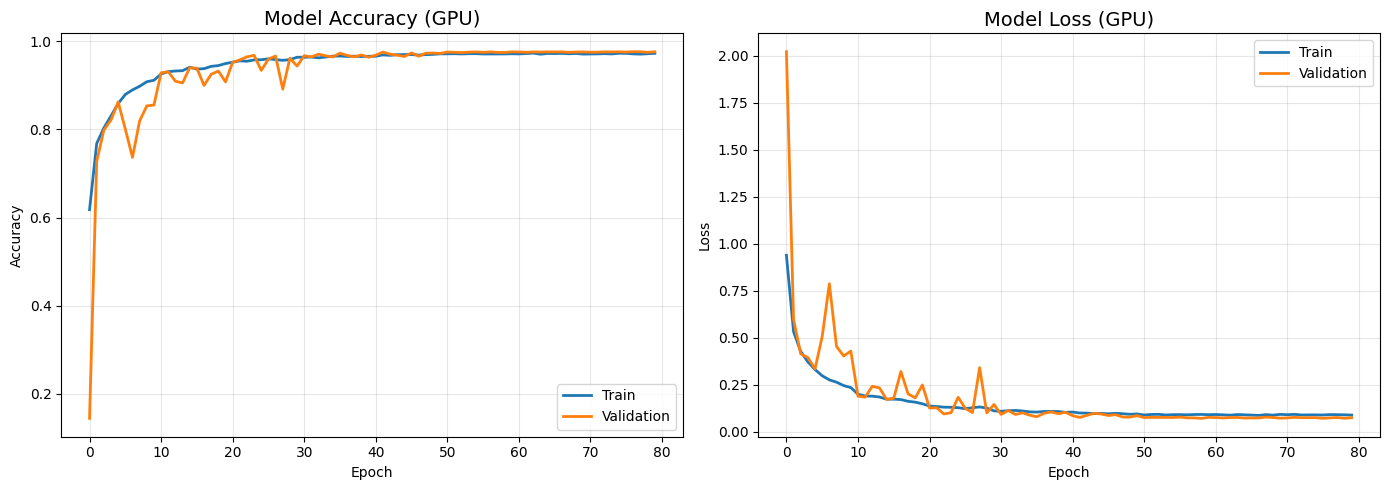

✅ Веса модели сохранены: cnn_lstm_cls_multiclass.weights.h5
✅ Модель сохранена в Keras format: cnn_lstm_cls_multiclass.keras
❌ Не удалось сохранить в SavedModel: this __dict__ descriptor does not support '_DictWrapper' objects
✅ Конфигурация сохранена: cnn_lstm_cls_multiclass_config.json


In [ ]:
model = WellTestCNN_LSTM(
    num_classes=num_classes,
    input_shape=(128, 2)
)

trainer = WellTestTrainer(
    model=model.model,
    task_type='classification',
    class_names=class_names
)

history = trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=64,
    epochs=80,
    initial_lr=0.0001
)

metrics = trainer.evaluate(X_test, y_test)

sample = X_test[0]
pred_class, probs, confidence = trainer.predict_single(X_test[0])
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2%}")
print(f"True class: {np.argmax(y_test[0])}")

trainer.plot_training_history(save_path='training_results.png')

trainer.save_model('cnn_lstm_cls_multiclass', format='all')


CONFUSION MATRIX
📊 Confusion matrix сохранена в confusion_matrix.png


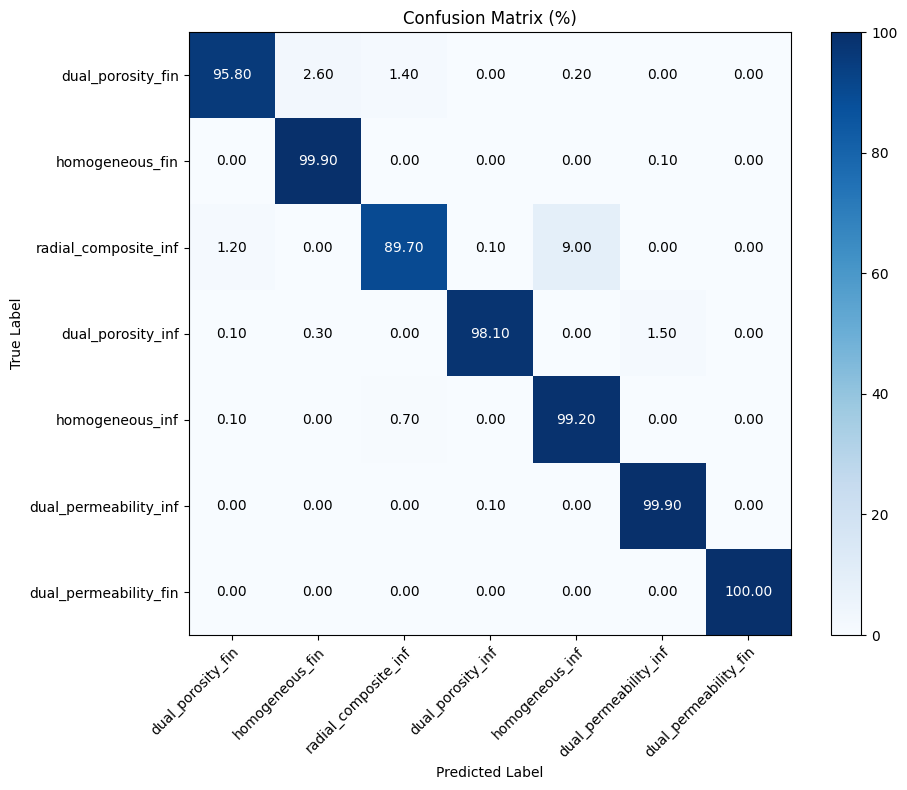

In [ ]:
cm = trainer.plot_confusion_matrix(X_test, y_test,
                                normalize=True,
                                save_path='confusion_matrix.png')

In [ ]:
trainer.save_model('cnn_lstm_cls_multiclass', format='all')

In [ ]:
import json as _json
_cls_cfg = {
    'task_type': 'classification',
    'class_names': list(class_names),
    'input_shape': [128, 2],
}
with open('cnn_lstm_cls_multiclass_config.json', 'w') as _f:
    _json.dump(_cls_cfg, _f, indent=2)
print('Classification config saved to cnn_lstm_cls_multiclass_config.json')

# Классификация multilabel

In [ ]:
!unzip /content/drive/MyDrive/models_incs.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: models_incs/params/31.csv  
  inflating: models_incs/params/53.csv  
  inflating: models_incs/params/60.csv  
  inflating: models_incs/params/77.csv  
  inflating: models_incs/params/81.csv  
  inflating: models_incs/params/83.csv  
  inflating: models_incs/params/157.csv  
  inflating: models_incs/params/160.csv  
  inflating: models_incs/params/171.csv  
  inflating: models_incs/params/189.csv  
  inflating: models_incs/params/229.csv  
  inflating: models_incs/params/232.csv  
  inflating: models_incs/params/261.csv  
  inflating: models_incs/params/394.csv  
  inflating: models_incs/params/481.csv  
  inflating: models_incs/params/482.csv  
  inflating: models_incs/params/520.csv  
  inflating: models_incs/params/536.csv  
  inflating: models_incs/params/561.csv  
  inflating: models_incs/params/565.csv  
  inflating: models_incs/params/629.csv  
  inflating: models_incs/params/631.csv  
  inflating: m

## Модель нейронной сети

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

class WellTestCNN_LSTM_MultiLabel:
    def __init__(self, num_classes=8, input_shape=(128, 2)):
        """
        Инициализация CNN-LSTM сети для MULTILABEL классификации кривых ГДИС

        Parameters:
        -----------
        num_classes : int
            Общее количество бинарных меток (4 типа пласта + 2 границы + 2 обрезания = 8)
        input_shape : tuple
            Форма входных данных (временные точки, каналы)
        """
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model = self._build_model()

    def _build_model(self):
        """Построение архитектуры CNN-LSTM сети для MULTILABEL"""
        inputs = keras.Input(shape=self.input_shape)  # (128, 2) или (2, 128)

        # Проверка и изменение размерности если нужно
        # Если вход (2, 128), транспонируем для Conv1D
        if self.input_shape[0] == 2 and len(self.input_shape) == 2:
            # Изменяем форму с (2, 128) на (128, 2)
            inputs = layers.Permute((2, 1))(inputs)

        # ---- Сверточная часть (Feature Extraction) ----
        # Первый сверточный блок
        x = layers.Conv1D(
            filters=128,          # 128 фильтров
            kernel_size=3,        # kernel size = 3
            padding='same',
            name='conv1d_1'
        )(inputs)
        x = layers.BatchNormalization(name='bn1d_1')(x)
        x = layers.ReLU(name='relu_1')(x)

        # Второй сверточный блок
        x = layers.Conv1D(
            filters=64,           # 64 фильтра
            kernel_size=3,        # kernel size = 3
            padding='same',
            name='conv1d_2'
        )(x)
        x = layers.BatchNormalization(name='bn1d_2')(x)
        x = layers.ReLU(name='relu_2')(x)

        # ---- LSTM слой (Sequence Learning) ----
        x = layers.LSTM(
            units=60,             # 60 LSTM единиц
            return_sequences=False,  # Возвращаем только последний выход
            name='lstm'
        )(x)
        x = layers.BatchNormalization(name='bn_lstm')(x)
        x = layers.Dropout(0.2, name='dropout_lstm')(x)

        # ---- Полносвязная часть ----
        x = layers.Dense(64, activation='relu', name='fc1')(x)
        x = layers.BatchNormalization(name='bn_fc1')(x)
        x = layers.Dropout(0.2, name='dropout_fc1')(x)

        outputs = layers.Dense(
            self.num_classes,
            activation='sigmoid',
            name='output'
        )(x)

        model = keras.Model(inputs=inputs, outputs=outputs, name='WellTestCNN_LSTM_MultiLabel')

        return model

    def compile_model(self, learning_rate=0.001):
        """
        Компиляция модели с метриками для multilabel
        """
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')
            ]
        )
        return self.model

    def summary(self):
        """Вывод архитектуры модели"""
        return self.model.summary()

## Код обучения

In [ ]:
import json
import os
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, hamming_loss, jaccard_score)


class WellTestTrainer:
    TASK_TYPES = ['classification', 'regression', 'multilabel']

    def __init__(self, model, task_type='classification', class_names=None,
                 output_names=None, use_mixed_precision=True, multilabel_threshold=0.5):
        """
        Класс для обучения моделей (поддерживает классификацию, регрессию и multilabel)

        Parameters:
        -----------
        model : keras.Model
            Модель для обучения
        task_type : str
            Тип задачи ('classification', 'regression' или 'multilabel')
        class_names : list, optional
            Названия классов (для классификации и multilabel)
        output_names : list, optional
            Названия выходных параметров (для регрессии)
        use_mixed_precision : bool
            Использовать mixed precision для ускорения на GPU
        multilabel_threshold : float
            Порог для бинаризации предсказаний в multilabel (по умолчанию 0.5)
        """
        if task_type not in self.TASK_TYPES:
            raise ValueError(f"task_type должен быть одним из {self.TASK_TYPES}")

        self.model = model
        self.task_type = task_type
        self.class_names = class_names or []
        self.output_names = output_names or [f'output_{i}' for i in range(model.output_shape[-1])]
        self.multilabel_threshold = multilabel_threshold

        self.num_outputs = model.output_shape[-1]

        self.device_type = self._setup_device(use_mixed_precision)

        self.best_model_path = f'best_model_{task_type}.h5'
        self.checkpoint_dir = f'training_checkpoints_{task_type}'
        self.metrics_file = f'training_metrics_{task_type}.json'

        self.history = None
        self.metrics = None
        self.training_time = None
        self.scaler_y = None

        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def _setup_device(self, use_mixed_precision=True):
        """Настройка устройства (GPU/CPU)"""
        print("=" * 60)
        print(f"НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ ({self.task_type.upper()})")
        print("=" * 60)

        gpus = tf.config.list_physical_devices('GPU')

        if gpus:
            print(f"Обнаружено GPU: {len(gpus)}")
            if use_mixed_precision and self.task_type != 'multilabel':
                # Mixed precision может быть проблематичен для multilabel
                tf.keras.mixed_precision.set_global_policy('mixed_float16')
                print("✅ Mixed precision включен")
            return 'GPU'
        else:
            print("GPU не обнаружен, используется CPU")
            return 'CPU'

    def _get_loss_and_metrics(self):
        """Возвращает функцию потерь и метрики в зависимости от типа задачи"""
        if self.task_type == 'classification':
            loss = 'categorical_crossentropy'
            metrics = ['accuracy']
        elif self.task_type == 'multilabel':
            # Для multilabel: бинарная кросс-энтропия
            loss = 'binary_crossentropy'
            metrics = [
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')
            ]
        else:  # regression
            loss = 'mse'
            metrics = ['mae', 'mse']

        return loss, metrics

    def _get_monitor_metric(self):
        """Возвращает метрику для мониторинга в callbacks"""
        if self.task_type == 'classification':
            return 'val_accuracy', 'max'
        elif self.task_type == 'multilabel':
            # Для multilabel можно мониторить val_auc или val_loss
            return 'val_auc', 'max'
        else:  # regression
            return 'val_loss', 'min'

    def _create_callbacks(self, patience=50, reduce_lr_patience=5):
        """Создание callback'ов для обучения"""
        monitor_metric, monitor_mode = self._get_monitor_metric()

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=self.best_model_path,
                monitor=monitor_metric,
                mode=monitor_mode,
                save_best_only=True,
                save_weights_only=False,
                verbose=1,
                save_freq='epoch'
            ),

            keras.callbacks.ReduceLROnPlateau(
                monitor=monitor_metric,
                factor=0.5,
                patience=reduce_lr_patience,
                min_lr=1e-6,
                verbose=1,
                mode=monitor_mode
            ),

            keras.callbacks.CSVLogger(
                os.path.join(self.checkpoint_dir, 'training_log.csv'),
                separator=',',
                append=True
            ),

            keras.callbacks.TerminateOnNaN()
        ]

        if self.device_type == 'GPU':
            callbacks.append(
                keras.callbacks.TensorBoard(
                    log_dir=os.path.join(self.checkpoint_dir, 'tensorboard_logs'),
                    histogram_freq=1,
                    write_graph=True,
                    write_images=True,
                    update_freq='epoch'
                )
            )

        return callbacks

    def _get_optimizer(self, initial_lr=0.01, optimizer_type='adam'):
        """Создание оптимизатора"""
        clipnorm = 1.0
        epsilon = 1e-7

        if optimizer_type == 'adam':
            optimizer = keras.optimizers.Adam(
                learning_rate=initial_lr,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=epsilon,
                clipnorm=clipnorm
            )
        elif optimizer_type == 'sgd':
            optimizer = keras.optimizers.SGD(
                learning_rate=initial_lr,
                momentum=0.9,
                nesterov=True,
                clipnorm=clipnorm
            )
        elif optimizer_type == 'rmsprop':
            optimizer = keras.optimizers.RMSprop(
                learning_rate=initial_lr,
                rho=0.9,
                epsilon=epsilon,
                clipnorm=clipnorm
            )
        else:
            raise ValueError(f"Неизвестный оптимизатор: {optimizer_type}")

        return optimizer

    def _compile_model(self, optimizer):
        """Компиляция модели"""
        loss, metrics = self._get_loss_and_metrics()

        self.model.compile(
            optimizer=optimizer,
            loss=loss,
            metrics=metrics
        )

    def set_y_scaler(self, scaler):
        """Установка scaler для нормализации целевых значений (для регрессии)"""
        self.scaler_y = scaler

    def train(self, X_train, y_train, X_val, y_val,
              batch_size=32, epochs=300, initial_lr=0.01,
              optimizer_type='adam', custom_lr_schedule=None,
              class_weight=None, validation_freq=1):
        """
        Обучение модели
        """
        print("\n" + "=" * 60)
        print(f"НАЧАЛО ОБУЧЕНИЯ НА {self.device_type} ({self.task_type.upper()})")
        print("=" * 60)

        print(f"Устройство: {self.device_type}")
        print(f"Размер батча: {batch_size}")
        print(f"Тренировочные данные: X {X_train.shape}, y {y_train.shape}")
        print(f"Валидационные данные: X {X_val.shape}, y {y_val.shape}")
        print(f"Эпохи: {epochs}")

        # Для multilabel проверяем формат меток
        if self.task_type == 'multilabel':
            print(f"Multilabel формат: {y_train.shape[1]} бинарных меток")
            self._print_multilabel_stats(y_train, "Train")
            self._print_multilabel_stats(y_val, "Validation")

        optimizer = self._get_optimizer(initial_lr, optimizer_type)
        self._compile_model(optimizer)

        if custom_lr_schedule is None:
            if self.task_type == 'classification':
                def lr_schedule(epoch, lr):
                    if epoch in [50, 150, 250]:
                        return lr * 0.1
                    return lr
            elif self.task_type == 'multilabel':
                def lr_schedule(epoch, lr):
                    if epoch in [30, 80, 150]:
                        return lr * 0.5
                    return lr
            else:  # regression
                def lr_schedule(epoch, lr):
                    if epoch in [30, 50, 70]:
                        return lr * 0.1
                    return lr
        else:
            lr_schedule = custom_lr_schedule

        lr_scheduler = keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)

        callbacks = self._create_callbacks()
        callbacks.append(lr_scheduler)

        start_time = time.time()

        try:
            self.history = self.model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                batch_size=batch_size,
                epochs=epochs,
                callbacks=callbacks,
                verbose=1,
                shuffle=True,
                class_weight=class_weight if self.task_type == 'classification' else None,
                validation_freq=validation_freq
            )

            self.training_time = time.time() - start_time

            print(f"\n✅ Обучение завершено за {self.training_time:.2f} секунд")
            print(f"✅ Лучшая модель сохранена в: {self.best_model_path}")

            self._save_training_info(X_train, X_val)

            return self.history

        except Exception as e:
            print(f"\n❌ Ошибка при обучении: {e}")
            print("Попытка восстановления...")

            if os.path.exists(self.best_model_path):
                self.model = keras.models.load_model(self.best_model_path)
                print("✅ Загружена лучшая сохраненная модель")

            raise

    def _print_multilabel_stats(self, y, name):
        """Вывод статистики для multilabel меток"""
        print(f"\n{name} multilabel статистика:")
        print(f"  Форма: {y.shape}")

        # Частота каждой метки
        label_counts = y.sum(axis=0)
        for i, count in enumerate(label_counts):
            label_name = self.class_names[i] if i < len(self.class_names) else f"Label_{i}"
            pct = count / len(y) * 100
            print(f"  {label_name}: {count:.0f} ({pct:.1f}%)")

        # Количество меток на образец
        n_labels_per_sample = y.sum(axis=1)
        print(f"  Среднее меток на образец: {n_labels_per_sample.mean():.2f}")
        print(f"  Медиана меток на образец: {np.median(n_labels_per_sample):.0f}")

    def _save_training_info(self, X_train, X_val):
        """Сохранение информации об обучении"""
        info = {
            'task_type': self.task_type,
            'device_type': self.device_type,
            'training_time': self.training_time,
            'training_samples': len(X_train),
            'validation_samples': len(X_val),
            'input_shape': X_train.shape[1:],
            'model_summary': []
        }

        if self.task_type == 'classification':
            info.update({
                'num_classes': len(self.class_names),
                'class_names': self.class_names
            })
        elif self.task_type == 'multilabel':
            info.update({
                'num_labels': len(self.class_names),
                'label_names': self.class_names,
                'multilabel_threshold': self.multilabel_threshold
            })
        else:  # regression
            info.update({
                'num_outputs': self.num_outputs,
                'output_names': self.output_names
            })

        self.model.summary(print_fn=lambda x: info['model_summary'].append(x))

        with open(self.metrics_file, 'w') as f:
            json.dump(info, f, indent=2, default=str)

        print(f"✅ Информация об обучении сохранена в {self.metrics_file}")

    def evaluate(self, X_test, y_test, batch_size=None):
        """
        Оценка модели на тестовых данных
        """
        print("\n" + "=" * 60)
        print(f"ОЦЕНКА МОДЕЛИ ({self.task_type.upper()})")
        print("=" * 60)

        if batch_size is None:
            batch_size = 32

        # Базовая оценка
        results = self.model.evaluate(
            X_test, y_test,
            batch_size=batch_size,
            verbose=0,
            return_dict=True
        )

        print(f"\n📊 Базовые метрики:")
        for metric_name, metric_value in results.items():
            print(f"  {metric_name}: {metric_value:.4f}")

        # Предсказания
        y_pred = self.model.predict(X_test, batch_size=batch_size, verbose=0)

        # Специфичная оценка в зависимости от типа задачи
        if self.task_type == 'classification':
            self._evaluate_classification(y_test, y_pred)
        elif self.task_type == 'multilabel':
            self._evaluate_multilabel(y_test, y_pred)
        else:  # regression
            self._evaluate_regression(y_test, y_pred, self.scaler_y)

        # Сохранение метрик
        self.metrics = {
            'task_type': self.task_type,
            'test_metrics': results,
            'device_used': self.device_type,
            'evaluation_time': time.time()
        }

        if self.task_type == 'classification':
            self.metrics.update(self._get_classification_metrics_dict())
        elif self.task_type == 'multilabel':
            self.metrics.update(self._get_multilabel_metrics_dict(y_test, y_pred))
        else:
            self.metrics.update(self._get_regression_metrics_dict(y_test, y_pred))

        with open(f'evaluation_metrics_{self.task_type}.json', 'w') as f:
            json.dump(self.metrics, f, indent=2, default=str)

        return self.metrics

    def _evaluate_multilabel(self, y_test, y_pred):
        """
        Оценка для multilabel классификации
        """
        # Бинаризация предсказаний
        y_pred_binary = (y_pred > self.multilabel_threshold).astype(int)
        y_true = y_test

        print(f"\n📊 Multilabel метрики (порог={self.multilabel_threshold}):")

        # 1. Hamming Loss
        hamming = hamming_loss(y_true, y_pred_binary)
        print(f"  Hamming Loss: {hamming:.4f} (чем меньше, тем лучше)")

        # 2. Subset Accuracy (точное совпадение всех меток)
        subset_acc = accuracy_score(y_true, y_pred_binary)
        print(f"  Subset Accuracy: {subset_acc:.4f}")

        # 3. Jaccard Score (Intersection over Union)
        jaccard_micro = jaccard_score(y_true, y_pred_binary, average='micro')
        jaccard_macro = jaccard_score(y_true, y_pred_binary, average='macro')
        print(f"  Jaccard (micro): {jaccard_micro:.4f}")
        print(f"  Jaccard (macro): {jaccard_macro:.4f}")

        # 4. F1 Score по каждому классу
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred_binary, average=None, zero_division=0
        )

        print(f"\n📊 Пер-класс метрики:")
        print(f"{'Метка':<20} | {'Precision':>10} | {'Recall':>10} | {'F1':>10}")
        print("-" * 55)

        for i in range(len(self.class_names)):
            label_name = self.class_names[i] if i < len(self.class_names) else f'Label_{i}'
            print(f"{label_name:<20} | {precision[i]:>10.4f} | {recall[i]:>10.4f} | {f1[i]:>10.4f}")

        # 5. Средние метрики
        print(f"\n📊 Средние метрики:")
        print(f"  Macro F1: {np.mean(f1):.4f}")
        print(f"  Micro F1: {precision_recall_fscore_support(y_true, y_pred_binary, average='micro')[2]:.4f}")

        # 6. ROC AUC если возможно
        try:
            if y_true.shape[1] == 2:
                roc_auc = roc_auc_score(y_true, y_pred)
                print(f"  ROC AUC: {roc_auc:.4f}")
            else:
                roc_auc_macro = roc_auc_score(y_true, y_pred, average='macro', multi_class='ovr')
                print(f"  ROC AUC (macro): {roc_auc_macro:.4f}")
        except Exception as e:
            print(f"  ROC AUC не может быть вычислен: {e}")

    def _get_multilabel_metrics_dict(self, y_test, y_pred):
        """Возвращает словарь с метриками multilabel"""
        y_pred_binary = (y_pred > self.multilabel_threshold).astype(int)
        y_true = y_test

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred_binary, average=None, zero_division=0
        )

        metrics_dict = {
            'threshold': self.multilabel_threshold,
            'hamming_loss': float(hamming_loss(y_true, y_pred_binary)),
            'subset_accuracy': float(accuracy_score(y_true, y_pred_binary)),
            'jaccard_micro': float(jaccard_score(y_true, y_pred_binary, average='micro')),
            'jaccard_macro': float(jaccard_score(y_true, y_pred_binary, average='macro')),
            'macro_f1': float(np.mean(f1)),
            'micro_f1': float(precision_recall_fscore_support(y_true, y_pred_binary, average='micro')[2]),
            'per_label_metrics': {}
        }

        for i, label_name in enumerate(self.class_names):
            metrics_dict['per_label_metrics'][label_name] = {
                'precision': float(precision[i]),
                'recall': float(recall[i]),
                'f1': float(f1[i])
            }

        return metrics_dict

    def _evaluate_classification(self, y_test, y_pred):
        """Оценка для классификации (без изменений)"""
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_test, axis=1)

        try:
            if len(self.class_names) == 2:
                roc_auc = roc_auc_score(y_true, y_pred[:, 1])
                print(f"\n📈 ROC AUC Score: {roc_auc:.4f}")
            else:
                roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')
                print(f"\n📈 ROC AUC Score (macro): {roc_auc:.4f}")
        except:
            roc_auc = None
            print("\n⚠️ ROC AUC не может быть вычислен")

        print("\n📊 Classification Report:")
        print(classification_report(
            y_true, y_pred_classes,
            target_names=self.class_names,
            digits=4
        ))

    def _evaluate_regression(self, y_test, y_pred, scaler=None):
        """Оценка для регрессии (без изменений)"""
        if scaler is not None:
            y_test_real = scaler.inverse_transform(y_test)
            y_pred_real = scaler.inverse_transform(y_pred)
        else:
            y_test_real = y_test
            y_pred_real = y_pred

        print("\n📊 Регрессионные метрики (в исходном масштабе):")

        for i in range(self.num_outputs):
            output_name = self.output_names[i] if i < len(self.output_names) else f'Output {i}'

            mse = mean_squared_error(y_test_real[:, i], y_pred_real[:, i])
            mae = mean_absolute_error(y_test_real[:, i], y_pred_real[:, i])
            r2 = r2_score(y_test_real[:, i], y_pred_real[:, i])

            print(f"\n  {output_name}:")
            print(f"    MSE:  {mse:.4e}")
            print(f"    MAE:  {mae:.4e}")
            print(f"    R²:   {r2:.4f}")

            if r2 < 0:
                print(f"    ⚠️  КРИТИЧЕСКАЯ ОШИБКА: Модель работает хуже константы!")

    def _get_regression_metrics_dict(self, y_test, y_pred):
        """Возвращает словарь с метриками регрессии (без изменений)"""
        if self.scaler_y is not None:
            y_test_orig = self.scaler_y.inverse_transform(y_test)
            y_pred_orig = self.scaler_y.inverse_transform(y_pred)
        else:
            y_test_orig = y_test
            y_pred_orig = y_pred

        metrics_dict = {
            'output_names': self.output_names,
            'per_output_metrics': {}
        }

        for i in range(self.num_outputs):
            mse = float(mean_squared_error(y_test_orig[:, i], y_pred_orig[:, i]))
            mae = float(mean_absolute_error(y_test_orig[:, i], y_pred_orig[:, i]))
            r2 = float(r2_score(y_test_orig[:, i], y_pred_orig[:, i]))

            metrics_dict['per_output_metrics'][self.output_names[i]] = {
                'mse': mse,
                'mae': mae,
                'r2': r2
            }

        metrics_dict['overall'] = {
            'mse': float(mean_squared_error(y_test_orig, y_pred_orig)),
            'mae': float(mean_absolute_error(y_test_orig, y_pred_orig))
        }

        return metrics_dict

    def _get_classification_metrics_dict(self):
        """Возвращает словарь с метриками классификации"""
        return {}

    def predict_single(self, X_single, return_original_scale=False):
        """
        Предсказание для одного примера
        """
        X_batch = np.expand_dims(X_single, axis=0)
        predictions = self.model.predict(X_batch, batch_size=1, verbose=0)[0]

        if self.task_type == 'classification':
            predicted_class = np.argmax(predictions)
            confidence = predictions[predicted_class]
            return predicted_class, predictions, confidence

        elif self.task_type == 'multilabel':
            # Возвращаем бинарные метки и вероятности
            predicted_labels = (predictions > self.multilabel_threshold).astype(int)
            return predicted_labels, predictions

        else:  # regression
            if return_original_scale and self.scaler_y is not None:
                predictions = predictions.reshape(1, -1)
                predictions = self.scaler_y.inverse_transform(predictions)[0]
            return predictions

    def plot_training_history(self, save_path=None):
        """Визуализация истории обучения"""
        if self.history is None:
            print("⚠️ Модель еще не обучена!")
            return

        history_dict = self.history.history

        if self.task_type == 'classification':
            self._plot_classification_history(history_dict, save_path)
        elif self.task_type == 'multilabel':
            self._plot_multilabel_history(history_dict, save_path)
        else:
            self._plot_regression_history(history_dict, save_path)

    def _plot_multilabel_history(self, history_dict, save_path):
        """Визуализация истории для multilabel"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Loss
        axes[0, 0].plot(history_dict['loss'], label='Train', linewidth=2)
        axes[0, 0].plot(history_dict['val_loss'], label='Validation', linewidth=2)
        axes[0, 0].set_title(f'Model Loss ({self.device_type})', fontsize=14)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[0, 1].plot(history_dict['accuracy'], label='Train', linewidth=2)
        axes[0, 1].plot(history_dict['val_accuracy'], label='Validation', linewidth=2)
        axes[0, 1].set_title(f'Model Accuracy ({self.device_type})', fontsize=14)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Precision/Recall если есть
        if 'precision' in history_dict:
            axes[1, 0].plot(history_dict['precision'], label='Train Precision', linewidth=2)
            axes[1, 0].plot(history_dict['val_precision'], label='Val Precision', linewidth=2)
            axes[1, 0].plot(history_dict['recall'], label='Train Recall', linewidth=2)
            axes[1, 0].plot(history_dict['val_recall'], label='Val Recall', linewidth=2)
            axes[1, 0].set_title('Precision & Recall', fontsize=14)
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)

        # AUC если есть
        if 'auc' in history_dict:
            axes[1, 1].plot(history_dict['auc'], label='Train AUC', linewidth=2)
            axes[1, 1].plot(history_dict['val_auc'], label='Validation AUC', linewidth=2)
            axes[1, 1].set_title('ROC AUC', fontsize=14)
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    def _plot_classification_history(self, history_dict, save_path):
        """Визуализация истории для классификации (без изменений)"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(history_dict['accuracy'], label='Train', linewidth=2)
        axes[0].plot(history_dict['val_accuracy'], label='Validation', linewidth=2)
        axes[0].set_title(f'Model Accuracy ({self.device_type})', fontsize=14)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(history_dict['loss'], label='Train', linewidth=2)
        axes[1].plot(history_dict['val_loss'], label='Validation', linewidth=2)
        axes[1].set_title(f'Model Loss ({self.device_type})', fontsize=14)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    def _plot_regression_history(self, history_dict, save_path):
        """Визуализация истории для регрессии (без изменений)"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(history_dict['loss'], label='Train Loss', linewidth=2)
        axes[0].plot(history_dict['val_loss'], label='Validation Loss', linewidth=2)
        axes[0].set_title(f'Model Loss ({self.device_type})', fontsize=14)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        if 'mae' in history_dict:
            axes[1].plot(history_dict['mae'], label='Train MAE', linewidth=2)
            axes[1].plot(history_dict['val_mae'], label='Validation MAE', linewidth=2)
            axes[1].set_title(f'Model MAE ({self.device_type})', fontsize=14)
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('MAE')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"📊 График сохранен в {save_path}")

        plt.show()

    # Остальные методы (plot_confusion_matrix, plot_predictions_vs_actual,
    # get_bad_predictions, save_model) остаются без изменений,
    # но plot_confusion_matrix нужно адаптировать для multilabel

    def save_model(self, path=None, format='keras'):
        """Сохранение модели"""
        if path is None:
            path = f'welltest_model_{self.task_type}'

        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)

        if format in ['h5', 'all']:
            try:
                weights_path = f"{path}.weights.h5"
                self.model.save_weights(weights_path)
                print(f"✅ Веса модели сохранены: {weights_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить веса: {e}")

        if format in ['keras', 'all']:
            keras_path = f"{path}.keras" if not path.endswith('.keras') else path
            try:
                self.model.save(keras_path)
                print(f"✅ Модель сохранена в Keras format: {keras_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить в Keras format: {e}")

        if format in ['savedmodel', 'all']:
            savedmodel_path = f"{path}_savedmodel"
            try:
                tf.saved_model.save(self.model, savedmodel_path)
                print(f"✅ Модель сохранена в SavedModel: {savedmodel_path}")
            except Exception as e:
                print(f"❌ Не удалось сохранить в SavedModel: {e}")

        config = {
            'task_type': self.task_type,
            'class_names': self.class_names if self.task_type in ['classification', 'multilabel'] else [],
            'output_names': self.output_names if self.task_type == 'regression' else [],
            'num_outputs': self.num_outputs if self.task_type == 'regression' else None,
            'input_shape': self.model.input_shape[1:],
            'device_used': self.device_type,
            'model_format': format,
            'save_time': time.strftime('%Y-%m-%d %H:%M:%S')
        }

        if self.task_type == 'multilabel':
            config['multilabel_threshold'] = self.multilabel_threshold

        config_path = f"{path}_config.json"
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"✅ Конфигурация сохранена: {config_path}")

## Обучение

In [ ]:
data_preprocess = PressureDataMultilabelClassificationPreprocessor1D(data_dir='/content/models_incs')

X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='classification')

In [ ]:
X_train = data_preprocess.normalize(X_train)
X_val = data_preprocess.normalize(X_val)
X_test = data_preprocess.normalize(X_test)

In [ ]:
model = WellTestCNN_LSTM_MultiLabel(
    num_classes=9,  # 4 типа пласта + 2 границы + 3 обрезания
    input_shape=(128, 2)
)

trainer = WellTestTrainer(
    model=model.model,
    task_type='multilabel',
    class_names=[
        'homogeneous', 'dual_porosity', 'dual_permeability', 'radial_composite',
        'inf', 'fin',
        'inc1', 'inc2', 'full'
    ],
    use_mixed_precision=False
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (MULTILABEL)
Обнаружено GPU: 1


In [ ]:
# Обучение
history = trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=32,
    epochs=100,
    initial_lr=0.001
)


НАЧАЛО ОБУЧЕНИЯ НА GPU (MULTILABEL)
Устройство: GPU
Размер батча: 32
Тренировочные данные: X (24500, 128, 2), y (24500, 9)
Валидационные данные: X (3500, 128, 2), y (3500, 9)
Эпохи: 100
Multilabel формат: 9 бинарных меток

Train multilabel статистика:
  Форма: (24500, 9)
  homogeneous: 6999 (28.6%)
  dual_porosity: 7002 (28.6%)
  dual_permeability: 6999 (28.6%)
  radial_composite: 3500 (14.3%)
  inf: 14001 (57.1%)
  fin: 10499 (42.9%)
  inc1: 8165 (33.3%)
  inc2: 8166 (33.3%)
  full: 8169 (33.3%)
  Среднее меток на образец: 3.00
  Медиана меток на образец: 3

Validation multilabel статистика:
  Форма: (3500, 9)
  homogeneous: 1000 (28.6%)
  dual_porosity: 999 (28.5%)
  dual_permeability: 1001 (28.6%)
  radial_composite: 500 (14.3%)
  inf: 1999 (57.1%)
  fin: 1501 (42.9%)
  inc1: 1167 (33.3%)
  inc2: 1166 (33.3%)
  full: 1167 (33.3%)
  Среднее меток на образец: 3.00
  Медиана меток на образец: 3

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/100


Epoch 1: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.0102 - auc: 0.8829 - loss: 0.3786 - precision: 0.7256 - recall: 0.6579 - val_accuracy: 0.0169 - val_auc: 0.8871 - val_loss: 0.3693 - val_precision: 0.7569 - val_recall: 0.6503 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/100
764/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0113 - auc: 0.9191 - loss: 0.3142 - precision: 0.8114 - recall: 0.6711
Epoch 2: val_auc did not improve from 0.88708
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.0129 - auc: 0.9229 - loss: 0.3072 - precision: 0.8159 - recall: 0.6811 - val_accuracy: 0.0063 - val_auc: 0.8663 - val_loss: 0.4539 - val_precision: 0.6742 - val_recall: 0.6533 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0114 - auc: 0


Epoch 3: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.0121 - auc: 0.9323 - loss: 0.2888 - precision: 0.8283 - recall: 0.7009 - val_accuracy: 0.0066 - val_auc: 0.8875 - val_loss: 0.4297 - val_precision: 0.7432 - val_recall: 0.6749 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 4/100
764/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0162 - auc: 0.9368 - loss: 0.2788 - precision: 0.8353 - recall: 0.7118
Epoch 4: val_auc did not improve from 0.88750
766/766 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.0172 - auc: 0.9375 - loss: 0.2771 - precision: 0.8364 - recall: 0.7129 - val_accuracy: 0.0071 - val_auc: 0.8374 - val_loss: 0.6022 - val_precision: 0.7120 - val_recall: 0.5804 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 5/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0182 - auc: 0


Epoch 5: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.0188 - auc: 0.9416 - loss: 0.2687 - precision: 0.8413 - recall: 0.7232 - val_accuracy: 0.0091 - val_auc: 0.9383 - val_loss: 0.2737 - val_precision: 0.8495 - val_recall: 0.7070 - learning_rate: 0.0010

Epoch 6: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 6/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0202 - auc: 0.9443 - loss: 0.2631 - precision: 0.8461 - recall: 0.7328
Epoch 6: val_auc did not improve from 0.93829
766/766 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.0209 - auc: 0.9459 - loss: 0.2593 - precision: 0.8488 - recall: 0.7371 - val_accuracy: 0.0531 - val_auc: 0.9129 - val_loss: 0.3650 - val_precision: 0.7789 - val_recall: 0.6926 - learning_rate: 0.0010

Epoch 7: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 7/100
764/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0237 - auc: 0


Epoch 8: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.0266 - auc: 0.9522 - loss: 0.2445 - precision: 0.8576 - recall: 0.7552 - val_accuracy: 0.0297 - val_auc: 0.9522 - val_loss: 0.2459 - val_precision: 0.8535 - val_recall: 0.7616 - learning_rate: 0.0010

Epoch 9: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 9/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0283 - auc: 0.9543 - loss: 0.2398 - precision: 0.8611 - recall: 0.7619
Epoch 9: val_auc did not improve from 0.95221
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.0281 - auc: 0.9545 - loss: 0.2387 - precision: 0.8621 - recall: 0.7617 - val_accuracy: 0.0477 - val_auc: 0.7925 - val_loss: 0.8819 - val_precision: 0.6479 - val_recall: 0.5730 - learning_rate: 0.0010

Epoch 10: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 10/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0302 - auc:

...


Epoch 61: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1224 - auc: 0.9744 - loss: 0.1757 - precision: 0.9021 - recall: 0.8147 - val_accuracy: 0.1163 - val_auc: 0.9760 - val_loss: 0.1697 - val_precision: 0.9101 - val_recall: 0.8158 - learning_rate: 1.5625e-05

Epoch 62: LearningRateScheduler setting learning rate to 1.5625000742147677e-05.
Epoch 62/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1240 - auc: 0.9746 - loss: 0.1751 - precision: 0.9029 - recall: 0.8151
Epoch 62: val_auc did not improve from 0.97601
766/766 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.1225 - auc: 0.9745 - loss: 0.1756 - precision: 0.9031 - recall: 0.8154 - val_accuracy: 0.1560 - val_auc: 0.9753 - val_loss: 0.1724 - val_precision: 0.9072 - val_recall: 0.8112 - learning_rate: 1.5625e-05

Epoch 63: LearningRateScheduler setting learning rate to 1.5625000742147677e-05.
Epoch 63/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy:


Epoch 64: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.1246 - auc: 0.9747 - loss: 0.1751 - precision: 0.9031 - recall: 0.8160 - val_accuracy: 0.1306 - val_auc: 0.9761 - val_loss: 0.1694 - val_precision: 0.9106 - val_recall: 0.8165 - learning_rate: 1.5625e-05

Epoch 65: LearningRateScheduler setting learning rate to 1.5625000742147677e-05.
Epoch 65/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1202 - auc: 0.9748 - loss: 0.1745 - precision: 0.9019 - recall: 0.8149
Epoch 65: val_auc did not improve from 0.97613
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.1229 - auc: 0.9747 - loss: 0.1747 - precision: 0.9017 - recall: 0.8152 - val_accuracy: 0.1214 - val_auc: 0.9758 - val_loss: 0.1703 - val_precision: 0.9092 - val_recall: 0.8141 - learning_rate: 1.5625e-05

Epoch 66: LearningRateScheduler setting learning rate to 1.5625000742147677e-05.
Epoch 66/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy:


Epoch 72: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.1242 - auc: 0.9745 - loss: 0.1753 - precision: 0.9024 - recall: 0.8150 - val_accuracy: 0.1194 - val_auc: 0.9761 - val_loss: 0.1695 - val_precision: 0.9099 - val_recall: 0.8149 - learning_rate: 7.8125e-06

Epoch 73: LearningRateScheduler setting learning rate to 7.812500371073838e-06.
Epoch 73/100
765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1214 - auc: 0.9747 - loss: 0.1747 - precision: 0.9019 - recall: 0.8145
Epoch 73: val_auc did not improve from 0.97613
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1238 - auc: 0.9748 - loss: 0.1744 - precision: 0.9025 - recall: 0.8150 - val_accuracy: 0.1177 - val_auc: 0.9760 - val_loss: 0.1695 - val_precision: 0.9098 - val_recall: 0.8147 - learning_rate: 7.8125e-06

Epoch 74: LearningRateScheduler setting learning rate to 7.812500371073838e-06.
Epoch 74/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0


Epoch 78: finished saving model to best_model_multilabel.h5
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1263 - auc: 0.9748 - loss: 0.1742 - precision: 0.9023 - recall: 0.8151 - val_accuracy: 0.1209 - val_auc: 0.9761 - val_loss: 0.1692 - val_precision: 0.9100 - val_recall: 0.8148 - learning_rate: 3.9063e-06

Epoch 79: LearningRateScheduler setting learning rate to 3.906250185536919e-06.
Epoch 79/100
766/766 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1228 - auc: 0.9743 - loss: 0.1753 - precision: 0.8995 - recall: 0.8128
Epoch 79: val_auc did not improve from 0.97614

Epoch 79: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
766/766 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1243 - auc: 0.9748 - loss: 0.1742 - precision: 0.9020 - recall: 0.8153 - val_accuracy: 0.1334 - val_auc: 0.9760 - val_loss: 0.1696 - val_precision: 0.9093 - val_recall: 0.8138 - learning_rate: 1.9531e-06

Epoch 80: LearningRateScheduler setting learning rate to 1.9531250927

✅ Информация об обучении сохранена в training_metrics_multilabel.json


In [ ]:
# Оценка
metrics = trainer.evaluate(X_test, y_test)

# Предсказание
predicted_labels, probabilities = trainer.predict_single(X_test[0])


ОЦЕНКА МОДЕЛИ (MULTILABEL)

📊 Базовые метрики:
  accuracy: 0.1266
  auc: 0.9765
  loss: 0.1669
  precision: 0.9098
  recall: 0.8150

📊 Multilabel метрики (порог=0.5):
  Hamming Loss: 0.0886 (чем меньше, тем лучше)
  Subset Accuracy: 0.5803
  Jaccard (micro): 0.7541
  Jaccard (macro): 0.7602

📊 Пер-класс метрики:
Метка                |  Precision |     Recall |         F1
-------------------------------------------------------
homogeneous          |     0.9754 |     0.6742 |     0.7973
dual_porosity        |     0.9708 |     0.6823 |     0.8014
dual_permeability    |     0.9668 |     0.6545 |     0.7806
radial_composite     |     0.9985 |     0.6670 |     0.7998
inf                  |     0.7252 |     0.9762 |     0.8322
fin                  |     0.9412 |     0.5067 |     0.6587
inc1                 |     1.0000 |     1.0000 |     1.0000
inc2                 |     1.0000 |     1.0000 |     1.0000
full                 |     1.0000 |     1.0000 |     1.0000

📊 Средние метрики:
  Macro F

In [ ]:
trainer.save_model('cnn_lstm_cls_multilabel', format='all')

✅ Веса модели сохранены: cnn_lstm_cls_multilabel.weights.h5
✅ Модель сохранена в Keras format: cnn_lstm_cls_multilabel.keras
❌ Не удалось сохранить в SavedModel: this __dict__ descriptor does not support '_DictWrapper' objects
✅ Конфигурация сохранена: cnn_lstm_cls_multilabel_config.json


# Классификация multilabel с кастомным разбиением на train/val/test

In [ ]:
!unzip /content/drive/MyDrive/datasets/models_incs_prc.zip

In [ ]:
data_preprocess = PressureDataMultilabelClassificationCustomPreprocessor1D(
    data_dir='/content/models_incs_prc',
    debug=True
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
X_train = data_preprocess.normalize(X_train)
X_val   = data_preprocess.normalize(X_val)
X_test  = data_preprocess.normalize(X_test)

In [ ]:
model = WellTestCNN_LSTM_MultiLabel(
    num_classes=9,
    input_shape=(128, 2)
)

trainer = WellTestTrainer(
    model=model.model,
    task_type='multilabel',
    class_names=[
        'homogeneous', 'dual_porosity', 'dual_permeability', 'radial_composite',
        'inf', 'fin',
        'inc1', 'inc2', 'full'
    ],
    use_mixed_precision=False
)

history = trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=32,
    epochs=100,
    initial_lr=0.001
)

In [ ]:
metrics = trainer.evaluate(X_test, y_test)

In [ ]:
trainer.save_model('cnn_lstm_cls_multilabel', format='all')

# Обучение однородной модели для бесконечного пласта

In [ ]:
!unzip /content/drive/MyDrive/homogeneous_inf.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: homogeneous_inf/params/24.csv  
  inflating: homogeneous_inf/params/46.csv  
  inflating: homogeneous_inf/params/48.csv  
  inflating: homogeneous_inf/params/85.csv  
  inflating: homogeneous_inf/params/168.csv  
  inflating: homogeneous_inf/params/183.csv  
  inflating: homogeneous_inf/params/208.csv  
  inflating: homogeneous_inf/params/209.csv  
  inflating: homogeneous_inf/params/215.csv  
  inflating: homogeneous_inf/params/226.csv  
  inflating: homogeneous_inf/params/252.csv  
  inflating: homogeneous_inf/params/268.csv  
  inflating: homogeneous_inf/params/274.csv  
  inflating: homogeneous_inf/params/283.csv  
  inflating: homogeneous_inf/params/290.csv  
  inflating: homogeneous_inf/params/311.csv  
  inflating: homogeneous_inf/params/314.csv  
  inflating: homogeneous_inf/params/319.csv  
  inflating: homogeneous_inf/params/328.csv  
  inflating: homogeneous_inf/params/347.csv  
  inflating: hom

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/homogeneous_inf',
    model_type=Model.HOMOGENEOUS_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 3).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 3).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 3).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler()
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.22645181477281037 1.0924382849788545 0.6240478513227239
Transformed data:  0.23234931240936912 1.0932869168731432 0.6228698134476535
Transformed data:  0.2280054864889593 1.0989156212789246 0.6266188629034031


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=3, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k', 'C_D', 'S']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=50,
    initial_lr=0.00005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (14000, 128, 2), y (14000, 3)
Валидационные данные: X (2000, 128, 2), y (2000, 3)
Эпохи: 50

Epoch 1: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1.2302 - mae: 0.8225 - mse: 1.2302
Epoch 1: val_loss improved from None to 2.18875, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 1.1021 - mae: 0.7731 - mse: 1.1021 - val_loss: 2.1888 - val_mae: 1.0872 - val_mse: 2.1888 - learning_rate: 5.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.9779 - mae: 0.7196 - mse: 0.9779
Epoch 2: val_loss improved from 2.18875 to 1.55249, saving model to best_model_regression.h5



Epoch 2: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 0.9564 - mae: 0.7109 - mse: 0.9564 - val_loss: 1.5525 - val_mae: 0.9355 - val_mse: 1.5525 - learning_rate: 5.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.9276 - mae: 0.6904 - mse: 0.9276
Epoch 3: val_loss did not improve from 1.55249
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 0.9080 - mae: 0.6886 - mse: 0.9080 - val_loss: 1.8310 - val_mae: 1.0830 - val_mse: 1.8310 - learning_rate: 5.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.9270 - mae: 0.6881 - mse: 0.9270
Epoch 4: val_loss did not improve from 1.55249
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.8773 - mae: 0.6751 - mse: 0.8773 - val_loss: 2.2060 - val_mae: 1.2611 - val_mse: 2.2060 - learning_rate


Epoch 8: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - loss: 0.6759 - mae: 0.5565 - mse: 0.6759 - val_loss: 1.5431 - val_mae: 1.0580 - val_mse: 1.5431 - learning_rate: 2.5000e-05

Epoch 9: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.6626 - mae: 0.5512 - mse: 0.6626
Epoch 9: val_loss did not improve from 1.54315
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 0.6682 - mae: 0.5497 - mse: 0.6682 - val_loss: 2.6640 - val_mae: 1.4863 - val_mse: 2.6640 - learning_rate: 2.5000e-05

Epoch 10: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.6458 - mae: 0.5457 - mse: 0.6458
Epoch 10: val_loss did not improve from 1.54315
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - loss: 0.6634 - mae: 0.5462 - mse: 0.6634 - val_loss: 1.7760 - val_mae: 1.1155 - val_mse: 1.7760 - learning_r


Epoch 11: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.6619 - mae: 0.5445 - mse: 0.6619 - val_loss: 1.0311 - val_mae: 0.7895 - val_mse: 1.0311 - learning_rate: 2.5000e-05

Epoch 12: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 12/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.6735 - mae: 0.5456 - mse: 0.6735
Epoch 12: val_loss did not improve from 1.03110
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - loss: 0.6600 - mae: 0.5425 - mse: 0.6600 - val_loss: 2.2329 - val_mae: 1.2113 - val_mse: 2.2329 - learning_rate: 2.5000e-05

Epoch 13: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 13/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.6739 - mae: 0.5408 - mse: 0.6739
Epoch 13: val_loss did not improve from 1.03110
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.6602 - mae: 0.5416 - mse: 0.6602 - val_loss: 2.1560 - val_mae: 1.3123 - val_mse: 2.1560 - learni

...


Epoch 34: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.4012 - mae: 0.4162 - mse: 0.4012 - val_loss: 0.3937 - val_mae: 0.3958 - val_mse: 0.3937 - learning_rate: 1.2500e-06

Epoch 35: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 35/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.4001 - mae: 0.4115 - mse: 0.4001
Epoch 35: val_loss improved from 0.39366 to 0.37909, saving model to best_model_regression.h5



Epoch 35: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.4030 - mae: 0.4151 - mse: 0.4030 - val_loss: 0.3791 - val_mae: 0.3656 - val_mse: 0.3791 - learning_rate: 1.2500e-06

Epoch 36: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 36/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3943 - mae: 0.4160 - mse: 0.3943
Epoch 36: val_loss did not improve from 0.37909
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.3997 - mae: 0.4173 - mse: 0.3997 - val_loss: 0.4097 - val_mae: 0.4162 - val_mse: 0.4097 - learning_rate: 1.2500e-06

Epoch 37: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 37/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3924 - mae: 0.4124 - mse: 0.3924
Epoch 37: val_loss did not improve from 0.37909
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 0.3988 - mae: 0.4154 - mse: 0.3988 - val_loss: 0.3999 - val_mae: 0.4044 - val_mse: 0.3999 - learni


Epoch 42: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.4015 - mae: 0.4166 - mse: 0.4015 - val_loss: 0.3688 - val_mae: 0.3598 - val_mse: 0.3688 - learning_rate: 1.0000e-06

Epoch 43: LearningRateScheduler setting learning rate to 9.999999974752427e-07.
Epoch 43/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3947 - mae: 0.4150 - mse: 0.3947
Epoch 43: val_loss did not improve from 0.36878
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.3968 - mae: 0.4135 - mse: 0.3968 - val_loss: 0.4613 - val_mae: 0.4995 - val_mse: 0.4613 - learning_rate: 1.0000e-06

Epoch 44: LearningRateScheduler setting learning rate to 9.999999974752427e-07.
Epoch 44/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.3930 - mae: 0.4160 - mse: 0.3930
Epoch 44: val_loss did not improve from 0.36878
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 0.3977 - mae: 0.4161 - mse: 0.3977 - val_loss: 0.3843 - val_mae: 0.3836 - val_mse: 0.3843 - learni


Epoch 45: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.4000 - mae: 0.4168 - mse: 0.4000 - val_loss: 0.3680 - val_mae: 0.3612 - val_mse: 0.3680 - learning_rate: 1.0000e-06

Epoch 46: LearningRateScheduler setting learning rate to 9.999999974752427e-07.
Epoch 46/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.3905 - mae: 0.4107 - mse: 0.3905
Epoch 46: val_loss did not improve from 0.36799
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - loss: 0.3956 - mae: 0.4117 - mse: 0.3956 - val_loss: 0.3731 - val_mae: 0.3716 - val_mse: 0.3731 - learning_rate: 1.0000e-06

Epoch 47: LearningRateScheduler setting learning rate to 9.999999974752427e-07.
Epoch 47/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.4006 - mae: 0.4116 - mse: 0.4006
Epoch 47: val_loss did not improve from 0.36799
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - loss: 0.3961 - mae: 0.4128 - mse: 0.3961 - val_loss: 0.3693 - val_mae: 0.3563 - val_mse: 0.3693 - learni

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.3867
  mae: 0.4346
  mse: 0.3867

📊 Регрессионные метрики (в исходном масштабе):

  k:
    MSE:  6.4130e-28
    MAE:  2.2813e-14
    R²:   0.9866

  C_D:
    MSE:  4.6419e+03
    MAE:  5.8115e+01
    R²:   0.8286

  S:
    MSE:  5.2486e+00
    MAE:  1.9740e+00
    R²:   0.0082


Количество выходов: 3
Форма y_test_orig: (4000, 3)
Results: 2.1515477116942905e-13 1.073402759906028e-12
Results: 2.280054864889593e-13 1.0989156212789246e-12


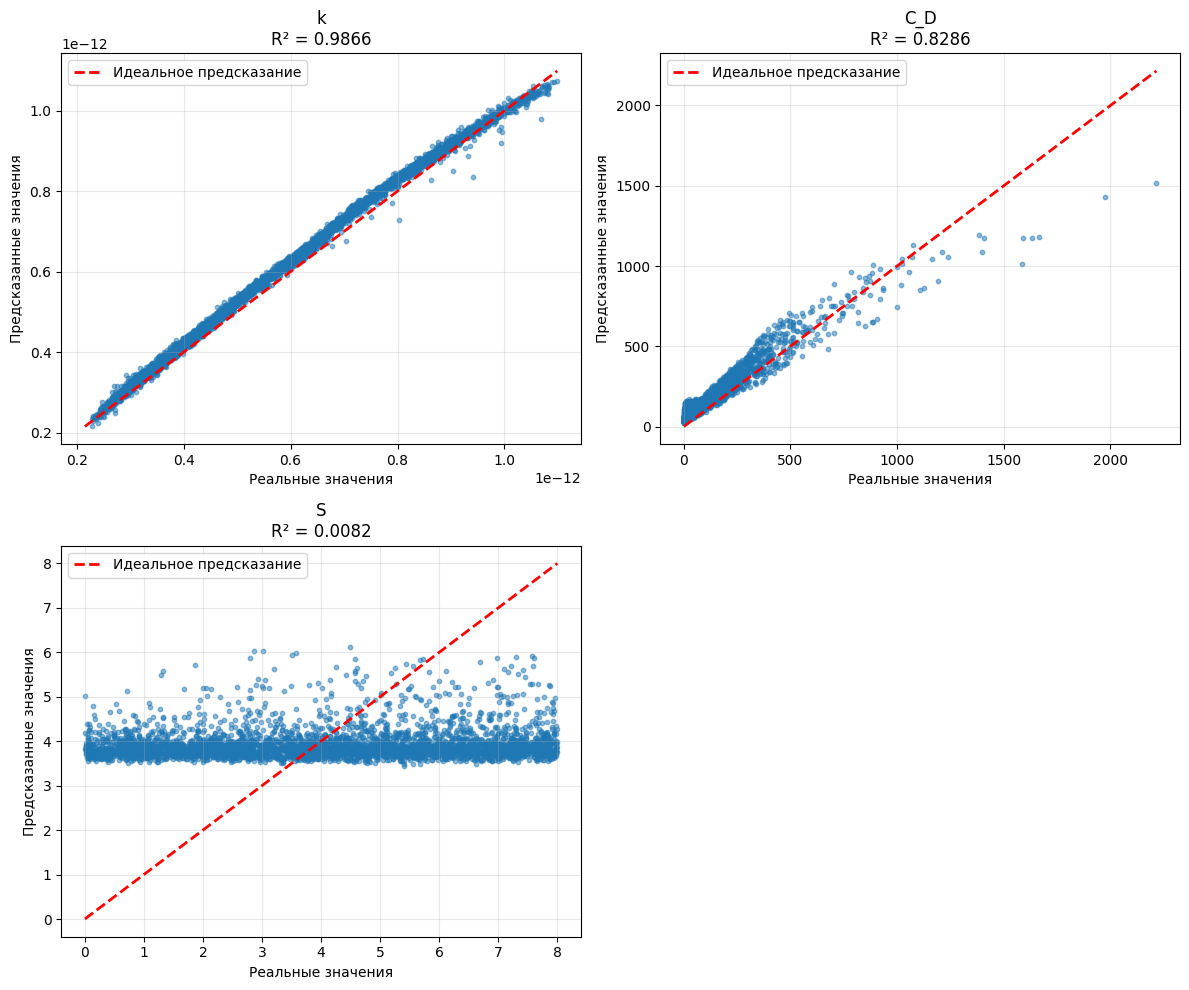

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


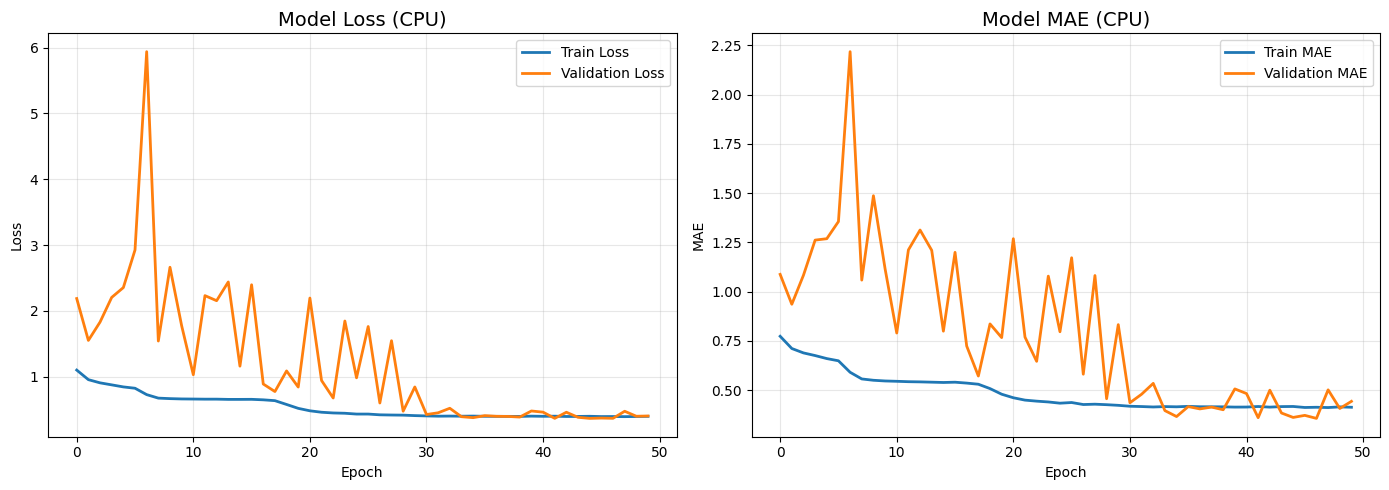

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_homogeneous_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_homogeneous_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_homogeneous_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение однородной модели для бесконечного пласта с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/homogeneous_inf.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/homogeneous_inf',
    model_type=Model.HOMOGENEOUS_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 3).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 3).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 3).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler()
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=3, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k', 'C_D', 'S']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=5e-05
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_homogeneous_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_homogeneous_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_homogeneous_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение однородной модели для кругового пласта

In [ ]:
!unzip /content/drive/MyDrive/homogeneous_inf_04.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: homogeneous_inf_04/params/24.csv  
  inflating: homogeneous_inf_04/params/46.csv  
  inflating: homogeneous_inf_04/params/48.csv  
  inflating: homogeneous_inf_04/params/85.csv  
  inflating: homogeneous_inf_04/params/168.csv  
  inflating: homogeneous_inf_04/params/183.csv  
  inflating: homogeneous_inf_04/params/208.csv  
  inflating: homogeneous_inf_04/params/209.csv  
  inflating: homogeneous_inf_04/params/215.csv  
  inflating: homogeneous_inf_04/params/226.csv  
  inflating: homogeneous_inf_04/params/252.csv  
  inflating: homogeneous_inf_04/params/268.csv  
  inflating: homogeneous_inf_04/params/274.csv  
  inflating: homogeneous_inf_04/params/283.csv  
  inflating: homogeneous_inf_04/params/290.csv  
  inflating: homogeneous_inf_04/params/311.csv  
  inflating: homogeneous_inf_04/params/314.csv  
  inflating: homogeneous_inf_04/params/319.csv  
  inflating: homogeneous_inf_04/params/328.csv  
  inf

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/homogeneous_inf_04',
    model_type=Model.HOMOGENEOUS_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 4).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 4).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 4).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler()
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.2264371666970877 1.0984148631897956 0.62631418307131
Transformed data:  0.2326586662251252 1.0956399349855357 0.6292000564054346
Transformed data:  0.22588472771880186 1.0897512533040221 0.6266968722344399


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=4, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k', 'C_D', 'S', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=50,
    initial_lr=0.00005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (14000, 128, 2), y (14000, 4)
Валидационные данные: X (2000, 128, 2), y (2000, 4)
Эпохи: 50

Epoch 1: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 1.4851 - mae: 0.9066 - mse: 1.4851
Epoch 1: val_loss improved from None to 1.29975, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - loss: 1.2080 - mae: 0.8217 - mse: 1.2080 - val_loss: 1.2998 - val_mae: 0.8697 - val_mse: 1.2998 - learning_rate: 5.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.9904 - mae: 0.7335 - mse: 0.9904
Epoch 2: val_loss did not improve from 1.29975
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - loss: 0.9561 - mae: 0.7196 - mse: 0.9561 - val_loss: 1.3265 - val_mae: 0.9538 - val_mse: 1.3265 - learning_rate: 5.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.9123 - mae: 0.6937 - mse: 0.9123
Epoch 3: val_loss did not improve from 1.29975
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.8850 - mae: 0.6853 - mse: 0.8850 - val_loss: 1.5190 - val_mae: 0.9509 - val_mse: 1.5190 - learning_rate


Epoch 4: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.8335 - mae: 0.6565 - mse: 0.8335 - val_loss: 0.8121 - val_mae: 0.6681 - val_mse: 0.8121 - learning_rate: 5.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8287 - mae: 0.6498 - mse: 0.8287
Epoch 5: val_loss improved from 0.81207 to 0.77683, saving model to best_model_regression.h5



Epoch 5: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.8040 - mae: 0.6439 - mse: 0.8040 - val_loss: 0.7768 - val_mae: 0.6321 - val_mse: 0.7768 - learning_rate: 5.0000e-05

Epoch 6: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.7764 - mae: 0.6307 - mse: 0.7764
Epoch 6: val_loss did not improve from 0.77683
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.7675 - mae: 0.6270 - mse: 0.7675 - val_loss: 1.0409 - val_mae: 0.7371 - val_mse: 1.0409 - learning_rate: 5.0000e-05

Epoch 7: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.7342 - mae: 0.6185 - mse: 0.7342
Epoch 7: val_loss did not improve from 0.77683
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.7508 - mae: 0.6189 - mse: 0.7508 - val_loss: 1.5819 - val_mae: 0.9402 - val_mse: 1.5819 - learning_rate


Epoch 8: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.7333 - mae: 0.6094 - mse: 0.7333 - val_loss: 0.6929 - val_mae: 0.6705 - val_mse: 0.6929 - learning_rate: 5.0000e-05

Epoch 9: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.7146 - mae: 0.5967 - mse: 0.7146
Epoch 9: val_loss did not improve from 0.69291
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.7145 - mae: 0.6002 - mse: 0.7145 - val_loss: 1.0651 - val_mae: 0.7891 - val_mse: 1.0651 - learning_rate: 5.0000e-05

Epoch 10: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.6839 - mae: 0.5951 - mse: 0.6839
Epoch 10: val_loss did not improve from 0.69291
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.6971 - mae: 0.5963 - mse: 0.6971 - val_loss: 0.7380 - val_mae: 0.6724 - val_mse: 0.7380 - learning_r

...


Epoch 36: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.4456 - mae: 0.4724 - mse: 0.4456 - val_loss: 0.2704 - val_mae: 0.3019 - val_mse: 0.2704 - learning_rate: 1.2500e-06

Epoch 37: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 37/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.4450 - mae: 0.4712 - mse: 0.4450
Epoch 37: val_loss did not improve from 0.27043
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 0.4422 - mae: 0.4708 - mse: 0.4422 - val_loss: 0.2706 - val_mae: 0.3054 - val_mse: 0.2706 - learning_rate: 1.2500e-06

Epoch 38: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 38/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.4457 - mae: 0.4718 - mse: 0.4457
Epoch 38: val_loss did not improve from 0.27043
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.4450 - mae: 0.4724 - mse: 0.4450 - val_loss: 0.2761 - val_mae: 0.3174 - val_mse: 0.2761 - learni


Epoch 39: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.4504 - mae: 0.4758 - mse: 0.4504 - val_loss: 0.2698 - val_mae: 0.3045 - val_mse: 0.2698 - learning_rate: 1.2500e-06

Epoch 40: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 40/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.4401 - mae: 0.4697 - mse: 0.4401
Epoch 40: val_loss did not improve from 0.26981
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.4387 - mae: 0.4702 - mse: 0.4387 - val_loss: 0.2855 - val_mae: 0.3328 - val_mse: 0.2855 - learning_rate: 1.2500e-06

Epoch 41: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 41/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.4412 - mae: 0.4740 - mse: 0.4412
Epoch 41: val_loss did not improve from 0.26981
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 0.4451 - mae: 0.4739 - mse: 0.4451 - val_loss: 0.2774 - val_mae: 0.3245 - val_mse: 0.2774 - learni


Epoch 44: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.4397 - mae: 0.4718 - mse: 0.4397 - val_loss: 0.2691 - val_mae: 0.2989 - val_mse: 0.2691 - learning_rate: 1.2500e-06

Epoch 45: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 45/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.4353 - mae: 0.4695 - mse: 0.4353
Epoch 45: val_loss did not improve from 0.26911
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 0.4415 - mae: 0.4732 - mse: 0.4415 - val_loss: 0.3336 - val_mae: 0.4018 - val_mse: 0.3336 - learning_rate: 1.2500e-06

Epoch 46: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 46/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.4469 - mae: 0.4737 - mse: 0.4469
Epoch 46: val_loss did not improve from 0.26911
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 0.4452 - mae: 0.4730 - mse: 0.4452 - val_loss: 0.2697 - val_mae: 0.3040 - val_mse: 0.2697 - learni


Epoch 47: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.4401 - mae: 0.4700 - mse: 0.4401 - val_loss: 0.2682 - val_mae: 0.3003 - val_mse: 0.2682 - learning_rate: 1.2500e-06

Epoch 48: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 48/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.4344 - mae: 0.4682 - mse: 0.4344
Epoch 48: val_loss did not improve from 0.26818
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.4406 - mae: 0.4703 - mse: 0.4406 - val_loss: 0.2699 - val_mae: 0.3045 - val_mse: 0.2699 - learning_rate: 1.2500e-06

Epoch 49: LearningRateScheduler setting learning rate to 1.249999968422344e-06.
Epoch 49/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.4458 - mae: 0.4723 - mse: 0.4458
Epoch 49: val_loss did not improve from 0.26818
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 0.4420 - mae: 0.4719 - mse: 0.4420 - val_loss: 0.2705 - val_mae: 0.3060 - val_mse: 0.2705 - learni

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.2796
  mae: 0.3191
  mse: 0.2796

📊 Регрессионные метрики (в исходном масштабе):

  k:
    MSE:  2.0901e-27
    MAE:  3.7940e-14
    R²:   0.9559

  C_D:
    MSE:  1.3824e+03
    MAE:  2.6077e+01
    R²:   0.9558

  S:
    MSE:  5.3654e+00
    MAE:  1.9997e+00
    R²:   -0.0020
    ⚠️  КРИТИЧЕСКАЯ ОШИБКА: Модель работает хуже константы (среднего)!

  r_D_e:
    MSE:  7.9580e+04
    MAE:  2.1565e+02
    R²:   0.9882


Количество выходов: 4
Форма y_test_orig: (4000, 4)
Results: 2.0611424622184876e-13 1.0864089575873814e-12
Results: 2.2588472771880186e-13 1.089751253304022e-12


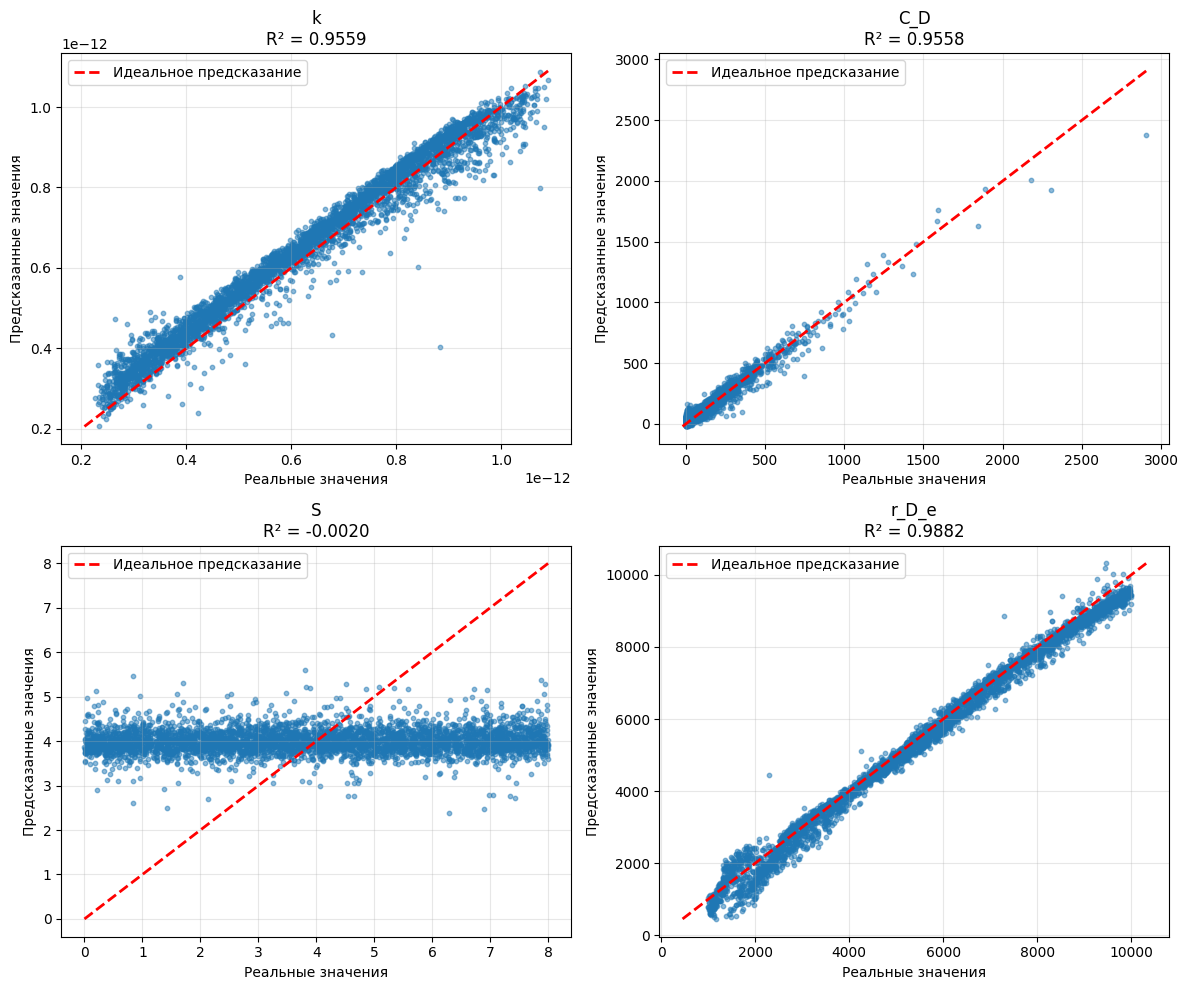

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


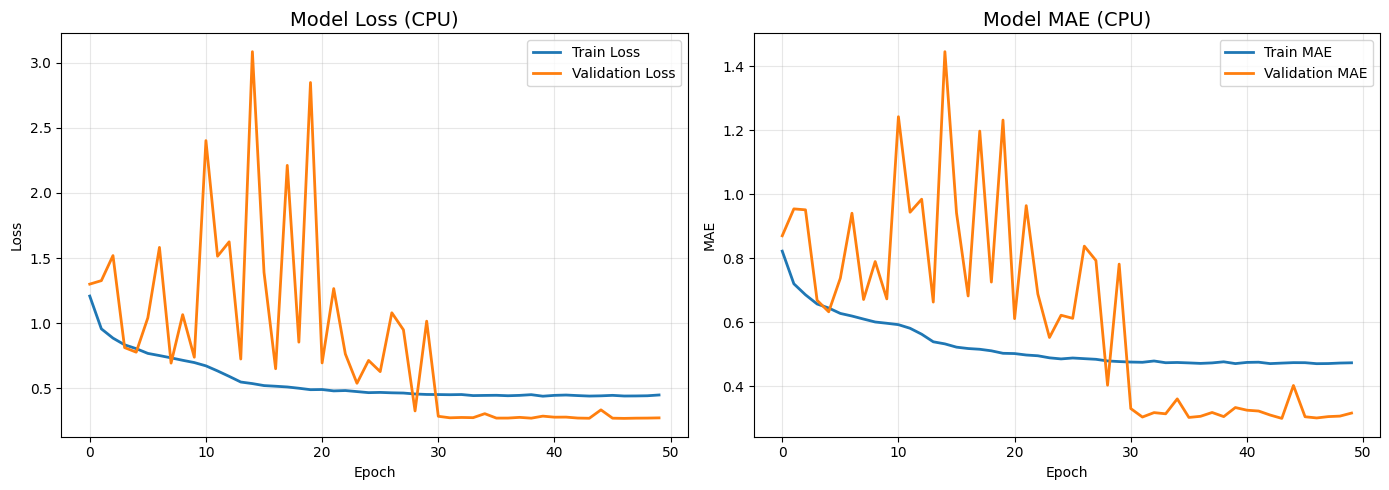

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_homogeneous_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_homogeneous_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_homogeneous_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение однородной модели для кругового пласта с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/homogeneous_fin.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/homogeneous_fin',
    model_type=Model.HOMOGENEOUS_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 4).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 4).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 4).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler()
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=4, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k', 'C_D', 'S', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=5e-05
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_homogeneous_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_homogeneous_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_homogeneous_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение для модели двойной пористости для бесконечного пласта

In [ ]:
!unzip /content/drive/MyDrive/dual_porosity_inf.zip

Archive:  /content/drive/MyDrive/dual_porosity_inf.zip
replace dual_porosity_inf/curve/dual_porosity_inf_2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/dual_porosity_inf',
    model_type=Model.DUAL_POROSITY_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
# y_train shape: (14000, 6, 1) - [образцы, временные шаги, признаки]
# Нам нужен 4-й временной шаг (индекс 4) и 0-й признак (т.к. последняя размерность 1)

# Создаем маски на основе значения в 4-м временном шаге
mask_train = y_train[:, 4, 0] <= 1e-4  # (14000,) - булевый массив
mask_val = y_val[:, 4, 0] <= 1e-4
mask_test = y_test[:, 4, 0] <= 1e-4

# Применяем маски к X и y
X_train_filtered = X_train[mask_train]  # (N, 128, 2)
y_train_filtered = y_train[mask_train]  # (N, 6, 1)

X_val_filtered = X_val[mask_val]
y_val_filtered = y_val[mask_val]

X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

# Проверяем результат
print(f"Train: {y_train.shape[0]} -> {y_train_filtered.shape[0]} (удалено: {y_train.shape[0] - y_train_filtered.shape[0]})")
print(f"Val:   {y_val.shape[0]} -> {y_val_filtered.shape[0]} (удалено: {y_val.shape[0] - y_val_filtered.shape[0]})")
print(f"Test:  {y_test.shape[0]} -> {y_test_filtered.shape[0]} (удалено: {y_test.shape[0] - y_test_filtered.shape[0]})")

# Проверяем новые формы
print(f"\nНовые формы:")
print(f"X_train_filtered shape: {X_train_filtered.shape}")
print(f"y_train_filtered shape: {y_train_filtered.shape}")

X_train = X_train_filtered
X_val = X_val_filtered
X_test = X_test_filtered

y_train = y_train_filtered
y_val = y_val_filtered
y_test = y_test_filtered

Train: 14000 -> 12308 (удалено: 1692)
Val:   2000 -> 1754 (удалено: 246)
Test:  4000 -> 3521 (удалено: 479)

Новые формы:
X_train_filtered shape: (12308, 128, 2)
y_train_filtered shape: (12308, 5, 1)


In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 5).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 5).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 5).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.2267480629883084 1.096273239679707 0.628737009586384
Transformed data:  0.22631267286382606 1.0952505660546108 0.6334499360036825
Transformed data:  0.22783837512062993 1.092473272406448 0.6290026549291218


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=5, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k_f', 'C_D', 'S', 'omega', 'lambda']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=80,
    initial_lr=0.00005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (12308, 128, 2), y (12308, 5)
Валидационные данные: X (1754, 128, 2), y (1754, 5)
Эпохи: 80

Epoch 1: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 1/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 1.3848 - mae: 0.8453 - mse: 1.3848
Epoch 1: val_loss improved from None to 1.08699, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - loss: 1.2281 - mae: 0.7859 - mse: 1.2281 - val_loss: 1.0870 - val_mae: 0.8102 - val_mse: 1.0870 - learning_rate: 5.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 2/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.0412 - mae: 0.7104 - mse: 1.0412
Epoch 2: val_loss did not improve from 1.08699
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - loss: 1.0425 - mae: 0.7049 - mse: 1.0425 - val_loss: 2.3405 - val_mae: 1.1762 - val_mse: 2.3405 - learning_rate: 5.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 3/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.0123 - mae: 0.6862 - mse: 1.0123
Epoch 3: val_loss did not improve from 1.08699
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - loss: 0.9876 - mae: 0.6783 - mse: 0.9876 - val_loss: 2.2273 - val_mae: 1.0958 - val_mse: 2.2273 - learning


Epoch 6: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - loss: 0.8526 - mae: 0.6276 - mse: 0.8526 - val_loss: 0.9735 - val_mae: 0.7655 - val_mse: 0.9735 - learning_rate: 5.0000e-05

Epoch 7: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 7/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.8253 - mae: 0.6192 - mse: 0.8253
Epoch 7: val_loss did not improve from 0.97352
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.8108 - mae: 0.6146 - mse: 0.8108 - val_loss: 2.2420 - val_mae: 1.2292 - val_mse: 2.2420 - learning_rate: 5.0000e-05

Epoch 8: LearningRateScheduler setting learning rate to 4.999999873689376e-05.
Epoch 8/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.7767 - mae: 0.6088 - mse: 0.7767
Epoch 8: val_loss did not improve from 0.97352
193/193 ━━━━━━━━━━━━━━━━━━━━ 47s 156ms/step - loss: 0.7799 - mae: 0.6037 - mse: 0.7799 - val_loss: 2.1644 - val_mae: 1.2504 - val_mse: 2.1644 - learning


Epoch 12: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - loss: 0.5696 - mae: 0.5335 - mse: 0.5696 - val_loss: 0.8414 - val_mae: 0.7173 - val_mse: 0.8414 - learning_rate: 2.5000e-05

Epoch 13: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 13/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.5545 - mae: 0.5263 - mse: 0.5545
Epoch 13: val_loss improved from 0.84144 to 0.79134, saving model to best_model_regression.h5



Epoch 13: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 119ms/step - loss: 0.5508 - mae: 0.5244 - mse: 0.5508 - val_loss: 0.7913 - val_mae: 0.6623 - val_mse: 0.7913 - learning_rate: 2.5000e-05

Epoch 14: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 14/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.5331 - mae: 0.5198 - mse: 0.5331
Epoch 14: val_loss did not improve from 0.79134
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - loss: 0.5354 - mae: 0.5185 - mse: 0.5354 - val_loss: 0.8426 - val_mae: 0.6848 - val_mse: 0.8426 - learning_rate: 2.5000e-05

Epoch 15: LearningRateScheduler setting learning rate to 2.499999936844688e-05.
Epoch 15/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.5152 - mae: 0.5095 - mse: 0.5152
Epoch 15: val_loss improved from 0.79134 to 0.77120, saving model to best_model_regression.h5


...


Epoch 53: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - loss: 0.2278 - mae: 0.3227 - mse: 0.2278 - val_loss: 0.1019 - val_mae: 0.2031 - val_mse: 0.1019 - learning_rate: 6.2500e-08

Epoch 54: LearningRateScheduler setting learning rate to 6.249999984220267e-08.
Epoch 54/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2349 - mae: 0.3280 - mse: 0.2349
Epoch 54: val_loss did not improve from 0.10186
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - loss: 0.2340 - mae: 0.3273 - mse: 0.2340 - val_loss: 0.1021 - val_mae: 0.2024 - val_mse: 0.1021 - learning_rate: 6.2500e-08

Epoch 55: LearningRateScheduler setting learning rate to 6.249999984220267e-08.
Epoch 55/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2253 - mae: 0.3237 - mse: 0.2253
Epoch 55: val_loss did not improve from 0.10186
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - loss: 0.2275 - mae: 0.3236 - mse: 0.2275 - val_loss: 0.1019 - val_mae: 0.2028 - val_mse: 0.1019 - l


Epoch 57: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.2292 - mae: 0.3222 - mse: 0.2292 - val_loss: 0.1015 - val_mae: 0.2029 - val_mse: 0.1015 - learning_rate: 6.2500e-08

Epoch 58: LearningRateScheduler setting learning rate to 6.249999984220267e-08.
Epoch 58/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.2218 - mae: 0.3217 - mse: 0.2218
Epoch 58: val_loss improved from 0.10149 to 0.10105, saving model to best_model_regression.h5



Epoch 58: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.2235 - mae: 0.3200 - mse: 0.2235 - val_loss: 0.1010 - val_mae: 0.2036 - val_mse: 0.1010 - learning_rate: 6.2500e-08

Epoch 59: LearningRateScheduler setting learning rate to 6.249999984220267e-08.
Epoch 59/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2276 - mae: 0.3218 - mse: 0.2276
Epoch 59: val_loss did not improve from 0.10105
193/193 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - loss: 0.2333 - mae: 0.3241 - mse: 0.2333 - val_loss: 0.1020 - val_mae: 0.2018 - val_mse: 0.1020 - learning_rate: 6.2500e-08

Epoch 60: LearningRateScheduler setting learning rate to 6.249999984220267e-08.
Epoch 60/80
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2294 - mae: 0.3240 - mse: 0.2294
Epoch 60: val_loss did not improve from 0.10105
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - loss: 0.2308 - mae: 0.3239 - mse: 0.2308 - val_loss: 0.1017 - val_mae: 0.2023 - val_mse: 0.1017 - l


Epoch 80: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.2280 - mae: 0.3234 - mse: 0.2280 - val_loss: 0.1009 - val_mae: 0.2032 - val_mse: 0.1009 - learning_rate: 6.2500e-09

✅ Обучение завершено за 2659.12 секунд
✅ Лучшая модель сохранена в: best_model_regression.h5


✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.1101
  mae: 0.2078
  mse: 0.1101

📊 Регрессионные метрики (в исходном масштабе):

  k_f:
    MSE:  1.8156e-27
    MAE:  2.7788e-14
    R²:   0.9633

  C_D:
    MSE:  2.0656e+03
    MAE:  3.2091e+01
    R²:   0.9036

  S:
    MSE:  9.3352e-01
    MAE:  7.5469e-01
    R²:   0.8887

  omega:
    MSE:  2.7572e-04
    MAE:  1.0903e-02
    R²:   0.8335

  lambda:
    MSE:  2.2079e-11
    MAE:  2.1797e-06
    R²:   0.8493


Количество выходов: 5
Форма y_test_orig: (3521, 5)
Results: 1.6931027164036189e-13 1.0681273573953654e-12
Results: 2.278383751206299e-13 1.092473272406448e-12


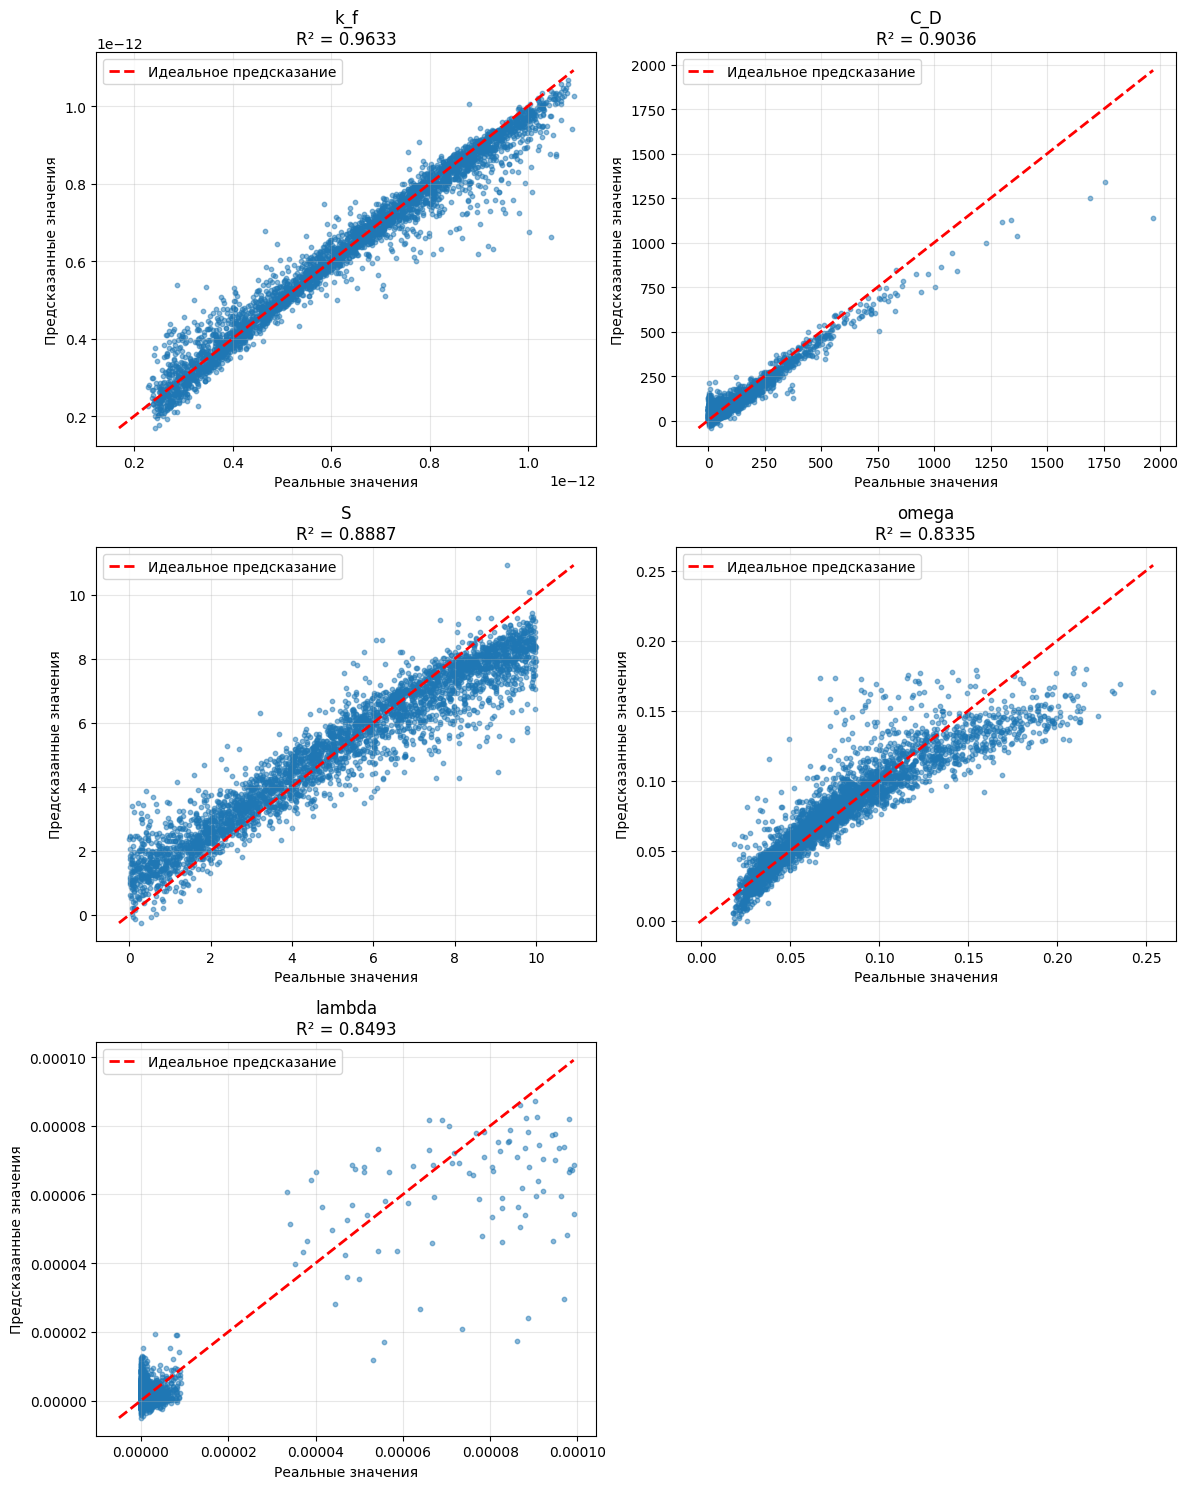

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


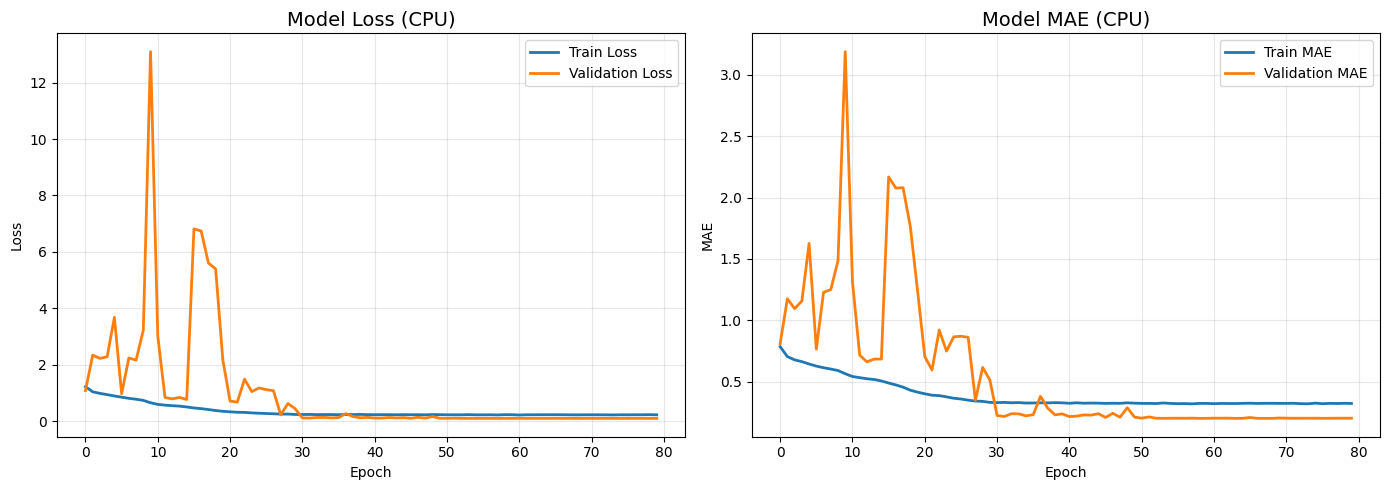

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_porosity_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_porosity_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_porosity_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение двойная пористость бесконечный пласт с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/dual_porosity_inf.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/dual_porosity_inf',
    model_type=Model.DUAL_POROSITY_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 5).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 5).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 5).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=5, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k_f', 'C_D', 'S', 'omega', 'lambda']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.0005
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_porosity_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_porosity_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_porosity_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение для модели двойной пористости для кругового пласта

In [ ]:
!unzip /content/drive/MyDrive/dual_porosity_fin.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dual_porosity_fin/params/24.csv  
  inflating: dual_porosity_fin/params/46.csv  
  inflating: dual_porosity_fin/params/48.csv  
  inflating: dual_porosity_fin/params/85.csv  
  inflating: dual_porosity_fin/params/168.csv  
  inflating: dual_porosity_fin/params/183.csv  
  inflating: dual_porosity_fin/params/208.csv  
  inflating: dual_porosity_fin/params/209.csv  
  inflating: dual_porosity_fin/params/215.csv  
  inflating: dual_porosity_fin/params/226.csv  
  inflating: dual_porosity_fin/params/252.csv  
  inflating: dual_porosity_fin/params/268.csv  
  inflating: dual_porosity_fin/params/274.csv  
  inflating: dual_porosity_fin/params/283.csv  
  inflating: dual_porosity_fin/params/290.csv  
  inflating: dual_porosity_fin/params/311.csv  
  inflating: dual_porosity_fin/params/314.csv  
  inflating: dual_porosity_fin/params/319.csv  
  inflating: dual_porosity_fin/params/328.csv  
  inflating: dual_porosi

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/dual_porosity_fin',
    model_type=Model.DUAL_POROSITY_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
# y_train shape: (14000, 6, 1) - [образцы, временные шаги, признаки]
# Нам нужен 4-й временной шаг (индекс 4) и 0-й признак (т.к. последняя размерность 1)

# Создаем маски на основе значения в 4-м временном шаге
mask_train = y_train[:, 4, 0] <= 1e-4  # (14000,) - булевый массив
mask_val = y_val[:, 4, 0] <= 1e-4
mask_test = y_test[:, 4, 0] <= 1e-4

# Применяем маски к X и y
X_train_filtered = X_train[mask_train]  # (N, 128, 2)
y_train_filtered = y_train[mask_train]  # (N, 6, 1)

X_val_filtered = X_val[mask_val]
y_val_filtered = y_val[mask_val]

X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

# Проверяем результат
print(f"Train: {y_train.shape[0]} -> {y_train_filtered.shape[0]} (удалено: {y_train.shape[0] - y_train_filtered.shape[0]})")
print(f"Val:   {y_val.shape[0]} -> {y_val_filtered.shape[0]} (удалено: {y_val.shape[0] - y_val_filtered.shape[0]})")
print(f"Test:  {y_test.shape[0]} -> {y_test_filtered.shape[0]} (удалено: {y_test.shape[0] - y_test_filtered.shape[0]})")

# Проверяем новые формы
print(f"\nНовые формы:")
print(f"X_train_filtered shape: {X_train_filtered.shape}")
print(f"y_train_filtered shape: {y_train_filtered.shape}")

Train: 14000 -> 12312 (удалено: 1688)
Val:   2000 -> 1758 (удалено: 242)
Test:  4000 -> 3529 (удалено: 471)

Новые формы:
X_train_filtered shape: (12312, 128, 2)
y_train_filtered shape: (12312, 6, 1)


In [ ]:
X_train = X_train_filtered
X_val = X_val_filtered
X_test = X_test_filtered

y_train = y_train_filtered
y_val = y_val_filtered
y_test = y_test_filtered

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.22765317130208096 1.0926023009041956 0.6258669779225164
Transformed data:  0.22873722160260632 1.0797450479386097 0.6218418357230625
Transformed data:  0.22880017887681312 1.0934699605050129 0.6309434538306437


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k_f', 'C_D', 'S', 'omega', 'lambda', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=50,
    initial_lr=0.0005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (12312, 128, 2), y (12312, 6)
Валидационные данные: X (1758, 128, 2), y (1758, 6)
Эпохи: 50

Epoch 1: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 1/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 1.3930 - mae: 0.8605 - mse: 1.3930
Epoch 1: val_loss improved from None to 2.21340, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 32s 124ms/step - loss: 1.1797 - mae: 0.7805 - mse: 1.1797 - val_loss: 2.2134 - val_mae: 1.1291 - val_mse: 2.2134 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.8727 - mae: 0.6502 - mse: 0.8727
Epoch 2: val_loss did not improve from 2.21340
193/193 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - loss: 0.8126 - mae: 0.6207 - mse: 0.8126 - val_loss: 2.4855 - val_mae: 1.2207 - val_mse: 2.4855 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 3/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.6154 - mae: 0.5416 - mse: 0.6154
Epoch 3: val_loss did not improve from 2.21340
193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - loss: 0.5865 - mae: 0.5316 - mse: 0.5865 - val_loss: 4.9644 - val_mae: 1.7633 - val_mse: 4.9644 - learning


Epoch 7: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - loss: 0.2793 - mae: 0.3599 - mse: 0.2793 - val_loss: 0.3643 - val_mae: 0.4261 - val_mse: 0.3643 - learning_rate: 2.5000e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 8/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.2702 - mae: 0.3469 - mse: 0.2702
Epoch 8: val_loss did not improve from 0.36428
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - loss: 0.2610 - mae: 0.3446 - mse: 0.2610 - val_loss: 0.4982 - val_mae: 0.5178 - val_mse: 0.4982 - learning_rate: 2.5000e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 9/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.2539 - mae: 0.3394 - mse: 0.2539
Epoch 9: val_loss did not improve from 0.36428
193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - loss: 0.2483 - mae: 0.3369 - mse: 0.2483 - val_loss: 1.4674 - val_mae: 0.8783 - val_mse: 1.4674 - learning


Epoch 19: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - loss: 0.1849 - mae: 0.2863 - mse: 0.1849 - val_loss: 0.2541 - val_mae: 0.3518 - val_mse: 0.2541 - learning_rate: 6.2500e-05

Epoch 20: LearningRateScheduler setting learning rate to 6.25000029685907e-05.
Epoch 20/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1830 - mae: 0.2844 - mse: 0.1830
Epoch 20: val_loss did not improve from 0.25412
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - loss: 0.1834 - mae: 0.2849 - mse: 0.1834 - val_loss: 0.3509 - val_mae: 0.3654 - val_mse: 0.3509 - learning_rate: 6.2500e-05

Epoch 21: LearningRateScheduler setting learning rate to 6.25000029685907e-05.
Epoch 21/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1790 - mae: 0.2818 - mse: 0.1790
Epoch 21: val_loss did not improve from 0.25412
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - loss: 0.1789 - mae: 0.2811 - mse: 0.1789 - val_loss: 0.2648 - val_mae: 0.3199 - val_mse: 0.2648 - lea


Epoch 26: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - loss: 0.1703 - mae: 0.2726 - mse: 0.1703 - val_loss: 0.1756 - val_mae: 0.2811 - val_mse: 0.1756 - learning_rate: 3.1250e-05

Epoch 27: LearningRateScheduler setting learning rate to 3.125000148429535e-05.
Epoch 27/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1771 - mae: 0.2777 - mse: 0.1771
Epoch 27: val_loss did not improve from 0.17565
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - loss: 0.1730 - mae: 0.2761 - mse: 0.1730 - val_loss: 0.4408 - val_mae: 0.4196 - val_mse: 0.4408 - learning_rate: 3.1250e-05

Epoch 28: LearningRateScheduler setting learning rate to 3.125000148429535e-05.
Epoch 28/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.1751 - mae: 0.2752 - mse: 0.1751
Epoch 28: val_loss did not improve from 0.17565
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - loss: 0.1762 - mae: 0.2754 - mse: 0.1762 - val_loss: 0.1928 - val_mae: 0.2550 - val_mse: 0.1928 - l

...


Epoch 35: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.1666 - mae: 0.2696 - mse: 0.1666 - val_loss: 0.1190 - val_mae: 0.1738 - val_mse: 0.1190 - learning_rate: 3.1250e-06

Epoch 36: LearningRateScheduler setting learning rate to 3.1250001484295353e-06.
Epoch 36/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1622 - mae: 0.2653 - mse: 0.1622
Epoch 36: val_loss did not improve from 0.11900
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - loss: 0.1651 - mae: 0.2681 - mse: 0.1651 - val_loss: 0.1268 - val_mae: 0.1820 - val_mse: 0.1268 - learning_rate: 3.1250e-06

Epoch 37: LearningRateScheduler setting learning rate to 3.1250001484295353e-06.
Epoch 37/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1633 - mae: 0.2685 - mse: 0.1633
Epoch 37: val_loss did not improve from 0.11900
193/193 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - loss: 0.1659 - mae: 0.2685 - mse: 0.1659 - val_loss: 0.1335 - val_mae: 0.1812 - val_mse: 0.1335 -


Epoch 42: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.1696 - mae: 0.2716 - mse: 0.1696 - val_loss: 0.1189 - val_mae: 0.1720 - val_mse: 0.1189 - learning_rate: 1.5625e-06

Epoch 43: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 43/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.1708 - mae: 0.2728 - mse: 0.1708
Epoch 43: val_loss did not improve from 0.11891
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.1688 - mae: 0.2722 - mse: 0.1688 - val_loss: 0.1212 - val_mae: 0.1782 - val_mse: 0.1212 - learning_rate: 1.5625e-06

Epoch 44: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 44/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1665 - mae: 0.2663 - mse: 0.1665
Epoch 44: val_loss did not improve from 0.11891
193/193 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - loss: 0.1653 - mae: 0.2672 - mse: 0.1653 - val_loss: 0.1309 - val_mae: 0.1802 - val_mse: 0.1309 -


Epoch 45: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - loss: 0.1635 - mae: 0.2677 - mse: 0.1635 - val_loss: 0.1186 - val_mae: 0.1705 - val_mse: 0.1186 - learning_rate: 1.5625e-06

Epoch 46: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 46/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.1672 - mae: 0.2682 - mse: 0.1672
Epoch 46: val_loss did not improve from 0.11855
193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - loss: 0.1641 - mae: 0.2682 - mse: 0.1641 - val_loss: 0.1213 - val_mae: 0.1701 - val_mse: 0.1213 - learning_rate: 1.5625e-06

Epoch 47: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 47/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1662 - mae: 0.2688 - mse: 0.1662
Epoch 47: val_loss improved from 0.11855 to 0.11812, saving model to best_model_regression.h5



Epoch 47: finished saving model to best_model_regression.h5
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - loss: 0.1665 - mae: 0.2694 - mse: 0.1665 - val_loss: 0.1181 - val_mae: 0.1689 - val_mse: 0.1181 - learning_rate: 1.5625e-06

Epoch 48: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 48/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.1668 - mae: 0.2685 - mse: 0.1668
Epoch 48: val_loss did not improve from 0.11812
193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - loss: 0.1668 - mae: 0.2705 - mse: 0.1668 - val_loss: 0.1211 - val_mae: 0.1693 - val_mse: 0.1211 - learning_rate: 1.5625e-06

Epoch 49: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 49/50
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1648 - mae: 0.2697 - mse: 0.1648
Epoch 49: val_loss did not improve from 0.11812
193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - loss: 0.1678 - mae: 0.2702 - mse: 0.1678 - val_loss: 0.1209 - val_mae: 0.1691 - val_mse: 0.1209 -

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.0982
  mae: 0.1672
  mse: 0.0982

📊 Регрессионные метрики (в исходном масштабе):

  k_f:
    MSE:  1.5872e-27
    MAE:  2.4751e-14
    R²:   0.9673

  C_D:
    MSE:  3.4806e+02
    MAE:  1.1612e+01
    R²:   0.9861

  S:
    MSE:  4.4586e-01
    MAE:  4.4524e-01
    R²:   0.9453

  omega:
    MSE:  6.5205e-04
    MAE:  1.9148e-02
    R²:   0.6006

  lambda:
    MSE:  1.1016e-11
    MAE:  1.3727e-06
    R²:   0.9169

  r_D_e:
    MSE:  4.8240e+04
    MAE:  1.7678e+02
    R²:   0.9929


Количество выходов: 6
Форма y_test_orig: (3529, 6)
Results: 1.0801884560429631e-13 1.1048925446441316e-12
Results: 2.2880017887681317e-13 1.0934699605050128e-12


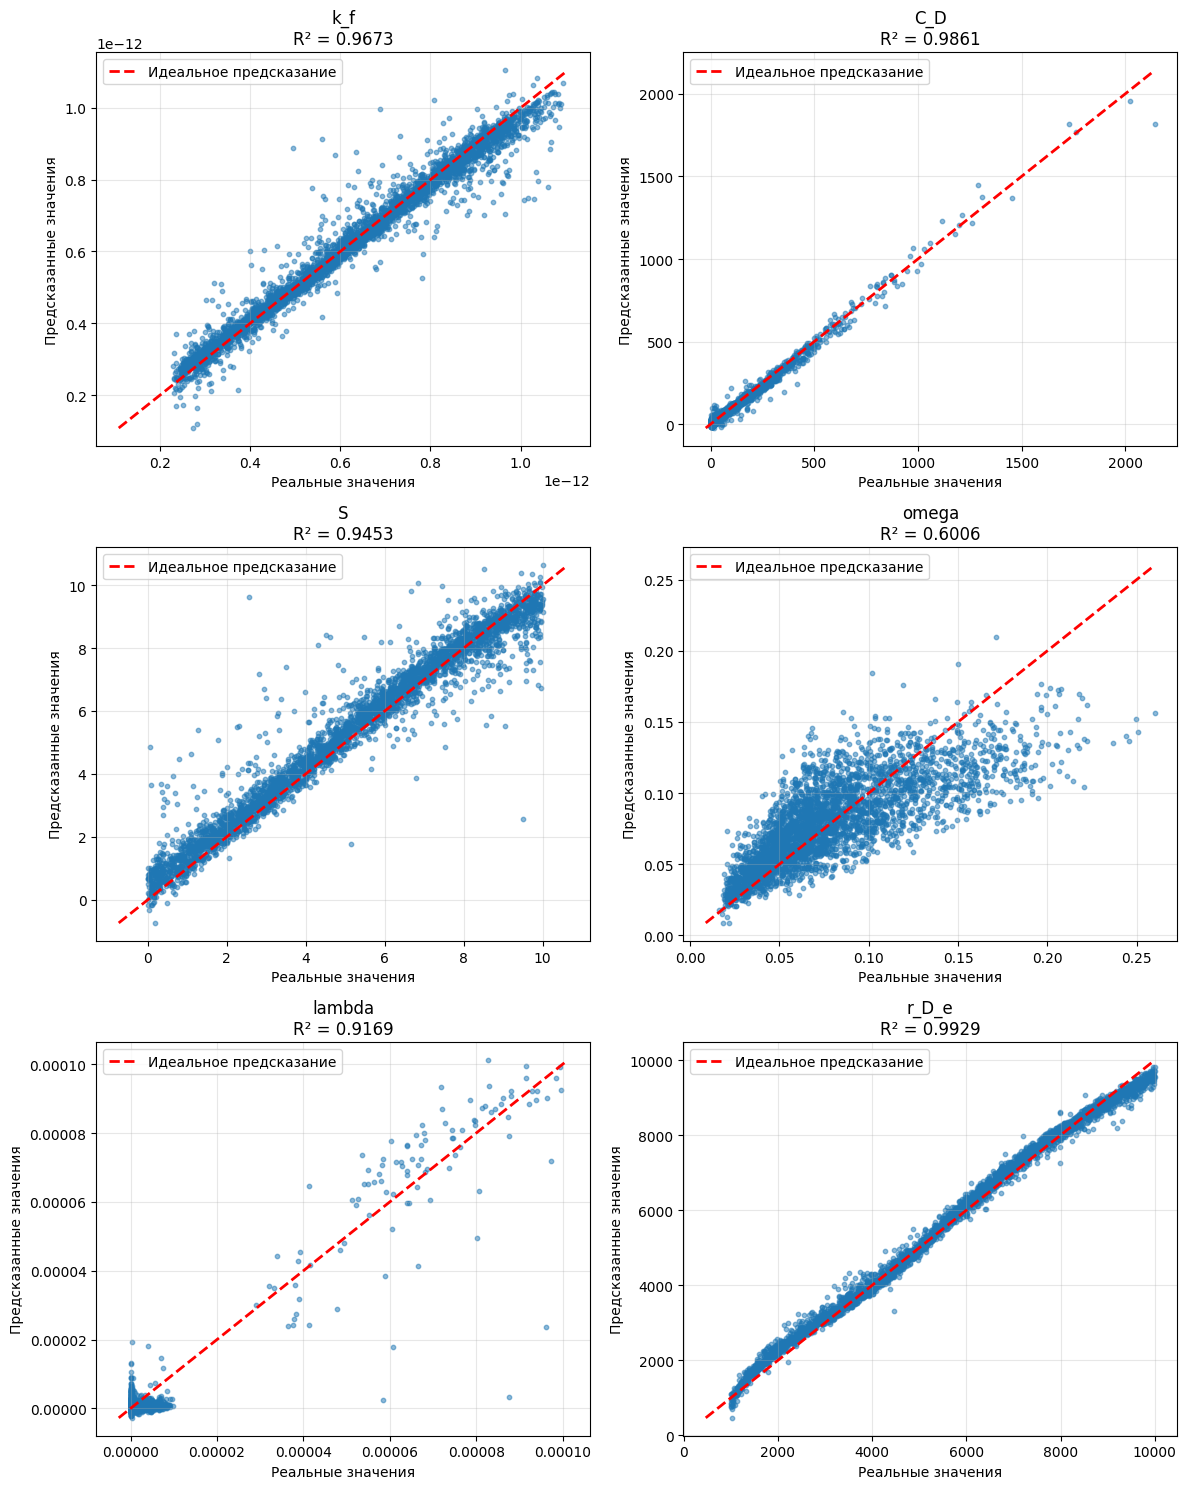

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


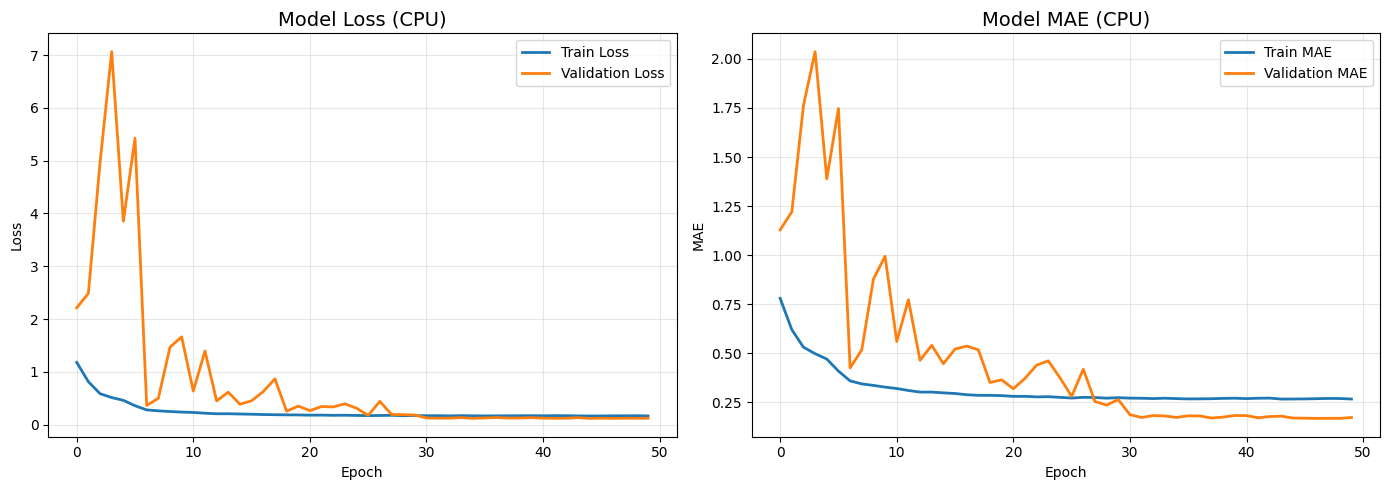

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_porosity_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_porosity_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_porosity_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение двойная пористость круговой пласт с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/dual_porosity_fin.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/dual_porosity_fin',
    model_type=Model.DUAL_POROSITY_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k_f', 'C_D', 'S', 'omega', 'lambda', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.0005
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_porosity_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_porosity_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_porosity_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение для модели двойной проницаемости для бесконечного пласта

In [ ]:
!unzip /content/drive/MyDrive/dual_permeability_inf1.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dual_permeability_inf1/params/24.csv  
  inflating: dual_permeability_inf1/params/46.csv  
  inflating: dual_permeability_inf1/params/48.csv  
  inflating: dual_permeability_inf1/params/85.csv  
  inflating: dual_permeability_inf1/params/168.csv  
  inflating: dual_permeability_inf1/params/183.csv  
  inflating: dual_permeability_inf1/params/208.csv  
  inflating: dual_permeability_inf1/params/209.csv  
  inflating: dual_permeability_inf1/params/215.csv  
  inflating: dual_permeability_inf1/params/226.csv  
  inflating: dual_permeability_inf1/params/252.csv  
  inflating: dual_permeability_inf1/params/268.csv  
  inflating: dual_permeability_inf1/params/274.csv  
  inflating: dual_permeability_inf1/params/283.csv  
  inflating: dual_permeability_inf1/params/290.csv  
  inflating: dual_permeability_inf1/params/311.csv  
  inflating: dual_permeability_inf1/params/314.csv  
  inflating: dual_permeability_inf1

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/dual_permeability_inf1',
    model_type=Model.DUAL_PERMEABILITY_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.009385408643911991 0.794410859885136 0.12621913577498825
Transformed data:  0.008870504534173776 0.733764881511929 0.12692115300976045
Transformed data:  0.00996543770096279 0.6843389650828327 0.1282489693853272


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.0005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (14000, 128, 2), y (14000, 6)
Валидационные данные: X (2000, 128, 2), y (2000, 6)
Эпохи: 100

Epoch 1: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 1.2147 - mae: 0.8169 - mse: 1.2147
Epoch 1: val_loss improved from None to 1.49427, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 34s 131ms/step - loss: 1.0145 - mae: 0.7435 - mse: 1.0145 - val_loss: 1.4943 - val_mae: 0.9684 - val_mse: 1.4943 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.8464 - mae: 0.6704 - mse: 0.8464
Epoch 2: val_loss improved from 1.49427 to 1.14566, saving model to best_model_regression.h5



Epoch 2: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - loss: 0.8116 - mae: 0.6553 - mse: 0.8116 - val_loss: 1.1457 - val_mae: 0.7369 - val_mse: 1.1457 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.7037 - mae: 0.6065 - mse: 0.7037
Epoch 3: val_loss did not improve from 1.14566
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - loss: 0.6531 - mae: 0.5851 - mse: 0.6531 - val_loss: 2.3641 - val_mae: 1.1804 - val_mse: 2.3641 - learning_rate: 5.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.4861 - mae: 0.5073 - mse: 0.4861
Epoch 4: val_loss did not improve from 1.14566
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 125ms/step - loss: 0.4615 - mae: 0.4875 - mse: 0.4615 - val_loss: 11.2010 - val_mae: 2.7231 - val_mse: 11.2010 - lear


Epoch 8: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step - loss: 0.2863 - mae: 0.3706 - mse: 0.2863 - val_loss: 0.5743 - val_mae: 0.5598 - val_mse: 0.5743 - learning_rate: 2.5000e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 9/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2781 - mae: 0.3616 - mse: 0.2781
Epoch 9: val_loss did not improve from 0.57426
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.2710 - mae: 0.3576 - mse: 0.2710 - val_loss: 0.8359 - val_mae: 0.7420 - val_mse: 0.8359 - learning_rate: 2.5000e-04

Epoch 10: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 10/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.2638 - mae: 0.3540 - mse: 0.2638
Epoch 10: val_loss did not improve from 0.57426
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - loss: 0.2625 - mae: 0.3522 - mse: 0.2625 - val_loss: 1.5529 - val_mae: 0.8692 - val_mse: 1.5529 - lea


Epoch 13: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - loss: 0.2436 - mae: 0.3347 - mse: 0.2436 - val_loss: 0.5629 - val_mae: 0.5805 - val_mse: 0.5629 - learning_rate: 2.5000e-04

Epoch 14: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 14/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.2439 - mae: 0.3344 - mse: 0.2439
Epoch 14: val_loss did not improve from 0.56285
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - loss: 0.2392 - mae: 0.3313 - mse: 0.2392 - val_loss: 0.8835 - val_mae: 0.6766 - val_mse: 0.8835 - learning_rate: 2.5000e-04

Epoch 15: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 15/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2379 - mae: 0.3281 - mse: 0.2379
Epoch 15: val_loss did not improve from 0.56285
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - loss: 0.2355 - mae: 0.3272 - mse: 0.2355 - val_loss: 1.0003 - val_mae: 0.8125 - val_mse: 1.0003 -

...


Epoch 52: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - loss: 0.2025 - mae: 0.2947 - mse: 0.2025 - val_loss: 0.1570 - val_mae: 0.2183 - val_mse: 0.1570 - learning_rate: 3.1250e-07

Epoch 53: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 53/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2013 - mae: 0.2958 - mse: 0.2013
Epoch 53: val_loss did not improve from 0.15697
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - loss: 0.2025 - mae: 0.2954 - mse: 0.2025 - val_loss: 0.1570 - val_mae: 0.2181 - val_mse: 0.1570 - learning_rate: 3.1250e-07

Epoch 54: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 54/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.1999 - mae: 0.2927 - mse: 0.1999
Epoch 54: val_loss did not improve from 0.15697
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - loss: 0.1993 - mae: 0.2936 - mse: 0.1993 - val_loss: 0.1570 - val_mae: 0.2181 - val_mse: 0.1570 -


Epoch 60: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - loss: 0.2021 - mae: 0.2953 - mse: 0.2021 - val_loss: 0.1569 - val_mae: 0.2184 - val_mse: 0.1569 - learning_rate: 3.1250e-07

Epoch 61: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 61/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.2031 - mae: 0.2986 - mse: 0.2031
Epoch 61: val_loss did not improve from 0.15688
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - loss: 0.2045 - mae: 0.2983 - mse: 0.2045 - val_loss: 0.1570 - val_mae: 0.2182 - val_mse: 0.1570 - learning_rate: 3.1250e-07

Epoch 62: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 62/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.2031 - mae: 0.2970 - mse: 0.2031
Epoch 62: val_loss improved from 0.15688 to 0.15683, saving model to best_model_regression.h5



Epoch 62: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 121ms/step - loss: 0.2018 - mae: 0.2961 - mse: 0.2018 - val_loss: 0.1568 - val_mae: 0.2184 - val_mse: 0.1568 - learning_rate: 3.1250e-07

Epoch 63: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 63/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2039 - mae: 0.2964 - mse: 0.2039
Epoch 63: val_loss did not improve from 0.15683
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - loss: 0.2011 - mae: 0.2955 - mse: 0.2011 - val_loss: 0.1571 - val_mae: 0.2182 - val_mse: 0.1571 - learning_rate: 3.1250e-07

Epoch 64: LearningRateScheduler setting learning rate to 3.125000205272954e-07.
Epoch 64/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2017 - mae: 0.2953 - mse: 0.2017
Epoch 64: val_loss did not improve from 0.15683
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - loss: 0.2024 - mae: 0.2951 - mse: 0.2024 - val_loss: 0.1571 - val_mae: 0.2182 - val_mse: 0.1571 -


Epoch 84: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.2022 - mae: 0.2959 - mse: 0.2022 - val_loss: 0.1567 - val_mae: 0.2180 - val_mse: 0.1567 - learning_rate: 3.1250e-08

Epoch 85: LearningRateScheduler setting learning rate to 3.1250003473815013e-08.
Epoch 85/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.2026 - mae: 0.2957 - mse: 0.2026
Epoch 85: val_loss did not improve from 0.15671
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - loss: 0.2049 - mae: 0.2970 - mse: 0.2049 - val_loss: 0.1570 - val_mae: 0.2180 - val_mse: 0.1570 - learning_rate: 3.1250e-08

Epoch 86: LearningRateScheduler setting learning rate to 3.1250003473815013e-08.
Epoch 86/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.2027 - mae: 0.2978 - mse: 0.2027
Epoch 86: val_loss did not improve from 0.15671
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - loss: 0.2056 - mae: 0.2982 - mse: 0.2056 - val_loss: 0.1569 - val_mae: 0.2181 - val_mse: 0.1569

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.1528
  mae: 0.2168
  mse: 0.1528

📊 Регрессионные метрики (в исходном масштабе):

  k1:
    MSE:  2.7797e-29
    MAE:  3.7178e-15
    R²:   0.9967

  C_D:
    MSE:  6.5090e+01
    MAE:  5.1775e+00
    R²:   0.9922

  S1:
    MSE:  9.5727e-02
    MAE:  2.3500e-01
    R²:   0.9884

  omega:
    MSE:  3.8914e-04
    MAE:  1.4508e-02
    R²:   0.7420

  lambda:
    MSE:  2.5409e-12
    MAE:  7.6880e-07
    R²:   0.9266

  kappa:
    MSE:  2.9038e-03
    MAE:  4.4162e-02
    R²:   0.4398


Количество выходов: 6
Форма y_test_orig: (4000, 6)
Results: -3.1260280314011988e-15 6.997266806772762e-13
Results: 9.965437700962781e-15 6.843389650828327e-13


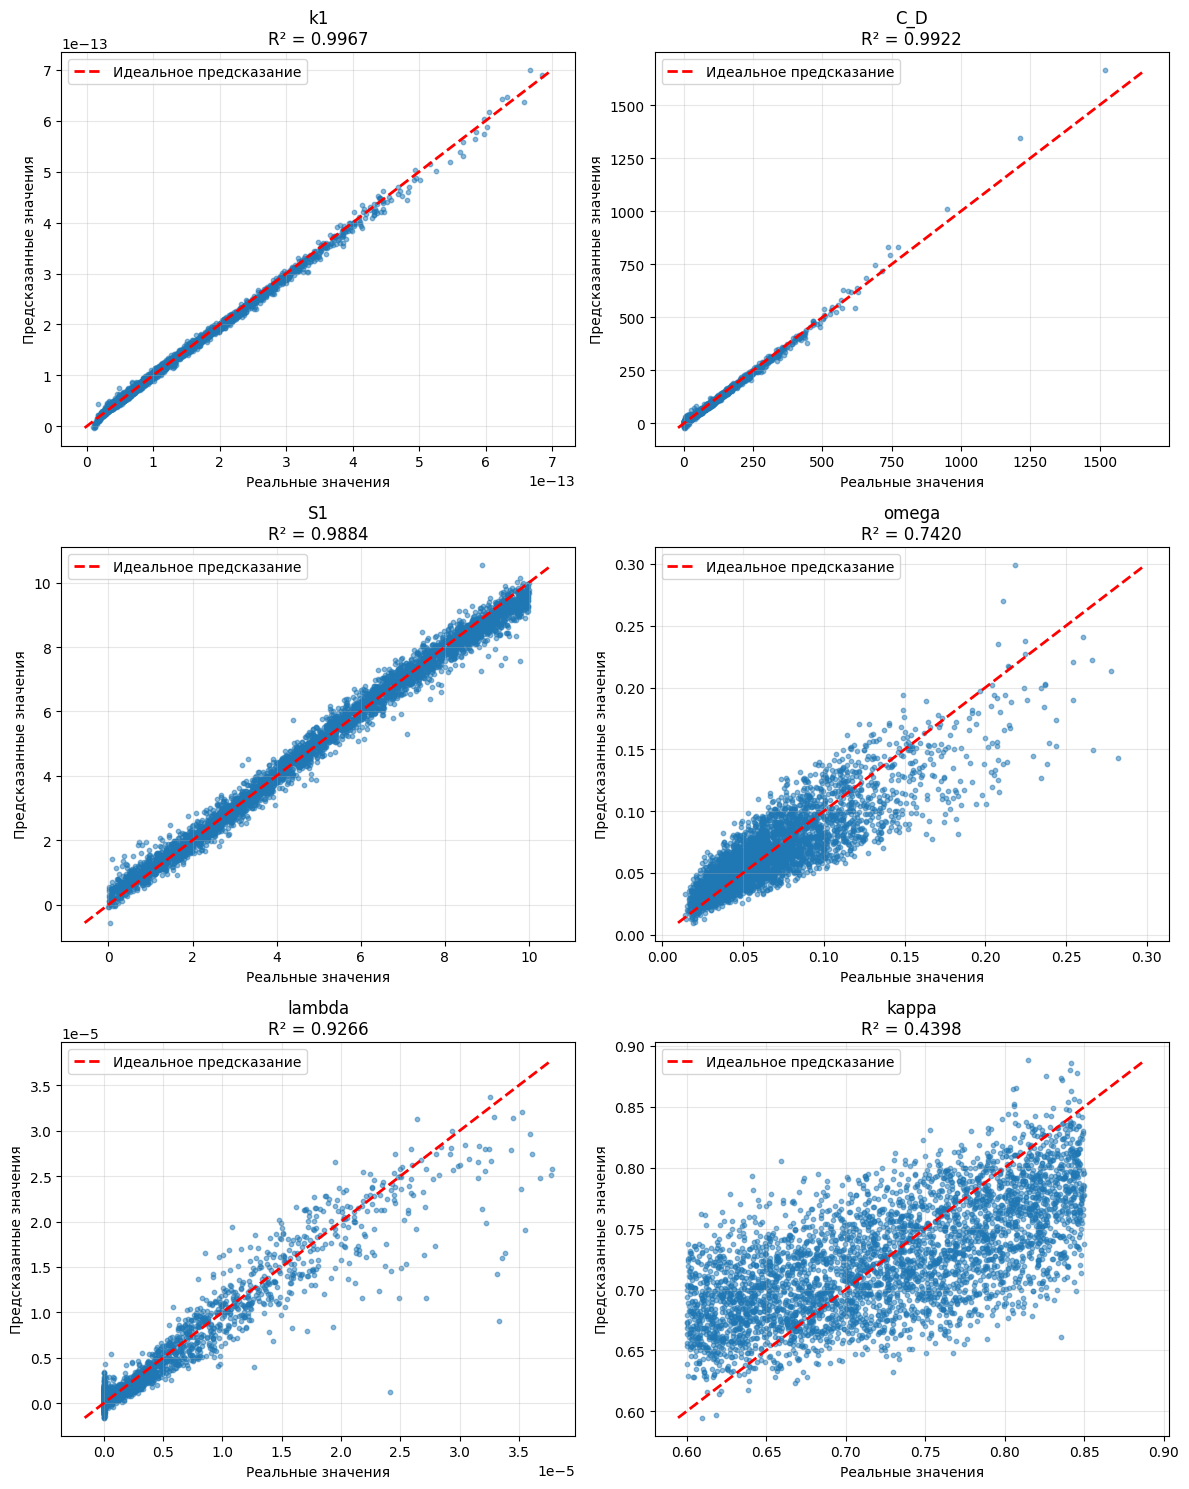

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


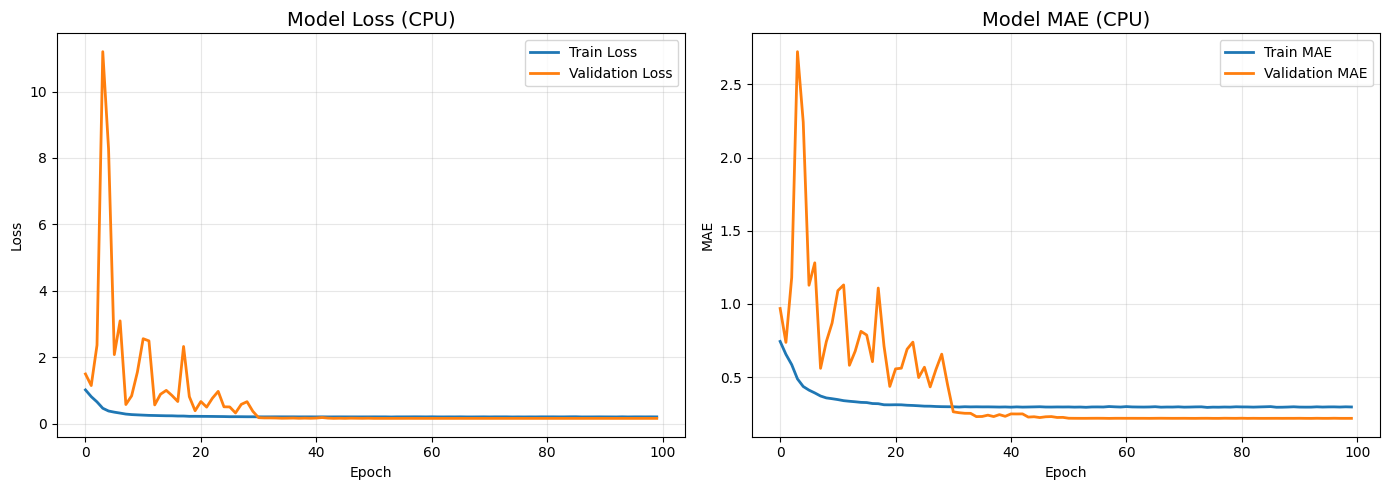

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_permeability_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_permeability_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_permeability_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение двойная проницаемость бесконечный пласт с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/dual_permeability_inf.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/dual_permeability_inf',
    model_type=Model.DUAL_PERMEABILITY_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.0005
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_permeability_inf', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_permeability_inf',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_permeability_inf_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение для модели двойной проницаемости для кругового пласта



In [ ]:
!unzip /content/drive/MyDrive/dual_permeability_fin.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dual_permeability_fin/params/54.csv  
  inflating: dual_permeability_fin/params/179.csv  
  inflating: dual_permeability_fin/params/182.csv  
  inflating: dual_permeability_fin/params/186.csv  
  inflating: dual_permeability_fin/params/263.csv  
  inflating: dual_permeability_fin/params/308.csv  
  inflating: dual_permeability_fin/params/365.csv  
  inflating: dual_permeability_fin/params/368.csv  
  inflating: dual_permeability_fin/params/414.csv  
  inflating: dual_permeability_fin/params/426.csv  
  inflating: dual_permeability_fin/params/437.csv  
  inflating: dual_permeability_fin/params/494.csv  
  inflating: dual_permeability_fin/params/501.csv  
  inflating: dual_permeability_fin/params/504.csv  
  inflating: dual_permeability_fin/params/511.csv  
  inflating: dual_permeability_fin/params/532.csv  
  inflating: dual_permeability_fin/params/549.csv  
  inflating: dual_permeability_fin/params/564.csv

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/dual_permeability_fin',
    model_type=Model.DUAL_PERMEABILITY_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 7).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 7).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 7).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  0.008656059032131742 0.774913787719907 0.12628556118851653
Transformed data:  0.012874670910000892 0.6594685583399154 0.12634023094186073
Transformed data:  0.010175922517313876 0.8206501771592046 0.1256966222267761


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=7, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=50,
    initial_lr=0.0005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (17500, 128, 2), y (17500, 7)
Валидационные данные: X (2500, 128, 2), y (2500, 7)
Эпохи: 50

Epoch 1: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 1/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1.2460 - mae: 0.8176 - mse: 1.2460
Epoch 1: val_loss improved from None to 1.27954, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 133ms/step - loss: 0.9885 - mae: 0.7255 - mse: 0.9885 - val_loss: 1.2795 - val_mae: 0.8797 - val_mse: 1.2795 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.7593 - mae: 0.6318 - mse: 0.7593
Epoch 2: val_loss did not improve from 1.27954
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.7134 - mae: 0.6103 - mse: 0.7134 - val_loss: 1.4112 - val_mae: 0.9881 - val_mse: 1.4112 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.6047 - mae: 0.5560 - mse: 0.6047
Epoch 3: val_loss did not improve from 1.27954
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - loss: 0.5835 - mae: 0.5458 - mse: 0.5835 - val_loss: 5.2189 - val_mae: 1.8360 - val_mse: 5.2189 - learning


Epoch 7: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 124ms/step - loss: 0.3687 - mae: 0.4085 - mse: 0.3687 - val_loss: 0.6529 - val_mae: 0.5629 - val_mse: 0.6529 - learning_rate: 2.5000e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 8/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.3565 - mae: 0.3990 - mse: 0.3565
Epoch 8: val_loss did not improve from 0.65285
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.3545 - mae: 0.3983 - mse: 0.3545 - val_loss: 1.8896 - val_mae: 1.1254 - val_mse: 1.8896 - learning_rate: 2.5000e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.0002500000118743628.
Epoch 9/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.3480 - mae: 0.3949 - mse: 0.3480
Epoch 9: val_loss did not improve from 0.65285
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - loss: 0.3455 - mae: 0.3940 - mse: 0.3455 - val_loss: 4.4539 - val_mae: 1.4668 - val_mse: 4.4539 - learning


Epoch 16: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - loss: 0.2546 - mae: 0.3414 - mse: 0.2546 - val_loss: 0.4553 - val_mae: 0.5134 - val_mse: 0.4553 - learning_rate: 1.2500e-04

Epoch 17: LearningRateScheduler setting learning rate to 0.0001250000059371814.
Epoch 17/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2539 - mae: 0.3397 - mse: 0.2539
Epoch 17: val_loss did not improve from 0.45534
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - loss: 0.2522 - mae: 0.3389 - mse: 0.2522 - val_loss: 1.0796 - val_mae: 0.8554 - val_mse: 1.0796 - learning_rate: 1.2500e-04

Epoch 18: LearningRateScheduler setting learning rate to 0.0001250000059371814.
Epoch 18/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2493 - mae: 0.3369 - mse: 0.2493
Epoch 18: val_loss did not improve from 0.45534
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2473 - mae: 0.3364 - mse: 0.2473 - val_loss: 1.7945 - val_mae: 0.9740 - val_mse: 1.7945 - l


Epoch 22: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.2332 - mae: 0.3246 - mse: 0.2332 - val_loss: 0.2793 - val_mae: 0.4047 - val_mse: 0.2793 - learning_rate: 6.2500e-05

Epoch 23: LearningRateScheduler setting learning rate to 6.25000029685907e-05.
Epoch 23/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2313 - mae: 0.3227 - mse: 0.2313
Epoch 23: val_loss did not improve from 0.27934
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2299 - mae: 0.3212 - mse: 0.2299 - val_loss: 0.9664 - val_mae: 0.6426 - val_mse: 0.9664 - learning_rate: 6.2500e-05

Epoch 24: LearningRateScheduler setting learning rate to 6.25000029685907e-05.
Epoch 24/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2301 - mae: 0.3237 - mse: 0.2301
Epoch 24: val_loss did not improve from 0.27934
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.2309 - mae: 0.3223 - mse: 0.2309 - val_loss: 1.0183 - val_mae: 0.7481 - val_mse: 1.0183 - lea

...


Epoch 31: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2200 - mae: 0.3138 - mse: 0.2200 - val_loss: 0.1678 - val_mae: 0.2435 - val_mse: 0.1678 - learning_rate: 3.1250e-06

Epoch 32: LearningRateScheduler setting learning rate to 3.1250001484295353e-06.
Epoch 32/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2191 - mae: 0.3127 - mse: 0.2191
Epoch 32: val_loss did not improve from 0.16781
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.2193 - mae: 0.3139 - mse: 0.2193 - val_loss: 0.1796 - val_mae: 0.2623 - val_mse: 0.1796 - learning_rate: 3.1250e-06

Epoch 33: LearningRateScheduler setting learning rate to 3.1250001484295353e-06.
Epoch 33/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2202 - mae: 0.3146 - mse: 0.2202
Epoch 33: val_loss did not improve from 0.16781
274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step - loss: 0.2181 - mae: 0.3128 - mse: 0.2181 - val_loss: 0.1703 - val_mae: 0.2427 - val_mse: 0.1703 -


Epoch 37: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.2193 - mae: 0.3130 - mse: 0.2193 - val_loss: 0.1641 - val_mae: 0.2369 - val_mse: 0.1641 - learning_rate: 1.5625e-06

Epoch 38: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 38/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.2207 - mae: 0.3152 - mse: 0.2207
Epoch 38: val_loss did not improve from 0.16405
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - loss: 0.2224 - mae: 0.3154 - mse: 0.2224 - val_loss: 0.1803 - val_mae: 0.2544 - val_mse: 0.1803 - learning_rate: 1.5625e-06

Epoch 39: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 39/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.2196 - mae: 0.3128 - mse: 0.2196
Epoch 39: val_loss did not improve from 0.16405
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2187 - mae: 0.3127 - mse: 0.2187 - val_loss: 0.1652 - val_mae: 0.2385 - val_mse: 0.1652 -


Epoch 40: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 124ms/step - loss: 0.2178 - mae: 0.3119 - mse: 0.2178 - val_loss: 0.1639 - val_mae: 0.2360 - val_mse: 0.1639 - learning_rate: 1.5625e-06

Epoch 41: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 41/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2183 - mae: 0.3134 - mse: 0.2183
Epoch 41: val_loss did not improve from 0.16387
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - loss: 0.2191 - mae: 0.3134 - mse: 0.2191 - val_loss: 0.1655 - val_mae: 0.2343 - val_mse: 0.1655 - learning_rate: 1.5625e-06

Epoch 42: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 42/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.2161 - mae: 0.3111 - mse: 0.2161
Epoch 42: val_loss did not improve from 0.16387
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 130ms/step - loss: 0.2186 - mae: 0.3130 - mse: 0.2186 - val_loss: 0.1665 - val_mae: 0.2427 - val_mse: 0.1665 -


Epoch 44: finished saving model to best_model_regression.h5
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2194 - mae: 0.3135 - mse: 0.2194 - val_loss: 0.1636 - val_mae: 0.2353 - val_mse: 0.1636 - learning_rate: 1.5625e-06

Epoch 45: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 45/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2173 - mae: 0.3123 - mse: 0.2173
Epoch 45: val_loss did not improve from 0.16362
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - loss: 0.2192 - mae: 0.3126 - mse: 0.2192 - val_loss: 0.1748 - val_mae: 0.2461 - val_mse: 0.1748 - learning_rate: 1.5625e-06

Epoch 46: LearningRateScheduler setting learning rate to 1.5625000742147677e-06.
Epoch 46/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.2177 - mae: 0.3141 - mse: 0.2177
Epoch 46: val_loss did not improve from 0.16362
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - loss: 0.2205 - mae: 0.3151 - mse: 0.2205 - val_loss: 0.1681 - val_mae: 0.2412 - val_mse: 0.1681 -

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.1662
  mae: 0.2371
  mse: 0.1662

📊 Регрессионные метрики (в исходном масштабе):

  k1:
    MSE:  1.3904e-28
    MAE:  8.8335e-15
    R²:   0.9829

  C_D:
    MSE:  1.0638e+02
    MAE:  6.9924e+00
    R²:   0.9853

  S1:
    MSE:  1.8699e-01
    MAE:  3.2221e-01
    R²:   0.9775

  omega:
    MSE:  4.1393e-04
    MAE:  1.4742e-02
    R²:   0.7167

  lambda:
    MSE:  5.8775e-12
    MAE:  1.2112e-06
    R²:   0.8306

  kappa:
    MSE:  3.1242e-03
    MAE:  4.5997e-02
    R²:   0.3978

  r_D_e:
    MSE:  3.5567e+05
    MAE:  3.6949e+02
    R²:   0.9520


Количество выходов: 7
Форма y_test_orig: (5000, 7)
Results: -2.23758004346561e-15 8.097988967760428e-13
Results: 1.0175922517313876e-14 8.206501771592046e-13


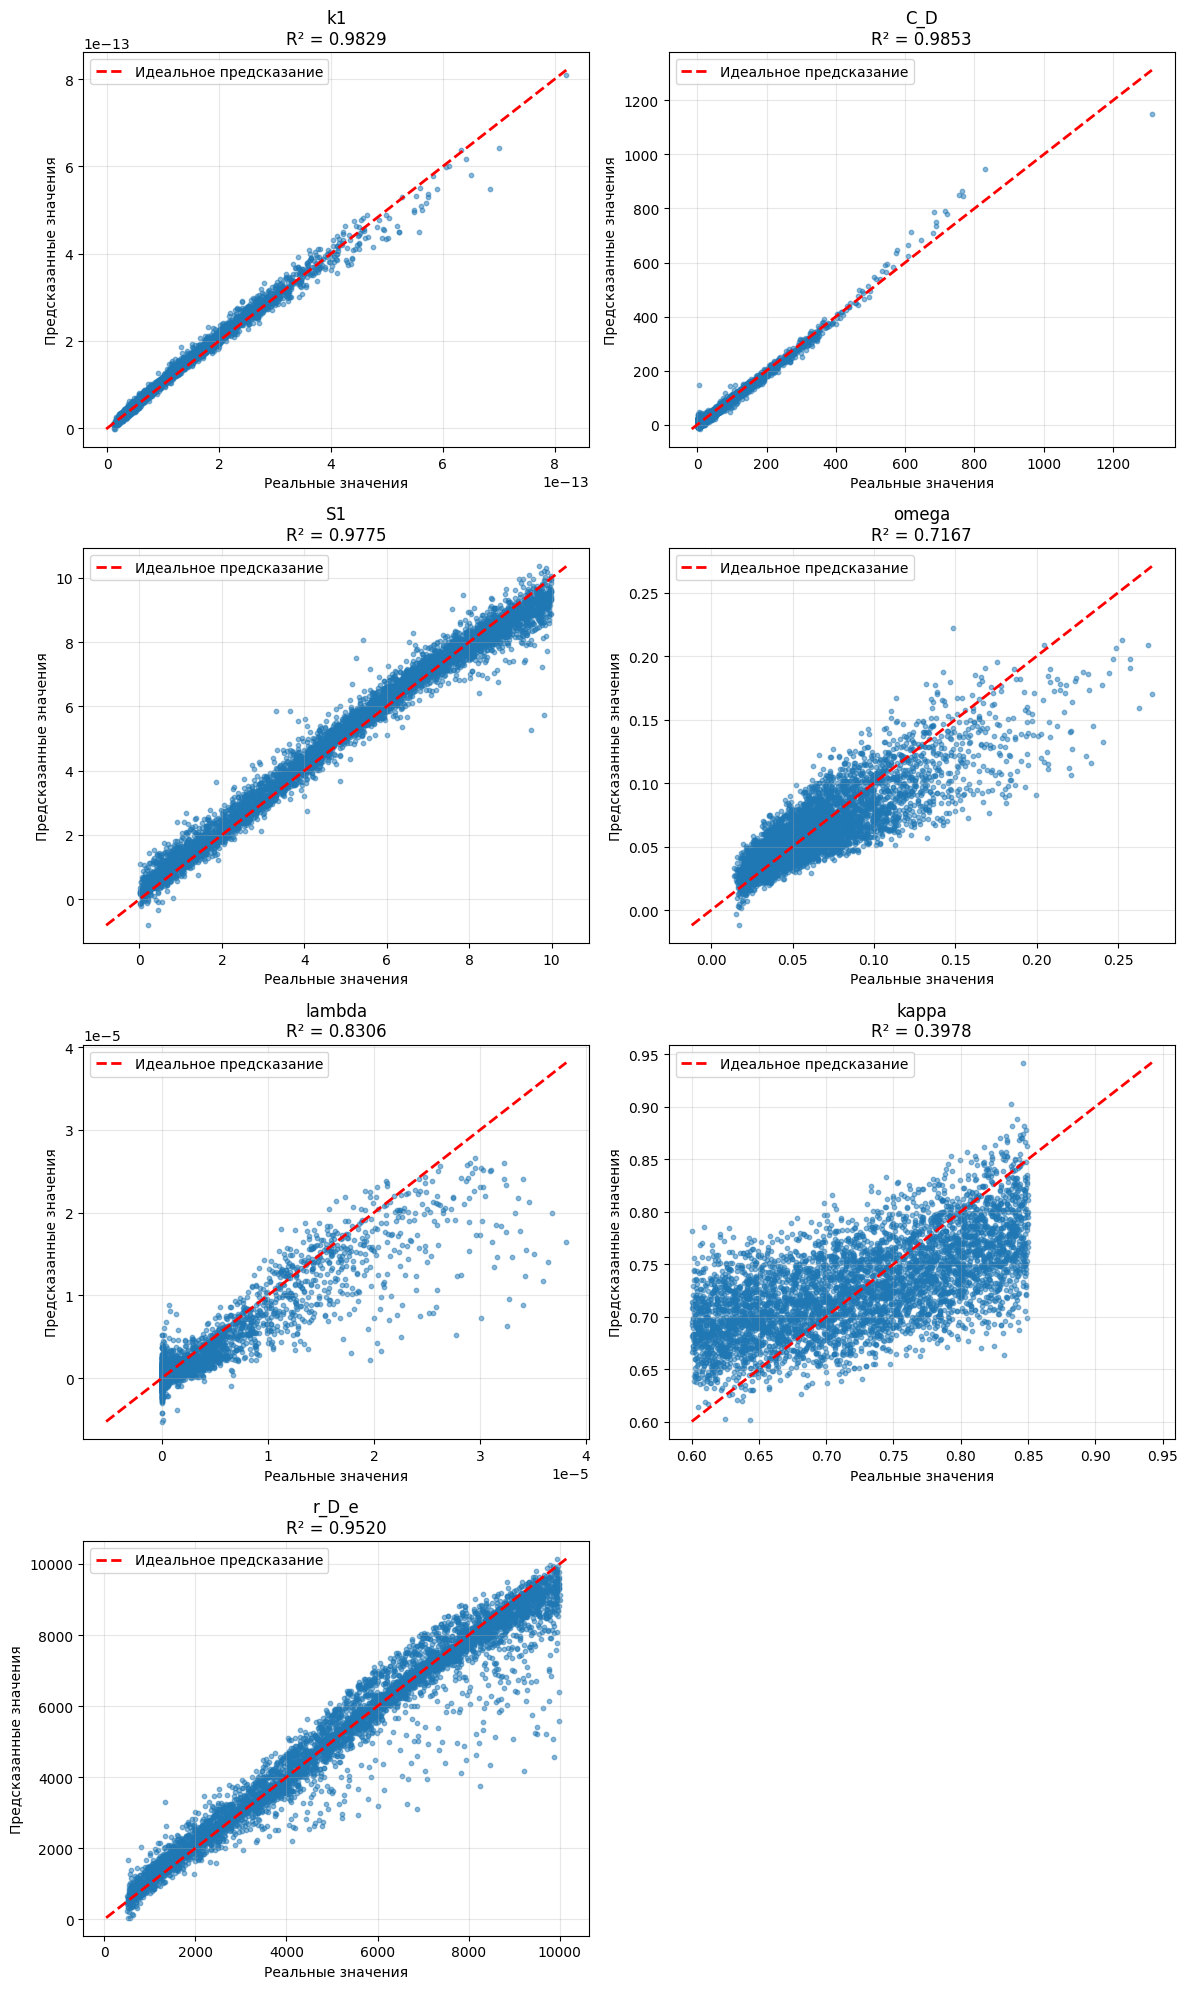

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


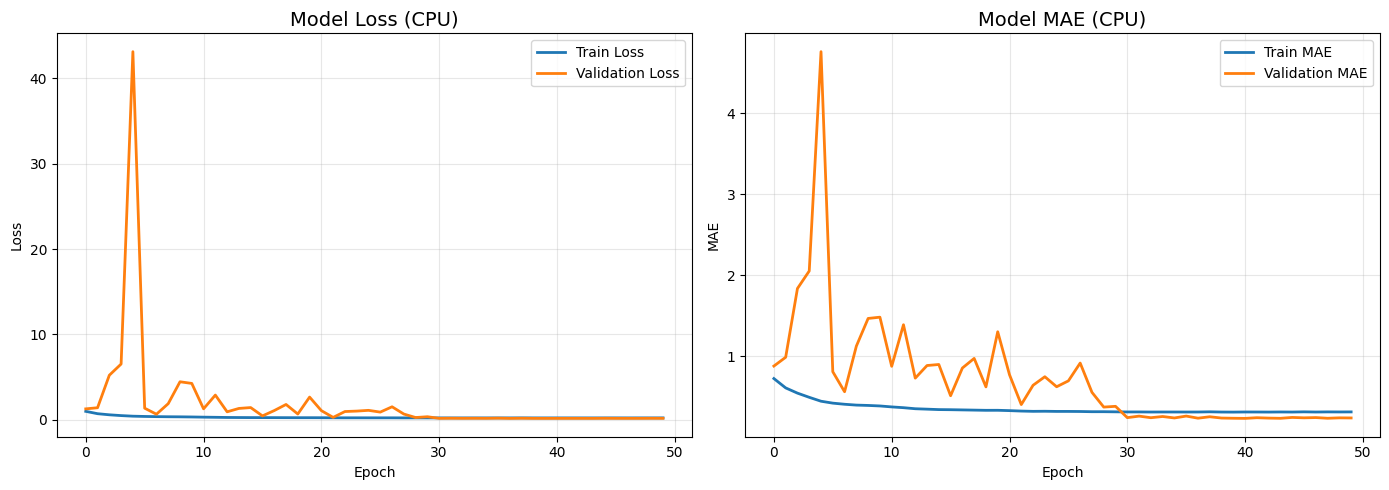

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_permeability_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_permeability_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_permeability_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение двойная проницаемость круговой пласт с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/dual_permeability_fin.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/dual_permeability_fin',
    model_type=Model.DUAL_PERMEABILITY_FIN
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 7).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 7).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 7).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=7, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S1', 'omega', 'lambda', 'kappa', 'r_D_e']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.0005
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_dual_permeability_fin', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_dual_permeability_fin',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_dual_permeability_fin_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение для радиально-комозитной модели

In [ ]:
!unzip /content/drive/MyDrive/radial_composite.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: radial_composite/params/24.csv  
  inflating: radial_composite/params/46.csv  
  inflating: radial_composite/params/48.csv  
  inflating: radial_composite/params/85.csv  
  inflating: radial_composite/params/168.csv  
  inflating: radial_composite/params/183.csv  
  inflating: radial_composite/params/208.csv  
  inflating: radial_composite/params/209.csv  
  inflating: radial_composite/params/215.csv  
  inflating: radial_composite/params/226.csv  
  inflating: radial_composite/params/252.csv  
  inflating: radial_composite/params/268.csv  
  inflating: radial_composite/params/274.csv  
  inflating: radial_composite/params/283.csv  
  inflating: radial_composite/params/290.csv  
  inflating: radial_composite/params/311.csv  
  inflating: radial_composite/params/314.csv  
  inflating: radial_composite/params/319.csv  
  inflating: radial_composite/params/328.csv  
  inflating: radial_composite/params/347.cs

In [ ]:
data_preprocess = PressureDataRegressionPreprocessor1D(
    data_dir='/content/radial_composite',
    model_type=Model.RADIAL_COMPOSITE_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset(task='regression')

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

Transformed data:  25661722.329968218 9748594334.398401 2335134673.979446
Transformed data:  29364181.4650077 9625282880.0788 2317830352.8447313
Transformed data:  37088330.5638719 9568670107.6857 2317330718.8861084


In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S', 'M12', 'omega12', 'r_fD']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=50,
    initial_lr=0.0005
)

НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (REGRESSION)
GPU не обнаружен, используется CPU

НАЧАЛО ОБУЧЕНИЯ НА CPU (REGRESSION)
Устройство: CPU
Размер батча: 64
Тренировочные данные: X (14000, 128, 2), y (14000, 6)
Валидационные данные: X (2000, 128, 2), y (2000, 6)
Эпохи: 50

Epoch 1: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1.3725 - mae: 0.7866 - mse: 1.3725
Epoch 1: val_loss improved from None to 1.31395, saving model to best_model_regression.h5



Epoch 1: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 141ms/step - loss: 1.1381 - mae: 0.7063 - mse: 1.1381 - val_loss: 1.3140 - val_mae: 0.7752 - val_mse: 1.3140 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.9170 - mae: 0.6103 - mse: 0.9170
Epoch 2: val_loss did not improve from 1.31395
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - loss: 0.9136 - mae: 0.6030 - mse: 0.9136 - val_loss: 1.3951 - val_mae: 0.7966 - val_mse: 1.3951 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.8977 - mae: 0.5813 - mse: 0.8977
Epoch 3: val_loss improved from 1.31395 to 1.20870, saving model to best_model_regression.h5



Epoch 3: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - loss: 0.8606 - mae: 0.5733 - mse: 0.8606 - val_loss: 1.2087 - val_mae: 0.7435 - val_mse: 1.2087 - learning_rate: 5.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.8489 - mae: 0.5601 - mse: 0.8489
Epoch 4: val_loss improved from 1.20870 to 1.20637, saving model to best_model_regression.h5



Epoch 4: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - loss: 0.8262 - mae: 0.5543 - mse: 0.8262 - val_loss: 1.2064 - val_mae: 0.7668 - val_mse: 1.2064 - learning_rate: 5.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.8099 - mae: 0.5426 - mse: 0.8099
Epoch 5: val_loss improved from 1.20637 to 0.90729, saving model to best_model_regression.h5



Epoch 5: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 144ms/step - loss: 0.8075 - mae: 0.5390 - mse: 0.8075 - val_loss: 0.9073 - val_mae: 0.5603 - val_mse: 0.9073 - learning_rate: 5.0000e-04

Epoch 6: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.8022 - mae: 0.5278 - mse: 0.8022
Epoch 6: val_loss improved from 0.90729 to 0.71956, saving model to best_model_regression.h5


...


Epoch 31: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 142ms/step - loss: 0.4799 - mae: 0.3476 - mse: 0.4799 - val_loss: 0.4686 - val_mae: 0.3219 - val_mse: 0.4686 - learning_rate: 2.5000e-05

Epoch 32: LearningRateScheduler setting learning rate to 2.5000001187436283e-05.
Epoch 32/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.5551 - mae: 0.3521 - mse: 0.5551
Epoch 32: val_loss did not improve from 0.46858
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 144ms/step - loss: 0.4872 - mae: 0.3463 - mse: 0.4872 - val_loss: 0.4795 - val_mae: 0.3314 - val_mse: 0.4795 - learning_rate: 2.5000e-05

Epoch 33: LearningRateScheduler setting learning rate to 2.5000001187436283e-05.
Epoch 33/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.4533 - mae: 0.3396 - mse: 0.4533
Epoch 33: val_loss improved from 0.46858 to 0.46714, saving model to best_model_regression.h5



Epoch 33: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - loss: 0.4804 - mae: 0.3440 - mse: 0.4804 - val_loss: 0.4671 - val_mae: 0.3112 - val_mse: 0.4671 - learning_rate: 2.5000e-05

Epoch 34: LearningRateScheduler setting learning rate to 2.5000001187436283e-05.
Epoch 34/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.4528 - mae: 0.3434 - mse: 0.4528
Epoch 34: val_loss did not improve from 0.46714
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - loss: 0.4787 - mae: 0.3450 - mse: 0.4787 - val_loss: 0.4884 - val_mae: 0.3344 - val_mse: 0.4884 - learning_rate: 2.5000e-05

Epoch 35: LearningRateScheduler setting learning rate to 2.5000001187436283e-05.
Epoch 35/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.4663 - mae: 0.3428 - mse: 0.4663
Epoch 35: val_loss did not improve from 0.46714
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 141ms/step - loss: 0.4830 - mae: 0.3456 - mse: 0.4830 - val_loss: 0.5341 - val_mae: 0.3699 - val_mse: 0.5341 -


Epoch 43: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - loss: 0.4802 - mae: 0.3439 - mse: 0.4802 - val_loss: 0.4647 - val_mae: 0.3065 - val_mse: 0.4647 - learning_rate: 1.2500e-05

Epoch 44: LearningRateScheduler setting learning rate to 1.2500000593718141e-05.
Epoch 44/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.5126 - mae: 0.3445 - mse: 0.5126
Epoch 44: val_loss did not improve from 0.46473
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 141ms/step - loss: 0.4735 - mae: 0.3419 - mse: 0.4735 - val_loss: 0.4653 - val_mae: 0.3070 - val_mse: 0.4653 - learning_rate: 1.2500e-05

Epoch 45: LearningRateScheduler setting learning rate to 1.2500000593718141e-05.
Epoch 45/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.4872 - mae: 0.3449 - mse: 0.4872
Epoch 45: val_loss did not improve from 0.46473
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 142ms/step - loss: 0.4773 - mae: 0.3430 - mse: 0.4773 - val_loss: 0.4766 - val_mae: 0.3117 - val_mse: 0.4766 -


Epoch 47: finished saving model to best_model_regression.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 142ms/step - loss: 0.4725 - mae: 0.3421 - mse: 0.4725 - val_loss: 0.4640 - val_mae: 0.3075 - val_mse: 0.4640 - learning_rate: 1.2500e-05

Epoch 48: LearningRateScheduler setting learning rate to 1.2500000593718141e-05.
Epoch 48/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.4754 - mae: 0.3398 - mse: 0.4754
Epoch 48: val_loss did not improve from 0.46399
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step - loss: 0.4701 - mae: 0.3409 - mse: 0.4701 - val_loss: 0.4709 - val_mae: 0.3112 - val_mse: 0.4709 - learning_rate: 1.2500e-05

Epoch 49: LearningRateScheduler setting learning rate to 1.2500000593718141e-05.
Epoch 49/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.4627 - mae: 0.3414 - mse: 0.4627
Epoch 49: val_loss did not improve from 0.46399
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 144ms/step - loss: 0.4716 - mae: 0.3428 - mse: 0.4716 - val_loss: 0.4675 - val_mae: 0.3097 - val_mse: 0.4675 -

✅ Информация об обучении сохранена в training_metrics_regression.json


In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)


ОЦЕНКА МОДЕЛИ (REGRESSION)

📊 Базовые метрики:
  loss: 0.4292
  mae: 0.3055
  mse: 0.4292

📊 Регрессионные метрики (в исходном масштабе):

  k1:
    MSE:  1.6282e-07
    MAE:  2.5570e-04
    R²:   0.9447

  S1:
    MSE:  7.4311e+00
    MAE:  2.3251e+00
    R²:   0.0986

  C_D:
    MSE:  7.7237e+04
    MAE:  1.2194e+02
    R²:   0.7785

  M12:
    MSE:  1.3363e-01
    MAE:  2.6201e-01
    R²:   0.8975

  omega12:
    MSE:  1.2307e+01
    MAE:  1.3870e+00
    R²:   0.5861

  r_fD:
    MSE:  1.5181e+01
    MAE:  9.1305e-01
    R²:   0.0012


Количество выходов: 6
Форма y_test_orig: (4000, 6)
Results: -0.0019847271032631397 0.008630978874862194
Results: 3.708833056387186e-05 0.0095686701076857


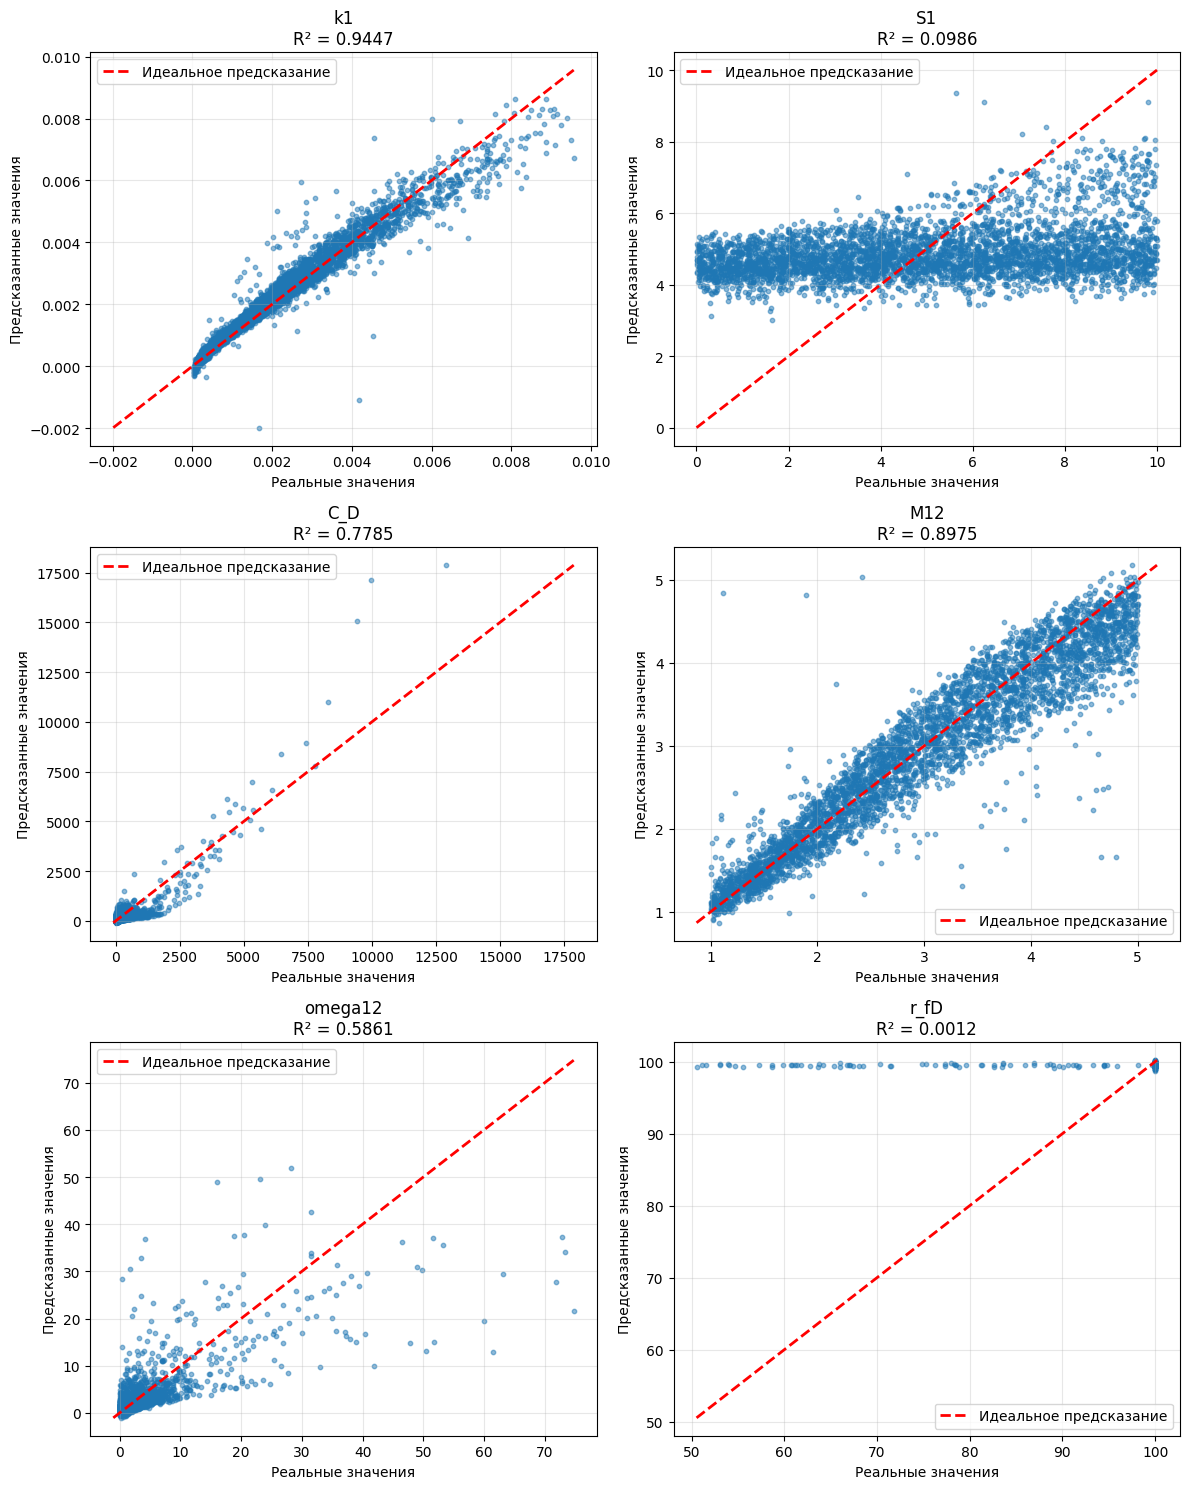

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

📊 График сохранен в training_history.png


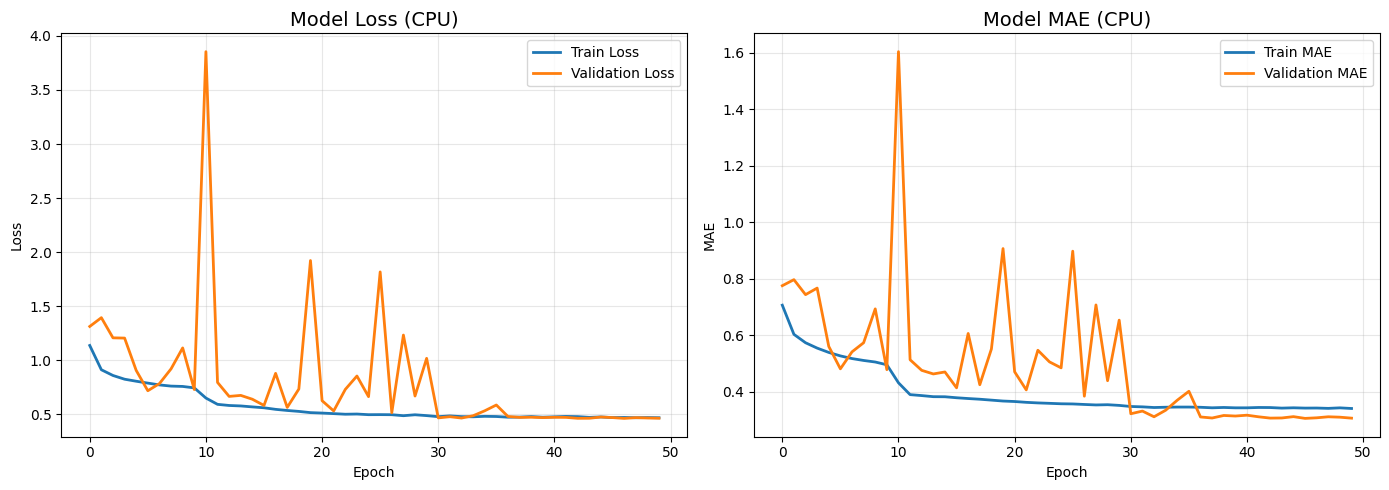

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_radial_composite', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_radial_composite',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_radial_composite_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Обучение радиально-композитная модель с разными train, val, test

In [ ]:
!unzip /content/drive/MyDrive/datasets/radial_composite_inf.zip

In [ ]:
data_preprocess = PressureDataRegressionCustomPreprocessor1D(
    data_dir='/content/radial_composite_inf',
    model_type=Model.RADIAL_COMPOSITE_INF
)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()

In [ ]:
y_train_reg_reshaped = y_train.reshape(-1, 6).astype(np.float64)
y_val_reg_reshaped = y_val.reshape(-1, 6).astype(np.float64)
y_test_reg_reshaped = y_test.reshape(-1, 6).astype(np.float64)

In [ ]:
y_train_k = y_train_reg_reshaped[:, 0:1]
y_val_k = y_val_reg_reshaped[:, 0:1]
y_test_k = y_test_reg_reshaped[:, 0:1]

y_train_k_norm = y_train_k
y_val_k_norm = y_val_k
y_test_k_norm = y_test_k

k_train_reshaped = y_train_k_norm.reshape(-1, 1, 1)
k_val_reshaped = y_val_k_norm.reshape(-1, 1, 1)
k_test_reshaped = y_test_k_norm.reshape(-1, 1, 1)

In [ ]:
k_scaler = KValueScaler(log_cols=[3, 4])
k_scaler.fit(y_train_reg_reshaped)

y_train_k = k_scaler.transform(y_train_reg_reshaped)
y_val_k = k_scaler.transform(y_val_reg_reshaped)
y_test_k = k_scaler.transform(y_test_reg_reshaped)

In [ ]:
X_train_k = X_train / k_train_reshaped
X_val_k = X_val / k_val_reshaped
X_test_k = X_test / k_test_reshaped

In [ ]:
eps = 1e-10
X_train_k = np.log10(np.abs(X_train_k) + eps)
X_val_k = np.log10(np.abs(X_val_k) + eps)
X_test_k = np.log10(np.abs(X_test_k) + eps)
# Глобальная стандартизация: приводим к ~[-3, 3] с сохранением межсэмпловой вариации k
X_mean = X_train_k.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_k.std(axis=(0, 1), keepdims=True)
X_train_k = (X_train_k - X_mean) / X_std
X_val_k   = (X_val_k   - X_mean) / X_std
X_test_k  = (X_test_k  - X_mean) / X_std

In [ ]:
model = WellTestCNN_LSTM(num_classes=6, input_shape=(128, 2), task_type='regression')

trainer_k = WellTestTrainer(
    model=model.model,
    task_type='regression',
    output_names=['k1', 'C_D', 'S', 'M12', 'omega12', 'r_fD']
)

trainer_k.set_y_scaler(k_scaler)

history_k = trainer_k.train(
    X_train_k, y_train_k,
    X_val_k, y_val_k,
    batch_size=64,
    epochs=100,
    initial_lr=0.005
)

In [ ]:
metrics_k = trainer_k.evaluate(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_predictions_vs_actual(X_test_k, y_test_k)

In [ ]:
trainer_k.plot_training_history(save_path='training_history.png')

In [ ]:
trainer_k.save_model('cnn_lstm_model_regression_radial_composite', format='all')

In [ ]:
import json as _json, numpy as _np, os as _os
_n_cols = len(trainer_k.output_names)
_cfg = {
    'model_name': 'cnn_lstm_model_regression_radial_composite',
    'output_names': trainer_k.output_names,
    'log_cols': k_scaler.log_cols,
    'k_multiplier': k_scaler.k_multiplier,
    'k_scaler_mean': k_scaler.k_scaler.mean_.tolist(),
    'k_scaler_scale': k_scaler.k_scaler.scale_.tolist(),
    'log_scaler_mean': {str(c): k_scaler.log_scalers[c].mean_.tolist() for c in k_scaler.log_cols},
    'log_scaler_scale': {str(c): k_scaler.log_scalers[c].scale_.tolist() for c in k_scaler.log_cols},
    'other_cols': k_scaler._other_cols(_n_cols),
    'other_scaler_mean': k_scaler.other_scaler.mean_.tolist() if k_scaler.other_scaler else [],
    'other_scaler_scale': k_scaler.other_scaler.scale_.tolist() if k_scaler.other_scaler else [],
    'X_mean': X_mean.tolist(),
    'X_std': X_std.tolist(),
}
_path = 'cnn_lstm_model_regression_radial_composite_scaler_config.json'
with open(_path, 'w') as _f:
    _json.dump(_cfg, _f, indent=2)
print(f'Scaler config saved to {_path}')

# Классификация для 0.01

In [ ]:
!unzip /content/drive/MyDrive/dataset.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dataset/dataset01/params/45.csv  
  inflating: dataset/dataset01/params/54.csv  
  inflating: dataset/dataset01/params/58.csv  
  inflating: dataset/dataset01/params/121.csv  
  inflating: dataset/dataset01/params/186.csv  
  inflating: dataset/dataset01/params/263.csv  
  inflating: dataset/dataset01/params/294.csv  
  inflating: dataset/dataset01/params/307.csv  
  inflating: dataset/dataset01/params/308.csv  
  inflating: dataset/dataset01/params/341.csv  
  inflating: dataset/dataset01/params/365.csv  
  inflating: dataset/dataset01/params/391.csv  
  inflating: dataset/dataset01/params/424.csv  
  inflating: dataset/dataset01/params/429.csv  
  inflating: dataset/dataset01/params/437.csv  
  inflating: dataset/dataset01/params/459.csv  
  inflating: dataset/dataset01/params/494.csv  
  inflating: dataset/dataset01/params/511.csv  
  inflating: dataset/dataset01/params/549.csv  
  inflating: dataset/da

In [ ]:
# Подготовка данных
data_preprocess = PressureDataClassificationPreprocessor1D(data_dir='/content/dataset/dataset02', debug=True)
X_train, X_val, X_test, y_train, y_val, y_test = data_preprocess.get_dataset()
class_names = data_preprocess.get_class_names()
num_classes = len(class_names)

X_train = data_preprocess.normalize(X_train)
X_val = data_preprocess.normalize(X_val)
X_test = data_preprocess.normalize(X_test)

Найденные метки: ['dual_permeability_fin', 'dual_porosity_fin', 'dual_permeability_inf', 'radial_composite_inf', 'dual_porosity_inf', 'homogeneous_fin', 'homogeneous_inf']
One-hot кодирование (размерность): (28000, 7)
shape X = (28000, 128, 2)
Train: (19600, 128, 2) (70.0%)
Val: (2800, 128, 2) (10.0%)
Test: (5600, 128, 2) (20.0%)


НАСТРОЙКА УСТРОЙСТВА ДЛЯ ОБУЧЕНИЯ (CLASSIFICATION)
Обнаружено GPU: 1
✅ Mixed precision включен

НАЧАЛО ОБУЧЕНИЯ НА GPU (CLASSIFICATION)
Устройство: GPU
Размер батча: 64
Тренировочные данные: X (19600, 128, 2), y (19600, 7)
Валидационные данные: X (2800, 128, 2), y (2800, 7)
Эпохи: 80

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/80
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4607 - loss: 1.4425
Epoch 1: val_accuracy improved from None to 0.14286, saving model to best_model_classification.h5



Epoch 1: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5698 - loss: 1.0884 - val_accuracy: 0.1429 - val_loss: 2.2815 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6882 - loss: 0.7014
Epoch 2: val_accuracy improved from 0.14286 to 0.53500, saving model to best_model_classification.h5



Epoch 2: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6993 - loss: 0.6636 - val_accuracy: 0.5350 - val_loss: 1.1677 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7463 - loss: 0.5561
Epoch 3: val_accuracy improved from 0.53500 to 0.76571, saving model to best_model_classification.h5



Epoch 3: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7537 - loss: 0.5357 - val_accuracy: 0.7657 - val_loss: 0.4818 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7730 - loss: 0.4777
Epoch 4: val_accuracy improved from 0.76571 to 0.78071, saving model to best_model_classification.h5



Epoch 4: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7805 - loss: 0.4687 - val_accuracy: 0.7807 - val_loss: 0.4831 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7976 - loss: 0.4258
Epoch 5: val_accuracy improved from 0.78071 to 0.80143, saving model to best_model_classification.h5


...


Epoch 54: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9580 - loss: 0.1210 - val_accuracy: 0.9646 - val_loss: 0.0993 - learning_rate: 6.2500e-07

Epoch 55: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 55/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9581 - loss: 0.1191
Epoch 55: val_accuracy improved from 0.96464 to 0.96500, saving model to best_model_classification.h5



Epoch 55: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9572 - loss: 0.1214 - val_accuracy: 0.9650 - val_loss: 0.0991 - learning_rate: 6.2500e-07

Epoch 56: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 56/80
304/307 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9618 - loss: 0.1137
Epoch 56: val_accuracy did not improve from 0.96500
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9588 - loss: 0.1204 - val_accuracy: 0.9650 - val_loss: 0.0985 - learning_rate: 6.2500e-07

Epoch 57: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 57/80
306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9588 - loss: 0.1191
Epoch 57: val_accuracy improved from 0.96500 to 0.96571, saving model to best_model_classification.h5



Epoch 57: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9576 - loss: 0.1215 - val_accuracy: 0.9657 - val_loss: 0.0994 - learning_rate: 6.2500e-07

Epoch 58: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 58/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9589 - loss: 0.1228
Epoch 58: val_accuracy did not improve from 0.96571
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9595 - loss: 0.1203 - val_accuracy: 0.9654 - val_loss: 0.0977 - learning_rate: 6.2500e-07

Epoch 59: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 59/80
306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9567 - loss: 0.1235
Epoch 59: val_accuracy did not improve from 0.96571
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9583 - loss: 0.1202 - val_accuracy: 0.9636 - val_loss: 0.0987 - learning_rate: 6.2500e-07

Epoch 60: LearningRateScheduler setting learning rate to


Epoch 60: finished saving model to best_model_classification.h5
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9596 - loss: 0.1203 - val_accuracy: 0.9661 - val_loss: 0.0991 - learning_rate: 6.2500e-07

Epoch 61: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 61/80
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9579 - loss: 0.1224
Epoch 61: val_accuracy did not improve from 0.96607
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9574 - loss: 0.1214 - val_accuracy: 0.9643 - val_loss: 0.0996 - learning_rate: 6.2500e-07

Epoch 62: LearningRateScheduler setting learning rate to 6.24999984211172e-07.
Epoch 62/80
305/307 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9570 - loss: 0.1238
Epoch 62: val_accuracy did not improve from 0.96607
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9569 - loss: 0.1238 - val_accuracy: 0.9643 - val_loss: 0.1008 - learning_rate: 6.2500e-07

Epoch 63: LearningRateScheduler setting learning rate to

✅ Информация об обучении сохранена в training_metrics_classification.json

ОЦЕНКА МОДЕЛИ (CLASSIFICATION)

📊 Базовые метрики:
  accuracy: 0.9657
  loss: 0.1031

📈 ROC AUC Score (macro): 0.9976

📊 Classification Report:
                       precision    recall  f1-score   support

dual_permeability_fin     0.9689    0.9738    0.9713       800
    dual_porosity_fin     0.9987    0.9975    0.9981       800
dual_permeability_inf     0.9538    0.8512    0.8996       800
 radial_composite_inf     0.9923    0.9675    0.9797       800
    dual_porosity_inf     0.8845    0.9762    0.9281       800
      homogeneous_fin     0.9695    0.9938    0.9815       800
      homogeneous_inf     1.0000    1.0000    1.0000       800

             accuracy                         0.9657      5600
            macro avg     0.9668    0.9657    0.9655      5600
         weighted avg     0.9668    0.9657    0.9655      5600

Predicted class: 2, Confidence: 99.51%
True class: 2
📊 График сохранен в training_res

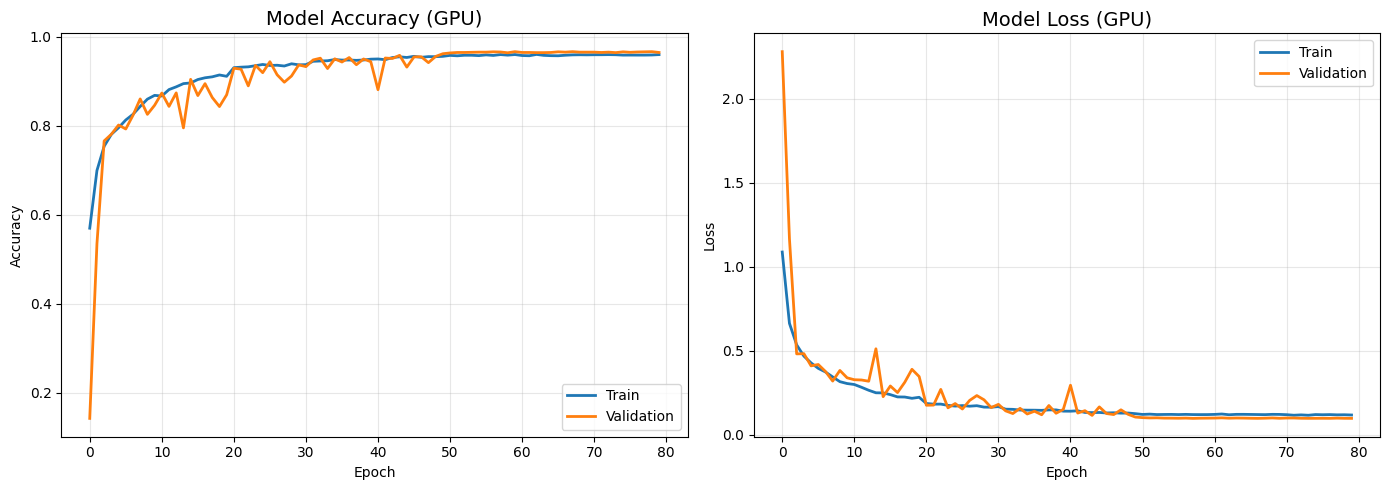

✅ Веса модели сохранены: cnn_lstm_cls_multiclass.weights.h5
✅ Модель сохранена в Keras format: cnn_lstm_cls_multiclass.keras
❌ Не удалось сохранить в SavedModel: this __dict__ descriptor does not support '_DictWrapper' objects
✅ Конфигурация сохранена: cnn_lstm_cls_multiclass_config.json


In [ ]:
model = WellTestCNN_LSTM(
    num_classes=num_classes,
    input_shape=(128, 2)
)

trainer = WellTestTrainer(
    model=model.model,
    task_type='classification',
    class_names=class_names
)

history = trainer.train(
    X_train, y_train,
    X_val, y_val,
    batch_size=64,
    epochs=80,
    initial_lr=0.0001
)

metrics = trainer.evaluate(X_test, y_test)

sample = X_test[0]
pred_class, probs, confidence = trainer.predict_single(X_test[0])
print(f"Predicted class: {pred_class}, Confidence: {confidence:.2%}")
print(f"True class: {np.argmax(y_test[0])}")

trainer.plot_training_history(save_path='training_results.png')

trainer.save_model('cnn_lstm_cls_multiclass', format='all')


CONFUSION MATRIX
📊 Confusion matrix сохранена в confusion_matrix.png


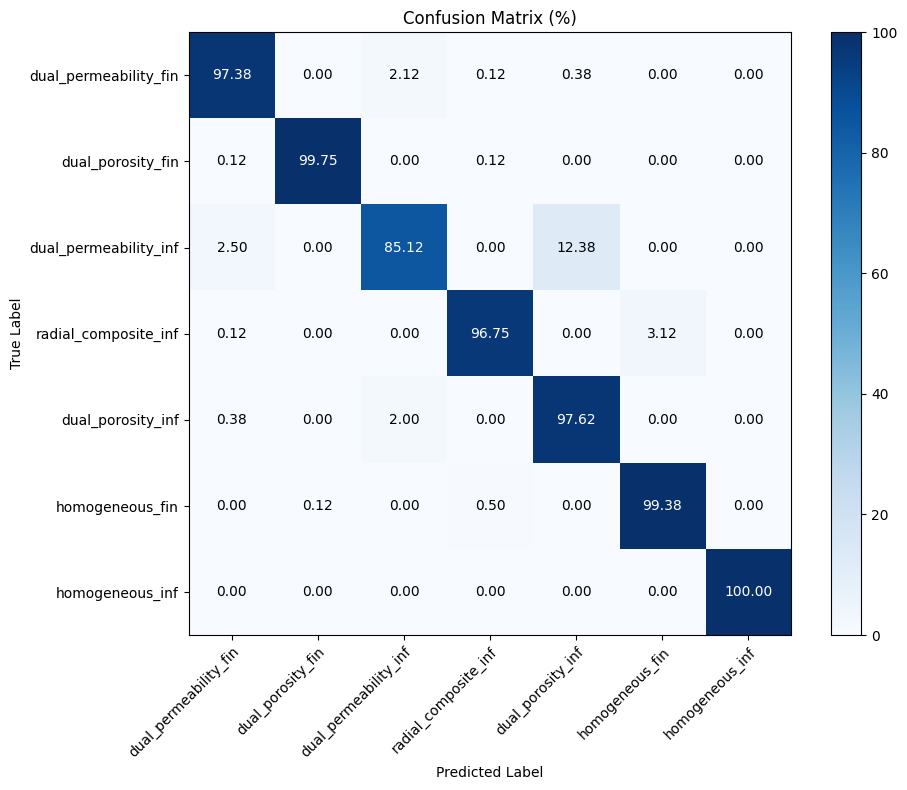

In [ ]:
cm = trainer.plot_confusion_matrix(X_test, y_test,
                                normalize=True,
                                save_path='confusion_matrix.png')